In [43]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
from scipy.linalg import solve

### Data Loading

Load precomputed trophic coherence and effective connectivity (Ceff) matrices from `.mat` files. Separate files exist for LOW and HIGH anhedonia groups. The comparison file contains both groups' trophic coherence scalars and Ceff matrices; per-group files additionally contain model fit metrics (fittFC, fittCVtau) and per-region hierarchical levels (NSUB × 232).

In [44]:
# %% Load results from .mat files
# The comparison file has trophic coherence + Ceff
data_comp = sio.loadmat('outputs/NEW_4_factor_clustering_ipnybV4/results_Ceff_anhedonia_comparison.mat')
trophiccoherence_LOW = data_comp['trophiccoherence_LOW'].flatten()
trophiccoherence_HIGH = data_comp['trophiccoherence_HIGH'].flatten()

# Per-group files have fittFC, fittCVtau, hierarchicallevels
data_low = sio.loadmat('outputs/NEW_4_factor_clustering_ipnybV4/low_anhedonia/results_Ceff_low_anhedonia.mat')
data_high = sio.loadmat('outputs/NEW_4_factor_clustering_ipnybV4/high_anhedonia/results_Ceff_high_anhedonia.mat')


In [45]:
fittFC_LOW = data_low['fittFC_LOW'].flatten()
fittFC_HIGH = data_high['fittFC_HIGH'].flatten()
fittCVtau_LOW = data_low['fittCVtau_LOW'].flatten()
fittCVtau_HIGH = data_high['fittCVtau_HIGH'].flatten()
hierarchicallevels_LOW = data_low['hierarchicallevels_LOW']   # (NSUB x 232)
hierarchicallevels_HIGH = data_high['hierarchicallevels_HIGH'] # (NSUB x 232)

NSUB_LOW = len(trophiccoherence_LOW)
NSUB_HIGH = len(trophiccoherence_HIGH)

---
## Part 2: Confound Analysis and Covariate-Corrected OLS

**Motivation:** The confound check below confirmed that the LOW and HIGH anhedonia groups are significantly unbalanced on clinical status (patient vs healthy control), which is a potential alternative explanation for the Part 1 findings.

**Strategy:** Each metric is re-tested using OLS regression with three covariates:
- `Age` (continuous, years)
- `Sex` (binary F/M; the 4 "Other" subjects are set to NaN and dropped via listwise deletion)
- `is_patient` (binary: 1 = any psychiatric diagnosis, 0 = healthy control / code 999)

The key result in each OLS is the coefficient and p-value for `anhedonia_group[T.HIGH]`, representing the anhedonia effect after partialling out the covariates.

### Step 1: Confound Check

Before fitting OLS models, verify whether the LOW and HIGH groups differ significantly on the three covariates:
- **Age**: Wilcoxon rank-sum (non-parametric, continuous)
- **Sex**: Chi-square (or Fisher's exact if any expected cell < 5)
- **Patient vs HC**: Chi-square

Subject IDs are loaded from the anhedonia grouping `.mat` files and merged with the demographics Excel file (`demos_payman.xls`).

In [46]:
# %% Confound Check: Are LOW vs HIGH anhedonia groups balanced on age, sex, and diagnosis?
import scipy.io as sio
import pandas as pd
import numpy as np
from scipy.stats import ranksums, chi2_contingency, fisher_exact

# --- 1. Load subject IDs from anhedonia grouping .mat files ---
mat_low  = sio.loadmat('/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/anhedonia/NEW_4_factor_clustering_ipnybV4/low_anhedonia.mat')
mat_high = sio.loadmat('/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/anhedonia/NEW_4_factor_clustering_ipnybV4/high_anhedonia.mat')

ids_low  = [mat_low['low_anhedonia'][i, 1].flat[0]  for i in range(mat_low['low_anhedonia'].shape[0])]
ids_high = [mat_high['high_anhedonia'][i, 1].flat[0] for i in range(mat_high['high_anhedonia'].shape[0])]

print(f'N LOW  = {len(ids_low)}')
print(f'N HIGH = {len(ids_high)}')

# --- 2. Load demographics ---
demos = pd.read_excel(
    '/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/my_analysis/trophic_coherence_analysis/data/demos_payman.xls',
    header=1
)
demos['Age_clean'] = demos['Age'].replace(999, np.nan)

# Binary patient/HC column (999 = HC)
demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)

# --- 3. Tag each subject with their anhedonia group ---
demos['anhedonia_group'] = None  # object dtype — can hold strings
demos.loc[demos['subjectkey'].isin(ids_low),  'anhedonia_group'] = 'LOW'
demos.loc[demos['subjectkey'].isin(ids_high), 'anhedonia_group'] = 'HIGH'


df = demos[demos['anhedonia_group'].isin(['LOW', 'HIGH'])].copy()
print(f'\nMatched subjects: {len(df)}  (LOW={len(df[df.anhedonia_group=="LOW"])}, HIGH={len(df[df.anhedonia_group=="HIGH"])})')

low  = df[df['anhedonia_group'] == 'LOW']
high = df[df['anhedonia_group'] == 'HIGH']

# ──────────────────────────────────────────────────
# TEST 1: Age — Wilcoxon rank-sum
# ──────────────────────────────────────────────────
age_low  = low['Age_clean'].dropna()
age_high = high['Age_clean'].dropna()

stat_age, p_age = ranksums(age_low, age_high)

print('\n==============================')
print('CONFOUND CHECK RESULTS')
print('==============================')
print(f'\n[1] AGE  (Wilcoxon rank-sum)')
print(f'    LOW  : mean={age_low.mean():.1f}, median={age_low.median():.1f}, SD={age_low.std():.1f}, n={len(age_low)}')
print(f'    HIGH : mean={age_high.mean():.1f}, median={age_high.median():.1f}, SD={age_high.std():.1f}, n={len(age_high)}')
print(f'    W = {stat_age:.3f}, p = {p_age:.4f}  {"*** SIGNIFICANT — age is a confound" if p_age < 0.05 else "ns"}')

# ──────────────────────────────────────────────────
# TEST 2: Sex — Chi-square (or Fisher if small cells)
# ──────────────────────────────────────────────────
# Restrict to M/F only (4 "O" subjects too few for inference)
df_sex = df[df['sex'].isin(['M', 'F'])]
ct_sex = pd.crosstab(df_sex['anhedonia_group'], df_sex['sex'])
print(f'\n[2] SEX  (Chi-square, M/F only)')
print(ct_sex.to_string())
chi2, p_sex, dof, expected = chi2_contingency(ct_sex)
# Warn if expected cell counts are low
if (expected < 5).any():
    _, p_sex_fisher = fisher_exact(ct_sex)
    print(f'    ⚠ Expected cell < 5 — using Fisher exact instead')
    print(f'    Fisher p = {p_sex_fisher:.4f}  {"*** SIGNIFICANT — sex is a confound" if p_sex_fisher < 0.05 else "ns"}')
else:
    print(f'    χ²({dof}) = {chi2:.3f}, p = {p_sex:.4f}  {"*** SIGNIFICANT — sex is a confound" if p_sex < 0.05 else "ns"}')

# ──────────────────────────────────────────────────
# TEST 3: Patient vs HC — Chi-square
# ──────────────────────────────────────────────────
ct_dx = pd.crosstab(df['anhedonia_group'], df['is_patient'],
                    rownames=['Group'], colnames=['Patient (1) vs HC (0)'])
print(f'\n[3] DIAGNOSIS: Patient vs HC  (Chi-square)')
print(ct_dx.to_string())
chi2_dx, p_dx, dof_dx, exp_dx = chi2_contingency(ct_dx)
print(f'    χ²({dof_dx}) = {chi2_dx:.3f}, p = {p_dx:.4f}  {"*** SIGNIFICANT — diagnosis is a confound" if p_dx < 0.05 else "ns"}')

# ──────────────────────────────────────────────────
# SUMMARY
# ──────────────────────────────────────────────────
print('\n==============================')
print('SUMMARY')
print('==============================')
for label, p in [('Age', p_age), ('Sex', p_sex), ('Patient/HC', p_dx)]:
    flag = '*** CONFOUND' if p < 0.05 else 'balanced'
    print(f'  {label:<12} p = {p:.4f}   [{flag}]')

    # ──────────────────────────────────────────────────
# TEST 4: Full diagnosis distribution — Chi-square
# ──────────────────────────────────────────────────
# Recode 999 → 'HC' for readability
df['Dx_label'] = df['Primary_Dx_Payman'].replace(999, 'HC').astype(str).str.strip()

ct_full_dx = pd.crosstab(df['anhedonia_group'], df['Dx_label'])
print(f'\n[4] FULL DIAGNOSIS DISTRIBUTION (Chi-square)')
print(ct_full_dx.to_string())

chi2_full, p_full, dof_full, exp_full = chi2_contingency(ct_full_dx)

# Warn if many cells have low expected counts (common with 15+ categories)
n_low_cells = (exp_full < 5).sum()
print(f'\n    Note: {n_low_cells} of {exp_full.size} cells have expected count < 5')
print(f'    χ²({dof_full}) = {chi2_full:.3f}, p = {p_full:.4f}  {"*** SIGNIFICANT" if p_full < 0.05 else "ns"}')

# --- Breakdown: count and % per diagnosis per group ---
print('\n    Diagnosis breakdown (count | % within group):')
for dx in sorted(ct_full_dx.columns):
    n_low_dx  = ct_full_dx.loc['LOW',  dx] if 'LOW'  in ct_full_dx.index else 0
    n_high_dx = ct_full_dx.loc['HIGH', dx] if 'HIGH' in ct_full_dx.index else 0
    pct_low   = 100 * n_low_dx  / len(low)
    pct_high  = 100 * n_high_dx / len(high)
    print(f'      {dx:<18}  LOW: {n_low_dx:3d} ({pct_low:5.1f}%)   HIGH: {n_high_dx:3d} ({pct_high:5.1f}%)')



N LOW  = 139
N HIGH = 71

Matched subjects: 210  (LOW=139, HIGH=71)

CONFOUND CHECK RESULTS

[1] AGE  (Wilcoxon rank-sum)
    LOW  : mean=31.7, median=27.0, SD=11.8, n=138
    HIGH : mean=35.5, median=31.0, SD=15.2, n=71
    W = -0.836, p = 0.4034  ns

[2] SEX  (Chi-square, M/F only)
sex               F   M
anhedonia_group        
HIGH             47  22
LOW              76  62
    χ²(1) = 2.727, p = 0.0986  ns

[3] DIAGNOSIS: Patient vs HC  (Chi-square)
Patient (1) vs HC (0)   0   1
Group                        
HIGH                   14  57
LOW                    68  71
    χ²(1) = 15.634, p = 0.0001  *** SIGNIFICANT — diagnosis is a confound

SUMMARY
  Age          p = 0.4034   [balanced]
  Sex          p = 0.0986   [balanced]
  Patient/HC   p = 0.0001   [*** CONFOUND]

[4] FULL DIAGNOSIS DISTRIBUTION (Chi-square)
Dx_label         ADHD  BP1  BP2  Dysthymia  ED  GAD  HC  MDD  OCD  Other Anxiety  Other Mood Dis  PTSD  SAD  SUD  SZ  SZA
anhedonia_group                                  

/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23835/3837768377.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  demos['Age_clean'] = demos['Age'].replace(999, np.nan)
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23835/3837768377.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23835/3837768377.py:28: PerformanceWarning: DataFrame is highly fragmented.

Why not add all diagnostic categories — the argument
Here are the specific objections and how to answer them:

Objection 1: "You should have controlled for specific diagnoses, not just patient/HC"

"We considered adding diagnosis as a covariate but this was not statistically feasible. With 125 patients and 15 diagnostic categories, adding 14 dummy variables would consume 14 degrees of freedom in a model already testing a single predictor of interest. More critically, 11 of 15 categories contain fewer than 10 subjects per group, making coefficient estimates for those categories statistically unreliable. The chi-square test of the full diagnostic distribution was itself flagged as invalid (22/32 expected cells < 5). The binary patient/HC covariate captures the dominant source of imbalance — the 3-fold difference in HC proportion between groups (48.9% vs 19.7%) — which is the meaningful confound."

Objection 2: "The patients-only result might just reflect the MDD enrichment in HIGH"

This is the most serious objection and you should proactively address it. Within patients:

HIGH has more MDD (22.5% vs 12.2%) and BP2 (7% vs 0%)
But correcting for this would be conceptually problematic: MDD and BP2 are diagnosed partly because patients have anhedonia. Controlling for them partially removes the signal you're studying — this is the classic collider/mediator problem
The better argument: anhedonia is a transdiagnostic symptom that cuts across mood, anxiety, and psychotic disorders. The patients-only comparison is actually testing whether anhedonia severity — independent of which diagnosis a patient carries — predicts trophic organisation.



### OLS: Global Trophic Coherence

Covariate-corrected re-test of the primary outcome (whole-brain trophic coherence). Reference levels: LOW anhedonia, Female, Healthy Control.

In [47]:
# %% OLS: Trophic Coherence ~ Anhedonia Group + Age + Sex + Patient/HC
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# --- Build a combined per-subject dataframe (metric + demographics) ---
df_metric = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'trophic_coherence': trophiccoherence_LOW,  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'trophic_coherence': trophiccoherence_HIGH, 'anhedonia_group': 'HIGH'}),
], ignore_index=True)

# Merge with demographics (df already has Age_clean, sex, is_patient from confound check cell)
df_ols = df_metric.merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

# Recode sex "O" -> NaN (only 4 subjects; dropped via listwise deletion in OLS)
df_ols['sex'] = df_ols['sex'].replace('O', np.nan)

# Set reference levels: LOW anhedonia, Female, HC (is_patient=0)
df_ols['anhedonia_group'] = pd.Categorical(df_ols['anhedonia_group'], categories=['LOW', 'HIGH'])
df_ols['sex']             = pd.Categorical(df_ols['sex'],             categories=['F', 'M'])

# --- Fit OLS ---
model  = smf.ols('trophic_coherence ~ anhedonia_group + Age_clean + sex + is_patient', data=df_ols)
result = model.fit()

print(result.summary())

# --- Key result: anhedonia group effect after covariate correction ---
coef  = result.params['anhedonia_group[T.HIGH]']
pval  = result.pvalues['anhedonia_group[T.HIGH]']
ci_lo, ci_hi = result.conf_int().loc['anhedonia_group[T.HIGH]']

print('\n==============================')
print('TROPHIC COHERENCE — OLS Result')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef:.5f}')
print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
    print(f'    {term:<22}  β={result.params[term]:.5f},  p={result.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result.rsquared:.3f},  adj-R²={result.rsquared_adj:.3f},  N={int(result.nobs)}')


                            OLS Regression Results                            
Dep. Variable:      trophic_coherence   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     5.718
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           0.000223
Time:                        15:50:04   Log-Likelihood:                 781.92
No. Observations:                 206   AIC:                            -1554.
Df Residuals:                     201   BIC:                            -1537.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [48]:
# %% Sensitivity: Global Trophic Coherence — Patients Only + Broad Dx Category

import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Ensure these covariates exist on demos
if 'Age_clean' not in demos.columns:
    demos['Age_clean'] = demos['Age'].replace(999, np.nan)

if 'is_patient' not in demos.columns:
    demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)

# Broad diagnostic-category mapping
dx_map_tc = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other'
}

# Build per-subject dataframe
df_tc_sens = pd.concat([
    pd.DataFrame({
        'subjectkey': ids_low,
        'trophic_coherence': trophiccoherence_LOW,
        'anhedonia_group': 'LOW'
    }),
    pd.DataFrame({
        'subjectkey': ids_high,
        'trophic_coherence': trophiccoherence_HIGH,
        'anhedonia_group': 'HIGH'
    }),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Primary_Dx_Payman']],
    on='subjectkey', how='left'
)

df_tc_sens['sex'] = df_tc_sens['sex'].replace('O', np.nan)
df_tc_sens['anhedonia_group'] = pd.Categorical(df_tc_sens['anhedonia_group'],
                                               categories=['LOW', 'HIGH'])
df_tc_sens['sex'] = pd.Categorical(df_tc_sens['sex'], categories=['F', 'M'])

df_tc_sens['Dx_label'] = (
    df_tc_sens['Primary_Dx_Payman']
    .replace(999, 'HC')
    .astype(str)
    .str.strip()
)

df_tc_sens['Dx_broad'] = pd.Categorical(
    df_tc_sens['Dx_label'].map(dx_map_tc),
    categories=['Mood', 'Anxiety_Trauma', 'Other']
)

# --- Model 1 refit only for clean comparison table ---
result_tc_full = smf.ols(
    'trophic_coherence ~ anhedonia_group + Age_clean + sex + is_patient',
    data=df_tc_sens
).fit()

coef_tc_full = result_tc_full.params['anhedonia_group[T.HIGH]']
pval_tc_full = result_tc_full.pvalues['anhedonia_group[T.HIGH]']

# --- Model 2: Patients only ---
df_tc_patients = df_tc_sens[df_tc_sens['is_patient'] == 1].copy()

n_low_pat  = (df_tc_patients['anhedonia_group'] == 'LOW').sum()
n_high_pat = (df_tc_patients['anhedonia_group'] == 'HIGH').sum()

result_tc_pat = smf.ols(
    'trophic_coherence ~ anhedonia_group + Age_clean + sex',
    data=df_tc_patients
).fit()

coef_tc_pat = result_tc_pat.params['anhedonia_group[T.HIGH]']
pval_tc_pat = result_tc_pat.pvalues['anhedonia_group[T.HIGH]']
ci_lo_tp, ci_hi_tp = result_tc_pat.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Model 3: Patients only + broad diagnostic category ---
print('Dx_broad counts by group:')
print(pd.crosstab(df_tc_patients['anhedonia_group'], df_tc_patients['Dx_broad']))
print()

result_tc_dx = smf.ols(
    'trophic_coherence ~ anhedonia_group + Age_clean + sex + Dx_broad',
    data=df_tc_patients.dropna(subset=['Dx_broad'])
).fit()

coef_tc_dx = result_tc_dx.params['anhedonia_group[T.HIGH]']
pval_tc_dx = result_tc_dx.pvalues['anhedonia_group[T.HIGH]']
ci_lo_td, ci_hi_td = result_tc_dx.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Print results ---
print('==============================')
print('GLOBAL TROPHIC COHERENCE — Patients Only')
print(f'  N = {int(result_tc_pat.nobs)}  (LOW={n_low_pat}, HIGH={n_high_pat})')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_tc_pat:.5f}')
print(f'    95% CI = [{ci_lo_tp:.5f}, {ci_hi_tp:.5f}]')
print(f'    p  = {pval_tc_pat:.4f}  {"*** significant" if pval_tc_pat < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]']:
    print(f'    {term:<22}  β={result_tc_pat.params[term]:.5f},  p={result_tc_pat.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_tc_pat.rsquared:.3f},  adj-R²={result_tc_pat.rsquared_adj:.3f}')

print('\n==============================')
print('GLOBAL TROPHIC COHERENCE — Patients Only + Broad Dx Category')
print(f'  N = {int(result_tc_dx.nobs)}')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_tc_dx:.5f}')
print(f'    95% CI = [{ci_lo_td:.5f}, {ci_hi_td:.5f}]')
print(f'    p  = {pval_tc_dx:.4f}  {"*** significant" if pval_tc_dx < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'Dx_broad[T.Anxiety_Trauma]', 'Dx_broad[T.Other]']:
    print(f'    {term:<35}  β={result_tc_dx.params[term]:.5f},  p={result_tc_dx.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_tc_dx.rsquared:.3f},  adj-R²={result_tc_dx.rsquared_adj:.3f}')

print('\n  ── Three-way comparison ──')
print(f'  {"Model":<40} {"β":>9} {"p":>9}')
print(f'  {"Full sample (+ is_patient)":<40} {coef_tc_full:>9.5f} {pval_tc_full:>9.4f}')
print(f'  {"Patients only":<40} {coef_tc_pat:>9.5f} {pval_tc_pat:>9.4f}')
print(f'  {"Patients + broad Dx category":<40} {coef_tc_dx:>9.5f} {pval_tc_dx:>9.4f}')


Dx_broad counts by group:
Dx_broad         Mood  Anxiety_Trauma  Other
anhedonia_group                             
LOW                31              25     15
HIGH               31              18      8

GLOBAL TROPHIC COHERENCE — Patients Only
  N = 125  (LOW=71, HIGH=57)
  Anhedonia group (HIGH vs LOW):
    β  = 0.00031
    95% CI = [-0.00155, 0.00218]
    p  = 0.7384  ns

  Covariates:
    Age_clean               β=0.00009,  p=0.0125
    sex[T.M]                β=-0.00070,  p=0.4595

  Model fit:  R²=0.060,  adj-R²=0.036

GLOBAL TROPHIC COHERENCE — Patients Only + Broad Dx Category
  N = 125
  Anhedonia group (HIGH vs LOW):
    β  = 0.00036
    95% CI = [-0.00152, 0.00224]
    p  = 0.7066  ns

  Covariates:
    Age_clean                            β=0.00009,  p=0.0132
    sex[T.M]                             β=-0.00076,  p=0.4298
    Dx_broad[T.Anxiety_Trauma]           β=0.00031,  p=0.7626
    Dx_broad[T.Other]                    β=0.00075,  p=0.5513

  Model fit:  R²=0.063,  ad

### OLS: Cortical Trophic Coherence

Same OLS structure applied to the cortical-only trophic coherence metric.

In [49]:
# --- Trophic coherence function (translated from MATLAB compute_hierarchy) ---
def compute_hierarchy(Ceff):
    """
    Compute trophic coherence and hierarchical levels from a directed
    connectivity matrix. Follows the MATLAB implementation exactly.
    
    Parameters:
        Ceff: (N x N) effective connectivity matrix
    Returns:
        tc: scalar trophic coherence (0-1)
        hl: (N,) vector of hierarchical levels per region
    """
    A = Ceff.T  # transpose, matching MATLAB: A = Ceff'
    d = A.sum(axis=0)      # in-degree (column sums)
    delta = A.sum(axis=1)  # out-degree (row sums)
    u = d + delta
    v = d - delta
    
    Lambda = np.diag(u) - A - A.T
    Lambda[0, 0] = 0.0  # regularization for singularity
    
    gamma = solve(Lambda, v)
    gamma = gamma - gamma.min()
    hl = gamma
    
    # Trophic coherence: 1 - mean squared deviation from ideal height difference of 1
    H = (gamma[:, None] - gamma[None, :] - 1) ** 2
    F0 = np.sum(A * H) / np.sum(A)
    tc = 1.0 - F0
    return tc, hl

In [50]:
# --- Cortical region indices (0-based): Schaefer 200 = indices 32..231 ---
cortical_idx = np.arange(32, 232)  # 200 cortical regions

# --- Load Ceff from per-group files (if not already loaded) ---
# Ceff_LOW and Ceff_HIGH should already be in memory from data_low / data_high
Ceff_LOW = data_low['Ceff_LOW']    # (NSUB_LOW, 232, 232)
Ceff_HIGH = data_high['Ceff_HIGH'] # (NSUB_HIGH, 232, 232)

NSUB_LOW = Ceff_LOW.shape[0]
NSUB_HIGH = Ceff_HIGH.shape[0]

# --- Compute cortical-only trophic coherence per subject ---
tc_cortical_LOW = np.zeros(NSUB_LOW)
hl_cortical_LOW = np.zeros((NSUB_LOW, len(cortical_idx)))

for s in range(NSUB_LOW):
    # Extract 200x200 cortical submatrix
    Ceff_sub = Ceff_LOW[s][np.ix_(cortical_idx, cortical_idx)]
    tc, hl = compute_hierarchy(Ceff_sub)
    tc_cortical_LOW[s] = tc
    hl_cortical_LOW[s, :] = hl

tc_cortical_HIGH = np.zeros(NSUB_HIGH)
hl_cortical_HIGH = np.zeros((NSUB_HIGH, len(cortical_idx)))

for s in range(NSUB_HIGH):
    Ceff_sub = Ceff_HIGH[s][np.ix_(cortical_idx, cortical_idx)]
    tc, hl = compute_hierarchy(Ceff_sub)
    tc_cortical_HIGH[s] = tc
    hl_cortical_HIGH[s, :] = hl

print(f'Cortical TC - Low:  mean={np.mean(tc_cortical_LOW):.4f}, std={np.std(tc_cortical_LOW):.4f}')
print(f'Cortical TC - High: mean={np.mean(tc_cortical_HIGH):.4f}, std={np.std(tc_cortical_HIGH):.4f}')

Cortical TC - Low:  mean=-0.0071, std=0.0053
Cortical TC - High: mean=-0.0063, std=0.0048


In [51]:
# %% OLS: Cortical Trophic Coherence ~ Anhedonia Group + Age + Sex + Patient/HC
import statsmodels.formula.api as smf

df_ols_cortical = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'cortical_tc': tc_cortical_LOW,  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'cortical_tc': tc_cortical_HIGH, 'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_ols_cortical['sex'] = df_ols_cortical['sex'].replace('O', np.nan)
df_ols_cortical['anhedonia_group'] = pd.Categorical(df_ols_cortical['anhedonia_group'], categories=['LOW', 'HIGH'])
df_ols_cortical['sex']             = pd.Categorical(df_ols_cortical['sex'],             categories=['F', 'M'])

result_cortical = smf.ols('cortical_tc ~ anhedonia_group + Age_clean + sex + is_patient', data=df_ols_cortical).fit()

coef  = result_cortical.params['anhedonia_group[T.HIGH]']
pval  = result_cortical.pvalues['anhedonia_group[T.HIGH]']
ci_lo, ci_hi = result_cortical.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('CORTICAL TROPHIC COHERENCE — OLS Result')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef:.5f}')
print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
    print(f'    {term:<22}  β={result_cortical.params[term]:.5f},  p={result_cortical.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_cortical.rsquared:.3f},  adj-R²={result_cortical.rsquared_adj:.3f},  N={int(result_cortical.nobs)}')


CORTICAL TROPHIC COHERENCE — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = 0.00007
    95% CI = [-0.00147, 0.00161]
    p  = 0.9289  ns after covariate correction

  Covariates:
    Age_clean               β=0.00011,  p=0.0001
    sex[T.M]                β=0.00061,  p=0.3996
    is_patient              β=0.00151,  p=0.0423

  Model fit:  R²=0.106,  adj-R²=0.088,  N=206


In [52]:
# %% Sensitivity: Global Trophic Coherence — Patients Only + Broad Dx Category

import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Ensure these covariates exist on demos
if 'Age_clean' not in demos.columns:
    demos['Age_clean'] = demos['Age'].replace(999, np.nan)

if 'is_patient' not in demos.columns:
    demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)

# Broad diagnostic-category mapping
dx_map_tc = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other'
}

# Build per-subject dataframe
df_tc_sens = pd.concat([
    pd.DataFrame({
        'subjectkey': ids_low,
        'trophic_coherence': trophiccoherence_LOW,
        'anhedonia_group': 'LOW'
    }),
    pd.DataFrame({
        'subjectkey': ids_high,
        'trophic_coherence': trophiccoherence_HIGH,
        'anhedonia_group': 'HIGH'
    }),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Primary_Dx_Payman']],
    on='subjectkey', how='left'
)

df_tc_sens['sex'] = df_tc_sens['sex'].replace('O', np.nan)
df_tc_sens['anhedonia_group'] = pd.Categorical(df_tc_sens['anhedonia_group'],
                                               categories=['LOW', 'HIGH'])
df_tc_sens['sex'] = pd.Categorical(df_tc_sens['sex'], categories=['F', 'M'])

df_tc_sens['Dx_label'] = (
    df_tc_sens['Primary_Dx_Payman']
    .replace(999, 'HC')
    .astype(str)
    .str.strip()
)

df_tc_sens['Dx_broad'] = pd.Categorical(
    df_tc_sens['Dx_label'].map(dx_map_tc),
    categories=['Mood', 'Anxiety_Trauma', 'Other']
)

# --- Model 1 refit only for clean comparison table ---
result_tc_full = smf.ols(
    'trophic_coherence ~ anhedonia_group + Age_clean + sex + is_patient',
    data=df_tc_sens
).fit()

coef_tc_full = result_tc_full.params['anhedonia_group[T.HIGH]']
pval_tc_full = result_tc_full.pvalues['anhedonia_group[T.HIGH]']

# --- Model 2: Patients only ---
df_tc_patients = df_tc_sens[df_tc_sens['is_patient'] == 1].copy()

n_low_pat  = (df_tc_patients['anhedonia_group'] == 'LOW').sum()
n_high_pat = (df_tc_patients['anhedonia_group'] == 'HIGH').sum()

result_tc_pat = smf.ols(
    'trophic_coherence ~ anhedonia_group + Age_clean + sex',
    data=df_tc_patients
).fit()

coef_tc_pat = result_tc_pat.params['anhedonia_group[T.HIGH]']
pval_tc_pat = result_tc_pat.pvalues['anhedonia_group[T.HIGH]']
ci_lo_tp, ci_hi_tp = result_tc_pat.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Model 3: Patients only + broad diagnostic category ---
print('Dx_broad counts by group:')
print(pd.crosstab(df_tc_patients['anhedonia_group'], df_tc_patients['Dx_broad']))
print()

result_tc_dx = smf.ols(
    'trophic_coherence ~ anhedonia_group + Age_clean + sex + Dx_broad',
    data=df_tc_patients.dropna(subset=['Dx_broad'])
).fit()

coef_tc_dx = result_tc_dx.params['anhedonia_group[T.HIGH]']
pval_tc_dx = result_tc_dx.pvalues['anhedonia_group[T.HIGH]']
ci_lo_td, ci_hi_td = result_tc_dx.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Print results ---
print('==============================')
print('GLOBAL TROPHIC COHERENCE — Patients Only')
print(f'  N = {int(result_tc_pat.nobs)}  (LOW={n_low_pat}, HIGH={n_high_pat})')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_tc_pat:.5f}')
print(f'    95% CI = [{ci_lo_tp:.5f}, {ci_hi_tp:.5f}]')
print(f'    p  = {pval_tc_pat:.4f}  {"*** significant" if pval_tc_pat < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]']:
    print(f'    {term:<22}  β={result_tc_pat.params[term]:.5f},  p={result_tc_pat.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_tc_pat.rsquared:.3f},  adj-R²={result_tc_pat.rsquared_adj:.3f}')

print('\n==============================')
print('GLOBAL TROPHIC COHERENCE — Patients Only + Broad Dx Category')
print(f'  N = {int(result_tc_dx.nobs)}')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_tc_dx:.5f}')
print(f'    95% CI = [{ci_lo_td:.5f}, {ci_hi_td:.5f}]')
print(f'    p  = {pval_tc_dx:.4f}  {"*** significant" if pval_tc_dx < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'Dx_broad[T.Anxiety_Trauma]', 'Dx_broad[T.Other]']:
    print(f'    {term:<35}  β={result_tc_dx.params[term]:.5f},  p={result_tc_dx.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_tc_dx.rsquared:.3f},  adj-R²={result_tc_dx.rsquared_adj:.3f}')

print('\n  ── Three-way comparison ──')
print(f'  {"Model":<40} {"β":>9} {"p":>9}')
print(f'  {"Full sample (+ is_patient)":<40} {coef_tc_full:>9.5f} {pval_tc_full:>9.4f}')
print(f'  {"Patients only":<40} {coef_tc_pat:>9.5f} {pval_tc_pat:>9.4f}')
print(f'  {"Patients + broad Dx category":<40} {coef_tc_dx:>9.5f} {pval_tc_dx:>9.4f}')


Dx_broad counts by group:
Dx_broad         Mood  Anxiety_Trauma  Other
anhedonia_group                             
LOW                31              25     15
HIGH               31              18      8

GLOBAL TROPHIC COHERENCE — Patients Only
  N = 125  (LOW=71, HIGH=57)
  Anhedonia group (HIGH vs LOW):
    β  = 0.00031
    95% CI = [-0.00155, 0.00218]
    p  = 0.7384  ns

  Covariates:
    Age_clean               β=0.00009,  p=0.0125
    sex[T.M]                β=-0.00070,  p=0.4595

  Model fit:  R²=0.060,  adj-R²=0.036

GLOBAL TROPHIC COHERENCE — Patients Only + Broad Dx Category
  N = 125
  Anhedonia group (HIGH vs LOW):
    β  = 0.00036
    95% CI = [-0.00152, 0.00224]
    p  = 0.7066  ns

  Covariates:
    Age_clean                            β=0.00009,  p=0.0132
    sex[T.M]                             β=-0.00076,  p=0.4298
    Dx_broad[T.Anxiety_Trauma]           β=0.00031,  p=0.7626
    Dx_broad[T.Other]                    β=0.00075,  p=0.5513

  Model fit:  R²=0.063,  ad

### OLS: Subcortical Trophic Coherence

Same OLS structure applied to the subcortical-only trophic coherence metric.

In [53]:
# %% Subcortical-only Trophic Coherence Analysis

# --- Subcortical region indices (0-based): Tian S2 = indices 0..31 ---
subcortical_idx = np.arange(0, 32)  # 32 subcortical regions (16 RH + 16 LH)

# --- Compute subcortical-only trophic coherence per subject ---
tc_subcortical_LOW = np.zeros(NSUB_LOW)
hl_subcortical_LOW = np.zeros((NSUB_LOW, len(subcortical_idx)))

for s in range(NSUB_LOW):
    Ceff_sub = Ceff_LOW[s][np.ix_(subcortical_idx, subcortical_idx)]
    tc, hl = compute_hierarchy(Ceff_sub)
    tc_subcortical_LOW[s] = tc
    hl_subcortical_LOW[s, :] = hl

tc_subcortical_HIGH = np.zeros(NSUB_HIGH)
hl_subcortical_HIGH = np.zeros((NSUB_HIGH, len(subcortical_idx)))

for s in range(NSUB_HIGH):
    Ceff_sub = Ceff_HIGH[s][np.ix_(subcortical_idx, subcortical_idx)]
    tc, hl = compute_hierarchy(Ceff_sub)
    tc_subcortical_HIGH[s] = tc
    hl_subcortical_HIGH[s, :] = hl


In [54]:
# %% OLS: Subcortical Trophic Coherence ~ Anhedonia Group + Age + Sex + Patient/HC
df_ols_subcortical = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'subcortical_tc': tc_subcortical_LOW,  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'subcortical_tc': tc_subcortical_HIGH, 'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_ols_subcortical['sex'] = df_ols_subcortical['sex'].replace('O', np.nan)
df_ols_subcortical['anhedonia_group'] = pd.Categorical(df_ols_subcortical['anhedonia_group'], categories=['LOW', 'HIGH'])
df_ols_subcortical['sex']             = pd.Categorical(df_ols_subcortical['sex'],             categories=['F', 'M'])

result_subcortical = smf.ols('subcortical_tc ~ anhedonia_group + Age_clean + sex + is_patient', data=df_ols_subcortical).fit()

coef  = result_subcortical.params['anhedonia_group[T.HIGH]']
pval  = result_subcortical.pvalues['anhedonia_group[T.HIGH]']
ci_lo, ci_hi = result_subcortical.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('SUBCORTICAL TROPHIC COHERENCE — OLS Result')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef:.5f}')
print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
    print(f'    {term:<22}  β={result_subcortical.params[term]:.5f},  p={result_subcortical.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_subcortical.rsquared:.3f},  adj-R²={result_subcortical.rsquared_adj:.3f},  N={int(result_subcortical.nobs)}')


SUBCORTICAL TROPHIC COHERENCE — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.00014
    95% CI = [-0.00130, 0.00103]
    p  = 0.8144  ns after covariate correction

  Covariates:
    Age_clean               β=0.00006,  p=0.0051
    sex[T.M]                β=-0.00008,  p=0.8818
    is_patient              β=0.00080,  p=0.1563

  Model fit:  R²=0.051,  adj-R²=0.032,  N=206


In [55]:
# %% Sensitivity: Subcortical Trophic Coherence — Patients Only + Broad Dx Category

import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Ensure these covariates exist on demos
if 'Age_clean' not in demos.columns:
    demos['Age_clean'] = demos['Age'].replace(999, np.nan)

if 'is_patient' not in demos.columns:
    demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)

# Broad diagnostic-category mapping
dx_map_subcort = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other'
}

# Build per-subject dataframe
df_subcort_sens = pd.concat([
    pd.DataFrame({
        'subjectkey': ids_low,
        'subcortical_tc': tc_subcortical_LOW,
        'anhedonia_group': 'LOW'
    }),
    pd.DataFrame({
        'subjectkey': ids_high,
        'subcortical_tc': tc_subcortical_HIGH,
        'anhedonia_group': 'HIGH'
    }),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Primary_Dx_Payman']],
    on='subjectkey', how='left'
)

df_subcort_sens['sex'] = df_subcort_sens['sex'].replace('O', np.nan)
df_subcort_sens['anhedonia_group'] = pd.Categorical(
    df_subcort_sens['anhedonia_group'],
    categories=['LOW', 'HIGH']
)
df_subcort_sens['sex'] = pd.Categorical(df_subcort_sens['sex'], categories=['F', 'M'])

df_subcort_sens['Dx_label'] = (
    df_subcort_sens['Primary_Dx_Payman']
    .replace(999, 'HC')
    .astype(str)
    .str.strip()
)

df_subcort_sens['Dx_broad'] = pd.Categorical(
    df_subcort_sens['Dx_label'].map(dx_map_subcort),
    categories=['Mood', 'Anxiety_Trauma', 'Other']
)

# --- Model 1 refit only for clean comparison table ---
result_subcort_full = smf.ols(
    'subcortical_tc ~ anhedonia_group + Age_clean + sex + is_patient',
    data=df_subcort_sens
).fit()

coef_subcort_full = result_subcort_full.params['anhedonia_group[T.HIGH]']
pval_subcort_full = result_subcort_full.pvalues['anhedonia_group[T.HIGH]']

# --- Model 2: Patients only ---
df_subcort_patients = df_subcort_sens[df_subcort_sens['is_patient'] == 1].copy()

n_low_pat = (df_subcort_patients['anhedonia_group'] == 'LOW').sum()
n_high_pat = (df_subcort_patients['anhedonia_group'] == 'HIGH').sum()

result_subcort_pat = smf.ols(
    'subcortical_tc ~ anhedonia_group + Age_clean + sex',
    data=df_subcort_patients
).fit()

coef_subcort_pat = result_subcort_pat.params['anhedonia_group[T.HIGH]']
pval_subcort_pat = result_subcort_pat.pvalues['anhedonia_group[T.HIGH]']
ci_lo_sp, ci_hi_sp = result_subcort_pat.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Model 3: Patients only + broad diagnostic category ---
print('Dx_broad counts by group:')
print(pd.crosstab(df_subcort_patients['anhedonia_group'], df_subcort_patients['Dx_broad']))
print()

result_subcort_dx = smf.ols(
    'subcortical_tc ~ anhedonia_group + Age_clean + sex + Dx_broad',
    data=df_subcort_patients.dropna(subset=['Dx_broad'])
).fit()

coef_subcort_dx = result_subcort_dx.params['anhedonia_group[T.HIGH]']
pval_subcort_dx = result_subcort_dx.pvalues['anhedonia_group[T.HIGH]']
ci_lo_sd, ci_hi_sd = result_subcort_dx.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Print results ---
print('==============================')
print('SUBCORTICAL TROPHIC COHERENCE — Patients Only')
print(f'  N = {int(result_subcort_pat.nobs)}  (LOW={n_low_pat}, HIGH={n_high_pat})')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_subcort_pat:.5f}')
print(f'    95% CI = [{ci_lo_sp:.5f}, {ci_hi_sp:.5f}]')
print(f'    p  = {pval_subcort_pat:.4f}  {"*** significant" if pval_subcort_pat < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]']:
    print(f'    {term:<22}  β={result_subcort_pat.params[term]:.5f},  p={result_subcort_pat.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_subcort_pat.rsquared:.3f},  adj-R²={result_subcort_pat.rsquared_adj:.3f}')

print('\n==============================')
print('SUBCORTICAL TROPHIC COHERENCE — Patients Only + Broad Dx Category')
print(f'  N = {int(result_subcort_dx.nobs)}')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_subcort_dx:.5f}')
print(f'    95% CI = [{ci_lo_sd:.5f}, {ci_hi_sd:.5f}]')
print(f'    p  = {pval_subcort_dx:.4f}  {"*** significant" if pval_subcort_dx < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'Dx_broad[T.Anxiety_Trauma]', 'Dx_broad[T.Other]']:
    print(f'    {term:<35}  β={result_subcort_dx.params[term]:.5f},  p={result_subcort_dx.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_subcort_dx.rsquared:.3f},  adj-R²={result_subcort_dx.rsquared_adj:.3f}')

print('\n  ── Three-way comparison ──')
print(f'  {"Model":<40} {"β":>9} {"p":>9}')
print(f'  {"Full sample (+ is_patient)":<40} {coef_subcort_full:>9.5f} {pval_subcort_full:>9.4f}')
print(f'  {"Patients only":<40} {coef_subcort_pat:>9.5f} {pval_subcort_pat:>9.4f}')
print(f'  {"Patients + broad Dx category":<40} {coef_subcort_dx:>9.5f} {pval_subcort_dx:>9.4f}')


Dx_broad counts by group:
Dx_broad         Mood  Anxiety_Trauma  Other
anhedonia_group                             
LOW                31              25     15
HIGH               31              18      8

SUBCORTICAL TROPHIC COHERENCE — Patients Only
  N = 125  (LOW=71, HIGH=57)
  Anhedonia group (HIGH vs LOW):
    β  = -0.00044
    95% CI = [-0.00161, 0.00074]
    p  = 0.4649  ns

  Covariates:
    Age_clean               β=0.00005,  p=0.0335
    sex[T.M]                β=-0.00126,  p=0.0367

  Model fit:  R²=0.065,  adj-R²=0.041

SUBCORTICAL TROPHIC COHERENCE — Patients Only + Broad Dx Category
  N = 125
  Anhedonia group (HIGH vs LOW):
    β  = -0.00040
    95% CI = [-0.00159, 0.00078]
    p  = 0.5029  ns

  Covariates:
    Age_clean                            β=0.00005,  p=0.0356
    sex[T.M]                             β=-0.00131,  p=0.0324
    Dx_broad[T.Anxiety_Trauma]           β=0.00015,  p=0.8134
    Dx_broad[T.Other]                    β=0.00057,  p=0.4691

  Model fit:  R

### Regional Analysis: Manhattan Plot

Per-region Wilcoxon rank-sum tests across all 232 regions (200 cortical Schaefer + 32 subcortical Tian S2). P-values are displayed as −log₁₀(p), with thresholds for uncorrected (α = 0.05) and Benjamini-Hochberg FDR-corrected significance shown as horizontal lines.

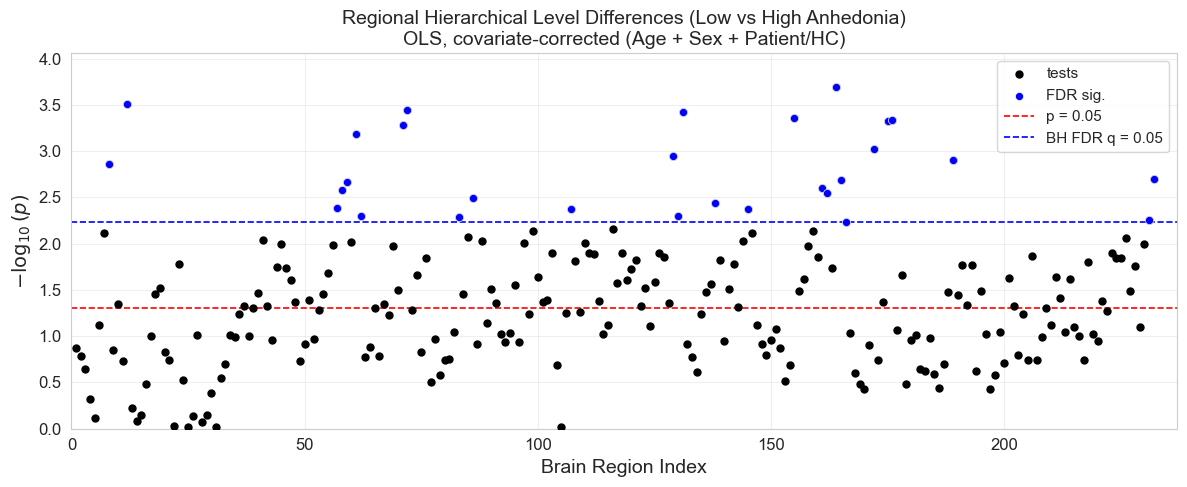

Per-region OLS: y ~ anhedonia_group + Age + Sex + Patient/HC   (N subjects per fit = 206)
Regions with uncorrected p < 0.05: 122/232
Regions surviving BH FDR q < 0.05: 29/232

FDR-significant regions (index | β HIGH-vs-LOW | p | q):
  region   8  β=+0.0227 (HIGH > LOW)  p=0.001389  q=0.02478
  region  12  β=+0.0393 (HIGH > LOW)  p=0.0003096  q=0.01517
  region  57  β=-0.0366 (HIGH < LOW)  p=0.004163  q=0.04129
  region  58  β=-0.0415 (HIGH < LOW)  p=0.002602  q=0.03354
  region  59  β=-0.0392 (HIGH < LOW)  p=0.002167  q=0.03143
  region  61  β=-0.0493 (HIGH < LOW)  p=0.0006467  q=0.01667
  region  62  β=-0.0354 (HIGH < LOW)  p=0.005079  q=0.04415
  region  71  β=-0.0371 (HIGH < LOW)  p=0.0005231  q=0.01517
  region  72  β=-0.0440 (HIGH < LOW)  p=0.0003556  q=0.01517
  region  83  β=-0.0275 (HIGH < LOW)  p=0.005139  q=0.04415
  region  86  β=-0.0406 (HIGH < LOW)  p=0.003211  q=0.03725
  region 107  β=-0.0303 (HIGH < LOW)  p=0.004271  q=0.04129
  region 129  β=-0.0368 (HIGH < LOW)  p=0.0

In [56]:
# %% Regional Trophic Level Analysis — OLS (covariate-corrected, Manhattan plot)
# Per-region hierarchical level ~ anhedonia_group + Age + Sex + Patient/HC
# The per-region p-value is the p-value of anhedonia_group[T.HIGH], i.e. the
# anhedonia effect after partialling out age, sex and patient/HC status.
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

N_regions = hierarchicallevels_LOW.shape[1]  # 232

# --- 1. Build the per-subject covariate frame ONCE (covariates are region-independent) ---
# Stack LOW + HIGH subjects; the per-region outcome 'y' is swapped in inside the loop.
base = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'anhedonia_group': 'LOW',
                  'row': np.arange(len(ids_low)),  'grp': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'anhedonia_group': 'HIGH',
                  'row': np.arange(len(ids_high)), 'grp': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

# Same recoding / reference levels as every other OLS in this notebook:
# reference = LOW anhedonia, Female, Healthy Control
base['sex'] = base['sex'].replace('O', np.nan)
base['anhedonia_group'] = pd.Categorical(base['anhedonia_group'], categories=['LOW', 'HIGH'])
base['sex']             = pd.Categorical(base['sex'],             categories=['F', 'M'])

# Row indices into hierarchicallevels_LOW / _HIGH for each dataframe row
low_rows  = base.index[base['grp'] == 'LOW']
high_rows = base.index[base['grp'] == 'HIGH']
low_src   = base.loc[low_rows,  'row'].to_numpy()
high_src  = base.loc[high_rows, 'row'].to_numpy()

# --- 2. Per-region OLS: extract beta and p-value for anhedonia_group[T.HIGH] ---
p_values = np.full(N_regions, np.nan)
betas    = np.full(N_regions, np.nan)

for i in range(N_regions):
    y = np.empty(len(base))
    y[low_rows]  = hierarchicallevels_LOW[low_src,  i]
    y[high_rows] = hierarchicallevels_HIGH[high_src, i]
    base['y'] = y

    res = smf.ols('y ~ anhedonia_group + Age_clean + sex + is_patient',
                  data=base).fit()
    betas[i]    = res.params['anhedonia_group[T.HIGH]']
    p_values[i] = res.pvalues['anhedonia_group[T.HIGH]']

neg_log_p = -np.log10(p_values)

# --- 3. Thresholds ---
alpha = 0.05
thresh_unc = -np.log10(alpha)  # uncorrected

reject_fdr, p_fdr, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
if np.any(reject_fdr):
    thresh_fdr = -np.log10(np.max(p_values[reject_fdr]))  # largest still-significant raw p
else:
    thresh_fdr = None

# --- 4. Manhattan plot ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, N_regions + 1)

ax.scatter(x, neg_log_p, s=25, c='k', zorder=3, label='tests')

if np.any(reject_fdr):
    ax.scatter(x[reject_fdr], neg_log_p[reject_fdr], s=34, c='blue',
               edgecolors='white', linewidths=0.5, zorder=4, label='FDR sig.')

ax.axhline(thresh_unc, color='red', linestyle='--', linewidth=1.2, label='p = 0.05')
if thresh_fdr is not None:
    ax.axhline(thresh_fdr, color='blue', linestyle='--', linewidth=1.2, label='BH FDR q = 0.05')

ax.set_xlabel('Brain Region Index', fontsize=14)
ax.set_ylabel('$-\\log_{10}(p)$', fontsize=14)
ax.set_title('Regional Hierarchical Level Differences (Low vs High Anhedonia)\n'
             'OLS, covariate-corrected (Age + Sex + Patient/HC)', fontsize=14)
ax.set_xlim(0, N_regions + 5)
y_top = max(np.nanmax(neg_log_p), thresh_unc) * 1.1
ax.set_ylim(0, y_top)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('manhattan_plot.png', dpi=600, bbox_inches='tight')
plt.show()

# --- 5. Summary ---
n_unc = np.sum(p_values < alpha)
n_fdr = np.sum(reject_fdr)
print(f'Per-region OLS: y ~ anhedonia_group + Age + Sex + Patient/HC   (N subjects per fit = {int(res.nobs)})')
print(f'Regions with uncorrected p < 0.05: {n_unc}/{N_regions}')
print(f'Regions surviving BH FDR q < 0.05: {n_fdr}/{N_regions}')

if n_fdr > 0:
    print('\nFDR-significant regions (index | β HIGH-vs-LOW | p | q):')
    for idx in np.where(reject_fdr)[0]:
        direction = 'HIGH > LOW' if betas[idx] > 0 else 'HIGH < LOW'
        print(f'  region {idx+1:3d}  β={betas[idx]:+.4f} ({direction})  '
              f'p={p_values[idx]:.4g}  q={p_fdr[idx]:.4g}')


In [57]:
# %% Load region labels
label_file = '/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/atlases/Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S2_label.txt'

with open(label_file, 'r') as f:
    lines = f.read().strip().splitlines()

# Every odd line (0-indexed) is the label name, every even line is "index R G B A"
region_labels = [lines[i] for i in range(0, len(lines), 2)]

# Verify: should be 232 labels, and indices should match 1-232
assert len(region_labels) == 232, f'Expected 232 labels, got {len(region_labels)}'

# Now region_labels[i] is the name for column i of hierarchicallevels_LOW/HIGH
# e.g. region_labels[0] = 'aHIP-rh', region_labels[231] = '7Networks_RH_Default_pCunPCC_3'
print(region_labels[:5])   # first 5
print(region_labels[32:35]) # first cortical LH regions


['aHIP-rh', 'pHIP-rh', 'lAMY-rh', 'mAMY-rh', 'THA-DP-rh']
['7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3']


In [58]:
# %% Top regions by FDR-corrected significance (with atlas labels)
top_n = 10

# Indices of FDR-significant regions, sorted by raw p (most significant first)
sig_idx = np.where(reject_fdr)[0]
sig_idx = sig_idx[np.argsort(p_values[sig_idx])]

print(f'{n_fdr} region(s) survive BH FDR q < {alpha}.')

if n_fdr == 0:
    print('Nothing to report — no region passes FDR correction.')
else:
    show = sig_idx[:top_n]
    print(f'\nTop {len(show)} (rank | region | label | β | direction | p | q):')
    print('-' * 78)
    for rank, idx in enumerate(show, 1):
        direction = 'HIGH > LOW' if betas[idx] > 0 else 'HIGH < LOW'
        print(f'{rank:2d}. region {idx+1:3d}  {region_labels[idx]:<40s} '
              f'β={betas[idx]:+.4f}  {direction}  '
              f'p={p_values[idx]:.3g}  q={p_fdr[idx]:.3g}')


29 region(s) survive BH FDR q < 0.05.

Top 10 (rank | region | label | β | direction | p | q):
------------------------------------------------------------------------------
 1. region 164  7Networks_RH_SomMot_17                   β=-0.0488  HIGH < LOW  p=0.000204  q=0.0152
 2. region  12  aGP-rh                                   β=+0.0393  HIGH > LOW  p=0.00031  q=0.0152
 3. region  72  7Networks_LH_DorsAttn_Post_10            β=-0.0440  HIGH < LOW  p=0.000356  q=0.0152
 4. region 131  7Networks_LH_Default_pCunPCC_4           β=-0.0373  HIGH < LOW  p=0.000376  q=0.0152
 5. region 155  7Networks_RH_SomMot_8                    β=-0.0410  HIGH < LOW  p=0.000438  q=0.0152
 6. region 176  7Networks_RH_DorsAttn_Post_10            β=-0.0430  HIGH < LOW  p=0.000458  q=0.0152
 7. region 175  7Networks_RH_DorsAttn_Post_9             β=-0.0396  HIGH < LOW  p=0.000474  q=0.0152
 8. region  71  7Networks_LH_DorsAttn_Post_9             β=-0.0371  HIGH < LOW  p=0.000523  q=0.0152
 9. region  61  7Ne

### OLS trophic levels

In [59]:
# --- Approach 1: Hierarchical level gap (cortex - subcortex) per subject ---
# Positive gap = cortex is higher in hierarchy than subcortex
hl_cortex_mean_LOW = np.mean(hierarchicallevels_LOW[:, cortical_idx], axis=1)
hl_subcortex_mean_LOW = np.mean(hierarchicallevels_LOW[:, subcortical_idx], axis=1)
hl_gap_LOW = hl_cortex_mean_LOW - hl_subcortex_mean_LOW

hl_cortex_mean_HIGH = np.mean(hierarchicallevels_HIGH[:, cortical_idx], axis=1)
hl_subcortex_mean_HIGH = np.mean(hierarchicallevels_HIGH[:, subcortical_idx], axis=1)
hl_gap_HIGH = hl_cortex_mean_HIGH - hl_subcortex_mean_HIGH

In [60]:
# %% OLS: Cortex & Subcortex Hierarchical Levels ~ Anhedonia Group + Age + Sex + Patient/HC

df_cx = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,
                  'hl_cortex':    hl_cortex_mean_LOW,
                  'hl_subcortex': hl_subcortex_mean_LOW,
                  'hl_cx_gap':    hl_gap_LOW,
                  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high,
                  'hl_cortex':    hl_cortex_mean_HIGH,
                  'hl_subcortex': hl_subcortex_mean_HIGH,
                  'hl_cx_gap':    hl_gap_HIGH,
                  'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_cx['sex']             = df_cx['sex'].replace('O', np.nan)
df_cx['anhedonia_group'] = pd.Categorical(df_cx['anhedonia_group'], categories=['LOW', 'HIGH'])
df_cx['sex']             = pd.Categorical(df_cx['sex'],             categories=['F', 'M'])

for outcome, label in [
    ('hl_cortex',    'Cortex Mean Hierarchical Level'),
    ('hl_subcortex', 'Subcortex Mean Hierarchical Level'),
    ('hl_cx_gap',    'Hierarchical Gap (Cortex − Subcortex)'),
]:
    result = smf.ols(f'{outcome} ~ anhedonia_group + Age_clean + sex + is_patient', data=df_cx).fit()
    coef         = result.params['anhedonia_group[T.HIGH]']
    pval         = result.pvalues['anhedonia_group[T.HIGH]']
    ci_lo, ci_hi = result.conf_int().loc['anhedonia_group[T.HIGH]']

    print('==============================')
    print(f'{label} — OLS Result')
    print('==============================')
    print(f'  Anhedonia group (HIGH vs LOW):')
    print(f'    β  = {coef:.5f}')
    print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
    print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
    print(f'\n  Covariates:')
    for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
        print(f'    {term:<22}  β={result.params[term]:.5f},  p={result.pvalues[term]:.4f}')
    print(f'\n  Model fit:  R²={result.rsquared:.3f},  adj-R²={result.rsquared_adj:.3f},  N={int(result.nobs)}\n')


Cortex Mean Hierarchical Level — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.02473
    95% CI = [-0.04667, -0.00280]
    p  = 0.0273  *** significant after covariate correction

  Covariates:
    Age_clean               β=-0.00095,  p=0.0140
    sex[T.M]                β=-0.00049,  p=0.9620
    is_patient              β=-0.01388,  p=0.1913

  Model fit:  R²=0.081,  adj-R²=0.063,  N=206

Subcortex Mean Hierarchical Level — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.00173
    95% CI = [-0.01828, 0.01481]
    p  = 0.8365  ns after covariate correction

  Covariates:
    Age_clean               β=-0.00069,  p=0.0174
    sex[T.M]                β=-0.00264,  p=0.7333
    is_patient              β=-0.01125,  p=0.1604

  Model fit:  R²=0.044,  adj-R²=0.025,  N=206

Hierarchical Gap (Cortex − Subcortex) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.02300
    95% CI = [-0.03157, -0.01443]
    p  = 0.0000  *** significant after covariate correction

  Covariat

/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


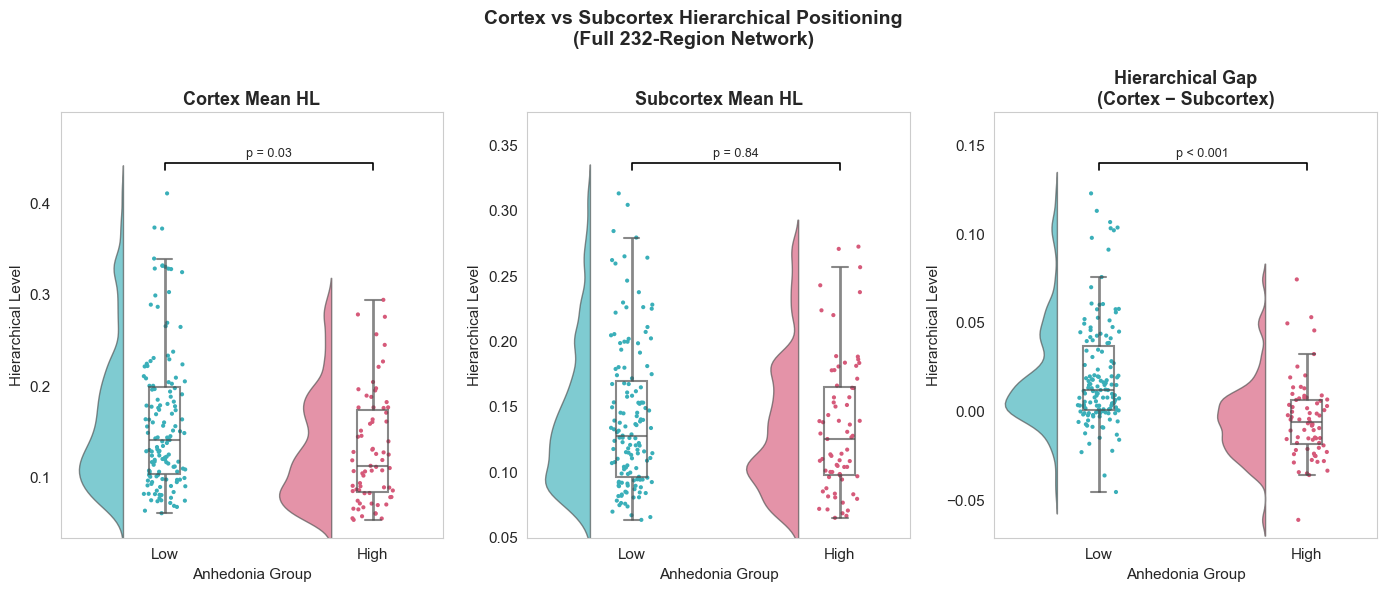

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import pandas as pd
import ptitprince as pt

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

GROUP_COLORS = {'Low': '#3AAFB9', 'High': '#D65A7A'}
group_order  = ['Low', 'High']

outcomes = {
    'hl_cortex':    'Cortex Mean HL',
    'hl_subcortex': 'Subcortex Mean HL',
    'hl_cx_gap':    'Hierarchical Gap\n(Cortex − Subcortex)',
}

# ── Pre-compute OLS p-values (covariate-adjusted) ────────────────────────────
ols_p = {}
for col in outcomes:
    r = smf.ols(f'{col} ~ anhedonia_group + Age_clean + sex + is_patient', data=df_cx).fit()
    ols_p[col] = r.pvalues['anhedonia_group[T.HIGH]']

# ── Build long-form data ─────────────────────────────────────────────────────
plot_rows = []
for col, label in outcomes.items():
    for grp in group_order:
        vals = df_cx[df_cx['anhedonia_group'].str.upper() == grp.upper()][col].dropna()
        for v in vals:
            plot_rows.append({'Measure': label, 'Group': grp, 'Value': v})

plot_df = pd.DataFrame(plot_rows)

# ── Annotation helper ────────────────────────────────────────────────────────
def add_pvalue_annotation(ax, p_val):
    ymin, ymax = ax.get_ylim()
    y_range   = ymax - ymin
    bracket_y = ymax + y_range * 0.02
    tick_h    = y_range * 0.02

    ax.plot([0, 0, 1, 1],
            [bracket_y, bracket_y + tick_h, bracket_y + tick_h, bracket_y],
            lw=1.2, color='black', clip_on=False)

    if p_val < 0.001:
        label = 'p < 0.001'
    elif p_val < 0.01:
        label = f'p = {p_val:.3f}'
    else:
        label = f'p = {p_val:.2f}'

    ax.text(0.5, bracket_y + tick_h * 1.5, label,
            ha='center', va='bottom', fontsize=9)
    ax.set_ylim(top=ymax + y_range * 0.18)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, (col, title) in zip(axes, outcomes.items()):
    data = plot_df[plot_df['Measure'] == title]

    pt.RainCloud(
        data=data, x='Group', y='Value',
        order=group_order,
        palette=[GROUP_COLORS[g] for g in group_order],
        ax=ax,
        orient='v',
        width_viol=0.5,
        width_box=0.15,
        point_size=3,
        alpha=0.65,
        cut=2,
        box_showfliers=False,
        box_linewidth=1.5,  # ← adjust to taste
    )

    
    ax.grid(False)  # ← add this
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Anhedonia Group', fontsize=11)
    ax.set_ylabel('Hierarchical Level', fontsize=11)

    add_pvalue_annotation(ax, ols_p[col])

fig.suptitle('Cortex vs Subcortex Hierarchical Positioning\n(Full 232-Region Network)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('violins_hierarchical_levels.png', dpi=600, bbox_inches='tight')
plt.show()


In [62]:
# saving these for brain rendering 
cortical_hl_low_rendering = np.mean(hierarchicallevels_LOW[:,cortical_idx], axis=0)
cortical_hl_high_rendering = np.mean(hierarchicallevels_HIGH[:,cortical_idx], axis=0)
cortical_hl_diff_rendering = cortical_hl_low_rendering-cortical_hl_high_rendering
np.savetxt('./outputs/brain_rendering/cortical_hl_low_rendering.txt', cortical_hl_low_rendering, delimiter='\t')
np.savetxt('./outputs/brain_rendering/cortical_hl_high_rendering.txt', cortical_hl_high_rendering, delimiter='\t')
np.savetxt('./outputs/brain_rendering/cortical_hl_diff_rendering.txt', cortical_hl_diff_rendering, delimiter='\t')

In [63]:
# %% Sensitivity: Cortex & Subcortex Hierarchical Levels — Patients Only + Broad Dx Category

import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Ensure these covariates exist on demos
if 'Age_clean' not in demos.columns:
    demos['Age_clean'] = demos['Age'].replace(999, np.nan)

if 'is_patient' not in demos.columns:
    demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)

# Broad diagnostic-category mapping
dx_map_cx = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other'
}

# Build per-subject dataframe
df_cx_sens = pd.concat([
    pd.DataFrame({
        'subjectkey': ids_low,
        'hl_cortex': hl_cortex_mean_LOW,
        'hl_subcortex': hl_subcortex_mean_LOW,
        'hl_cx_gap': hl_gap_LOW,
        'anhedonia_group': 'LOW'
    }),
    pd.DataFrame({
        'subjectkey': ids_high,
        'hl_cortex': hl_cortex_mean_HIGH,
        'hl_subcortex': hl_subcortex_mean_HIGH,
        'hl_cx_gap': hl_gap_HIGH,
        'anhedonia_group': 'HIGH'
    }),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Primary_Dx_Payman']],
    on='subjectkey', how='left'
)

df_cx_sens['sex'] = df_cx_sens['sex'].replace('O', np.nan)
df_cx_sens['anhedonia_group'] = pd.Categorical(
    df_cx_sens['anhedonia_group'],
    categories=['LOW', 'HIGH']
)
df_cx_sens['sex'] = pd.Categorical(df_cx_sens['sex'], categories=['F', 'M'])

df_cx_sens['Dx_label'] = (
    df_cx_sens['Primary_Dx_Payman']
    .replace(999, 'HC')
    .astype(str)
    .str.strip()
)

df_cx_sens['Dx_broad'] = pd.Categorical(
    df_cx_sens['Dx_label'].map(dx_map_cx),
    categories=['Mood', 'Anxiety_Trauma', 'Other']
)

# Patients-only dataframe used by Models 2 and 3
df_cx_patients = df_cx_sens[df_cx_sens['is_patient'] == 1].copy()
n_low_pat = (df_cx_patients['anhedonia_group'] == 'LOW').sum()
n_high_pat = (df_cx_patients['anhedonia_group'] == 'HIGH').sum()

print('Dx_broad counts by group:')
print(pd.crosstab(df_cx_patients['anhedonia_group'], df_cx_patients['Dx_broad']))
print()

outcomes_cx = [
    ('hl_cortex', 'Cortex Mean Hierarchical Level'),
    ('hl_subcortex', 'Subcortex Mean Hierarchical Level'),
    ('hl_cx_gap', 'Hierarchical Gap (Cortex − Subcortex)'),
]

for outcome, label in outcomes_cx:
    # --- Model 1 refit only for clean comparison table ---
    result_cx_full = smf.ols(
        f'{outcome} ~ anhedonia_group + Age_clean + sex + is_patient',
        data=df_cx_sens
    ).fit()

    coef_cx_full = result_cx_full.params['anhedonia_group[T.HIGH]']
    pval_cx_full = result_cx_full.pvalues['anhedonia_group[T.HIGH]']

    # --- Model 2: Patients only ---
    result_cx_pat = smf.ols(
        f'{outcome} ~ anhedonia_group + Age_clean + sex',
        data=df_cx_patients
    ).fit()

    coef_cx_pat = result_cx_pat.params['anhedonia_group[T.HIGH]']
    pval_cx_pat = result_cx_pat.pvalues['anhedonia_group[T.HIGH]']
    ci_lo_cp, ci_hi_cp = result_cx_pat.conf_int().loc['anhedonia_group[T.HIGH]']

    # --- Model 3: Patients only + broad diagnostic category ---
    result_cx_dx = smf.ols(
        f'{outcome} ~ anhedonia_group + Age_clean + sex + Dx_broad',
        data=df_cx_patients.dropna(subset=['Dx_broad'])
    ).fit()

    coef_cx_dx = result_cx_dx.params['anhedonia_group[T.HIGH]']
    pval_cx_dx = result_cx_dx.pvalues['anhedonia_group[T.HIGH]']
    ci_lo_cd, ci_hi_cd = result_cx_dx.conf_int().loc['anhedonia_group[T.HIGH]']

    print('==============================')
    print(f'{label} — Patients Only')
    print(f'  N = {int(result_cx_pat.nobs)}  (LOW={n_low_pat}, HIGH={n_high_pat})')
    print('==============================')
    print('  Anhedonia group (HIGH vs LOW):')
    print(f'    β  = {coef_cx_pat:.5f}')
    print(f'    95% CI = [{ci_lo_cp:.5f}, {ci_hi_cp:.5f}]')
    print(f'    p  = {pval_cx_pat:.4f}  {"*** significant" if pval_cx_pat < 0.05 else "ns"}')
    print(f'\n  Covariates:')
    for term in ['Age_clean', 'sex[T.M]']:
        print(f'    {term:<22}  β={result_cx_pat.params[term]:.5f},  p={result_cx_pat.pvalues[term]:.4f}')
    print(f'\n  Model fit:  R²={result_cx_pat.rsquared:.3f},  adj-R²={result_cx_pat.rsquared_adj:.3f}')

    print('\n==============================')
    print(f'{label} — Patients Only + Broad Dx Category')
    print(f'  N = {int(result_cx_dx.nobs)}')
    print('==============================')
    print('  Anhedonia group (HIGH vs LOW):')
    print(f'    β  = {coef_cx_dx:.5f}')
    print(f'    95% CI = [{ci_lo_cd:.5f}, {ci_hi_cd:.5f}]')
    print(f'    p  = {pval_cx_dx:.4f}  {"*** significant" if pval_cx_dx < 0.05 else "ns"}')
    print(f'\n  Covariates:')
    for term in ['Age_clean', 'sex[T.M]', 'Dx_broad[T.Anxiety_Trauma]', 'Dx_broad[T.Other]']:
        print(f'    {term:<35}  β={result_cx_dx.params[term]:.5f},  p={result_cx_dx.pvalues[term]:.4f}')
    print(f'\n  Model fit:  R²={result_cx_dx.rsquared:.3f},  adj-R²={result_cx_dx.rsquared_adj:.3f}')

    print('\n  ── Three-way comparison ──')
    print(f'  {"Model":<40} {"β":>9} {"p":>9}')
    print(f'  {"Full sample (+ is_patient)":<40} {coef_cx_full:>9.5f} {pval_cx_full:>9.4f}')
    print(f'  {"Patients only":<40} {coef_cx_pat:>9.5f} {pval_cx_pat:>9.4f}')
    print(f'  {"Patients + broad Dx category":<40} {coef_cx_dx:>9.5f} {pval_cx_dx:>9.4f}')
    print()


Dx_broad counts by group:
Dx_broad         Mood  Anxiety_Trauma  Other
anhedonia_group                             
LOW                31              25     15
HIGH               31              18      8

Cortex Mean Hierarchical Level — Patients Only
  N = 125  (LOW=71, HIGH=57)
  Anhedonia group (HIGH vs LOW):
    β  = -0.02881
    95% CI = [-0.05459, -0.00304]
    p  = 0.0288  *** significant

  Covariates:
    Age_clean               β=-0.00084,  p=0.0820
    sex[T.M]                β=0.01393,  p=0.2899

  Model fit:  R²=0.091,  adj-R²=0.068

Cortex Mean Hierarchical Level — Patients Only + Broad Dx Category
  N = 125
  Anhedonia group (HIGH vs LOW):
    β  = -0.03048
    95% CI = [-0.05621, -0.00475]
    p  = 0.0206  *** significant

  Covariates:
    Age_clean                            β=-0.00082,  p=0.0892
    sex[T.M]                             β=0.01680,  p=0.2037
    Dx_broad[T.Anxiety_Trauma]           β=-0.00306,  p=0.8273
    Dx_broad[T.Other]                    β=-0.0

### OLS for information flow asymmetry, cortex to subcortex

In [64]:
# --- Approach 2: 2x2 aggregated directed flow ---
# Sum all connections between compartments to get net directed flow
# Pre-allocate arrays for flow sums
flow_sub2cor_LOW = np.zeros(NSUB_LOW)  # Direction: Subcortical (Src) -> Cortical (Tgt)
flow_cor2sub_LOW = np.zeros(NSUB_LOW)  # Direction: Cortical (Src) -> Subcortical (Tgt)
flow_sub2cor_HIGH = np.zeros(NSUB_HIGH)
flow_cor2sub_HIGH = np.zeros(NSUB_HIGH)

# --- Process Low Anhedonia Group ---
for s in range(NSUB_LOW):
    C = Ceff_LOW[s]
    
    # Sub -> Cor: Source is Sub (Cols), Target is Cor (Rows)
    # Corrected: Rows = cortical_idx, Cols = subcortical_idx
    flow_sub2cor_LOW[s] = np.sum(C[np.ix_(cortical_idx, subcortical_idx)])
    
    # Cor -> Sub: Source is Cor (Cols), Target is Sub (Rows)
    # Corrected: Rows = subcortical_idx, Cols = cortical_idx
    flow_cor2sub_LOW[s] = np.sum(C[np.ix_(subcortical_idx, cortical_idx)])

# --- Process High Anhedonia Group ---
for s in range(NSUB_HIGH):
    C = Ceff_HIGH[s]
    
    # Sub -> Cor: Source is Sub (Cols), Target is Cor (Rows)
    flow_sub2cor_HIGH[s] = np.sum(C[np.ix_(cortical_idx, subcortical_idx)])
    
    # Cor -> Sub: Source is Cor (Cols), Target is Sub (Rows)
    flow_cor2sub_HIGH[s] = np.sum(C[np.ix_(subcortical_idx, cortical_idx)])

# --- Statistics and Interpretation ---

# Top-Down Dominance:
# Positive (+) = Top-down dominant (Cortex driving the Subcortex)
# Negative (-) = Bottom-up dominant (Subcortex driving the Cortex)
td_dominance_LOW = flow_cor2sub_LOW - flow_sub2cor_LOW
td_dominance_HIGH = flow_cor2sub_HIGH - flow_sub2cor_HIGH

#### Why computing the normalized index:
**We compute the normalized index, because we want to make sure that it is not the scale of A-B that determines the difference, but the actual difference between the two groups. For instance 50-45=5 and the normalized value is 5/(50+45)=0.052 and then 500-480=20 and the normalized value is 20/(500+480)=0.02. So the difference in the former is greater when normalized, but the nominal difference without normalization would tell us incorrectly that the difference in the latter is greater.**

In [65]:
# --- Normalized Top-Down Dominance Index: (A - B) / (A + B) ---
# A = cor2sub (top-down), B = sub2cor (bottom-up)
# Range: [-1, +1]
#   +1 = purely top-down (cortex -> subcortex)
#   -1 = purely bottom-up (subcortex -> cortex)
#    0 = balanced
# This removes the effect of overall connectivity magnitude, so it compares
# the *balance* of directed flow rather than its absolute size.

eps = 1e-12  # guard against division by zero

total_flow_LOW  = flow_cor2sub_LOW  + flow_sub2cor_LOW
total_flow_HIGH = flow_cor2sub_HIGH + flow_sub2cor_HIGH

td_dominance_norm_LOW  = (flow_cor2sub_LOW  - flow_sub2cor_LOW)  / (total_flow_LOW  + eps)
td_dominance_norm_HIGH = (flow_cor2sub_HIGH - flow_sub2cor_HIGH) / (total_flow_HIGH + eps)

print("Normalized Top-Down Dominance Index  (A - B) / (A + B)")
print(f"  LOW : mean = {td_dominance_norm_LOW.mean():+.4f}  (SD {td_dominance_norm_LOW.std(ddof=1):.4f})")
print(f"  HIGH: mean = {td_dominance_norm_HIGH.mean():+.4f}  (SD {td_dominance_norm_HIGH.std(ddof=1):.4f})")

Normalized Top-Down Dominance Index  (A - B) / (A + B)
  LOW : mean = -0.0148  (SD 0.0178)
  HIGH: mean = +0.0014  (SD 0.0137)


In [66]:
# %% OLS: Top-Down Flow Dominance ~ Anhedonia Group + Age + Sex + Patient/HC
df_ols_td = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'td_dominance': td_dominance_norm_LOW,  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'td_dominance': td_dominance_norm_HIGH, 'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_ols_td['sex'] = df_ols_td['sex'].replace('O', np.nan)
df_ols_td['anhedonia_group'] = pd.Categorical(df_ols_td['anhedonia_group'], categories=['LOW', 'HIGH'])
df_ols_td['sex']             = pd.Categorical(df_ols_td['sex'],             categories=['F', 'M'])

result_td = smf.ols('td_dominance ~ anhedonia_group + Age_clean + sex + is_patient', data=df_ols_td).fit()

coef  = result_td.params['anhedonia_group[T.HIGH]']
pval  = result_td.pvalues['anhedonia_group[T.HIGH]']
pval_td = pval
ci_lo, ci_hi = result_td.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('TOP-DOWN FLOW DOMINANCE (Cor→Sub − Sub→Cor) — OLS Result')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef:.5f}')
print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
    print(f'    {term:<22}  β={result_td.params[term]:.5f},  p={result_td.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_td.rsquared:.3f},  adj-R²={result_td.rsquared_adj:.3f},  N={int(result_td.nobs)}')


TOP-DOWN FLOW DOMINANCE (Cor→Sub − Sub→Cor) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = 0.01501
    95% CI = [0.00993, 0.02009]
    p  = 0.0000  *** significant after covariate correction

  Covariates:
    Age_clean               β=0.00016,  p=0.0766
    sex[T.M]                β=-0.00321,  p=0.1781
    is_patient              β=0.00183,  p=0.4566

  Model fit:  R²=0.205,  adj-R²=0.189,  N=206


In [67]:
# %% Sensitivity Analysis: Top-Down Flow Dominance — Patients Only
df_patients_td = df_ols_td[df_ols_td['is_patient'] == 1].copy()

result_td_patients = smf.ols('td_dominance ~ anhedonia_group + Age_clean + sex', data=df_patients_td).fit()

coef_p  = result_td_patients.params['anhedonia_group[T.HIGH]']
pval_p  = result_td_patients.pvalues['anhedonia_group[T.HIGH]']
ci_lo_p, ci_hi_p = result_td_patients.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('TOP-DOWN FLOW DOMINANCE — Patients Only (sensitivity)')
print(f'  N = {int(result_td_patients.nobs)}  (LOW={len(df_patients_td[df_patients_td.anhedonia_group=="LOW"])}, HIGH={len(df_patients_td[df_patients_td.anhedonia_group=="HIGH"])})')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_p:.5f}')
print(f'    95% CI = [{ci_lo_p:.5f}, {ci_hi_p:.5f}]')
print(f'    p  = {pval_p:.4f}  {"*** significant" if pval_p < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]']:
    print(f'    {term:<22}  β={result_td_patients.params[term]:.5f},  p={result_td_patients.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_td_patients.rsquared:.3f},  adj-R²={result_td_patients.rsquared_adj:.3f}')

# --- Comparison summary ---
print('\n  ── Comparison with full-sample OLS ──')
print(f'  {"Model":<30} {"β":>9} {"p":>9}')
print(f'  {"Full sample (+ is_patient)":<30} {coef:>9.5f} {pval:>9.4f}')
print(f'  {"Patients only":<30} {coef_p:>9.5f} {pval_p:>9.4f}')


TOP-DOWN FLOW DOMINANCE — Patients Only (sensitivity)
  N = 125  (LOW=71, HIGH=57)
  Anhedonia group (HIGH vs LOW):
    β  = 0.01623
    95% CI = [0.01086, 0.02160]
    p  = 0.0000  *** significant

  Covariates:
    Age_clean               β=0.00012,  p=0.2128
    sex[T.M]                β=-0.00459,  p=0.0949

  Model fit:  R²=0.294,  adj-R²=0.276

  ── Comparison with full-sample OLS ──
  Model                                  β         p
  Full sample (+ is_patient)       0.01501    0.0000
  Patients only                    0.01623    0.0000


In [68]:
# %% Patients-only OLS with broad diagnostic category covariate

# --- First: bring Dx_label into df_patients_td ---
df_patients_td = df_patients_td.merge(
    df[['subjectkey', 'Dx_label']], on='subjectkey', how='left'
)

# Collapse 15 diagnoses into 3 broad DSM-5 categories
dx_map = {
    # Mood disorders
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',

    # Anxiety and trauma-related (DSM-5: OCD excluded — separate chapter)
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',

    # Other (schizophrenia-spectrum, OCD-spectrum, SUD, neurodevelopmental)
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other'
}

df_patients_td['Dx_broad'] = df_patients_td['Dx_label'].map(dx_map)
df_patients_td['Dx_broad'] = pd.Categorical(df_patients_td['Dx_broad'],
                                             categories=['Mood', 'Anxiety_Trauma', 'Other'])

# --- Check cell sizes before fitting ---
print('Dx_broad counts by group:')
print(pd.crosstab(df_patients_td['anhedonia_group'], df_patients_td['Dx_broad']))
print()

result_td_dxctrl = smf.ols(
    'td_dominance ~ anhedonia_group + Age_clean + sex + Dx_broad',
    data=df_patients_td.dropna(subset=['Dx_broad'])
).fit()

coef_dx  = result_td_dxctrl.params['anhedonia_group[T.HIGH]']
pval_dx  = result_td_dxctrl.pvalues['anhedonia_group[T.HIGH]']
ci_lo_dx, ci_hi_dx = result_td_dxctrl.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('TOP-DOWN FLOW DOMINANCE — Patients Only + Broad Dx Category')
print(f'  N = {int(result_td_dxctrl.nobs)}')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_dx:.5f}')
print(f'    95% CI = [{ci_lo_dx:.5f}, {ci_hi_dx:.5f}]')
print(f'    p  = {pval_dx:.4f}  {"*** significant" if pval_dx < 0.05 else "ns"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'Dx_broad[T.Anxiety_Trauma]', 'Dx_broad[T.Other]']:
    print(f'    {term:<35}  β={result_td_dxctrl.params[term]:.5f},  p={result_td_dxctrl.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_td_dxctrl.rsquared:.3f},  adj-R²={result_td_dxctrl.rsquared_adj:.3f}')

print('\n  ── Three-way comparison ──')
print(f'  {"Model":<40} {"β":>9} {"p":>9}')
print(f'  {"Full sample (+ is_patient)":<40} {coef:>9.5f} {pval:>9.4f}')
print(f'  {"Patients only":<40} {coef_p:>9.5f} {pval_p:>9.4f}')
print(f'  {"Patients + broad Dx category":<40} {coef_dx:>9.5f} {pval_dx:>9.4f}')


Dx_broad counts by group:
Dx_broad         Mood  Anxiety_Trauma  Other
anhedonia_group                             
LOW                31              25     15
HIGH               31              18      8

TOP-DOWN FLOW DOMINANCE — Patients Only + Broad Dx Category
  N = 125
  Anhedonia group (HIGH vs LOW):
    β  = 0.01669
    95% CI = [0.01140, 0.02198]
    p  = 0.0000  *** significant

  Covariates:
    Age_clean                            β=0.00012,  p=0.2359
    sex[T.M]                             β=-0.00543,  p=0.0469
    Dx_broad[T.Anxiety_Trauma]           β=0.00027,  p=0.9256
    Dx_broad[T.Other]                    β=0.00836,  p=0.0194

  Model fit:  R²=0.328,  adj-R²=0.300

  ── Three-way comparison ──
  Model                                            β         p
  Full sample (+ is_patient)                 0.01501    0.0000
  Patients only                              0.01623    0.0000
  Patients + broad Dx category               0.01669    0.0000


### Why doing the OLS on unnormlized
**Now that we saw the difference is significant using the normalized index, we do the regression analysis on the unnormalized value to make sure that the difference is not caused buy the scale of A+B across low vs high anhedonia**

In [69]:
# %% OLS: Top-Down Flow Dominance ~ Anhedonia Group + Age + Sex + Patient/HC
df_ols_td = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'td_dominance': td_dominance_LOW,  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'td_dominance': td_dominance_HIGH, 'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_ols_td['sex'] = df_ols_td['sex'].replace('O', np.nan)
df_ols_td['anhedonia_group'] = pd.Categorical(df_ols_td['anhedonia_group'], categories=['LOW', 'HIGH'])
df_ols_td['sex']             = pd.Categorical(df_ols_td['sex'],             categories=['F', 'M'])

result_td = smf.ols('td_dominance ~ anhedonia_group + Age_clean + sex + is_patient', data=df_ols_td).fit()

coef  = result_td.params['anhedonia_group[T.HIGH]']
pval  = result_td.pvalues['anhedonia_group[T.HIGH]']
pval_td = pval
ci_lo, ci_hi = result_td.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('TOP-DOWN FLOW DOMINANCE (Cor→Sub − Sub→Cor) — OLS Result')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef:.5f}')
print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
    print(f'    {term:<22}  β={result_td.params[term]:.5f},  p={result_td.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_td.rsquared:.3f},  adj-R²={result_td.rsquared_adj:.3f},  N={int(result_td.nobs)}')


TOP-DOWN FLOW DOMINANCE (Cor→Sub − Sub→Cor) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = 0.93208
    95% CI = [0.58915, 1.27502]
    p  = 0.0000  *** significant after covariate correction

  Covariates:
    Age_clean               β=0.00803,  p=0.1825
    sex[T.M]                β=-0.20554,  p=0.2014
    is_patient              β=0.09655,  p=0.5602

  Model fit:  R²=0.173,  adj-R²=0.157,  N=206


#### Why copmaring the cor2sub and then sub2cor separately across low vs high anhedonia
**It is important to understand why exactly there is a difference. Did cor2sub and sub2cor in opposite directions in high anhedonia, causing the difference between low vs high anhedonia? Or did they move in the same direction, but difference between them in one group is greater than the other group?**  

In [70]:
# %% OLS: Directed-flow arms (conditional decomposition) ~ Anhedonia Group + Age + Sex + Patient/HC
# Arm 1: flow_cor2sub = F(PFC→Striatum)  -> top-down arm
# Arm 2: flow_sub2cor = F(Striatum→PFC)  -> bottom-up arm
# Run ONLY as the mechanism step (interpret on edges where the normalized asymmetry was significant).

def run_arm_ols(vals_low, vals_high, label):
    df = pd.concat([
        pd.DataFrame({'subjectkey': ids_low,  'flow': vals_low,  'anhedonia_group': 'LOW'}),
        pd.DataFrame({'subjectkey': ids_high, 'flow': vals_high, 'anhedonia_group': 'HIGH'}),
    ], ignore_index=True).merge(
        demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
        on='subjectkey', how='left'
    )

    df['sex'] = df['sex'].replace('O', np.nan)
    df['anhedonia_group'] = pd.Categorical(df['anhedonia_group'], categories=['LOW', 'HIGH'])
    df['sex']             = pd.Categorical(df['sex'],             categories=['F', 'M'])

    result = smf.ols('flow ~ anhedonia_group + Age_clean + sex + is_patient', data=df).fit()

    coef = result.params['anhedonia_group[T.HIGH]']
    pval = result.pvalues['anhedonia_group[T.HIGH]']
    ci_lo, ci_hi = result.conf_int().loc['anhedonia_group[T.HIGH]']

    print('==============================')
    print(f'{label} — OLS Result')
    print('==============================')
    print(f'  Anhedonia group (HIGH vs LOW):')
    print(f'    β  = {coef:.5f}   ({"HIGH > LOW (arm UP)" if coef > 0 else "HIGH < LOW (arm DOWN)"})')
    print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
    print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
    print(f'\n  Covariates:')
    for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
        print(f'    {term:<22}  β={result.params[term]:.5f},  p={result.pvalues[term]:.4f}')
    print(f'\n  Model fit:  R²={result.rsquared:.3f},  adj-R²={result.rsquared_adj:.3f},  N={int(result.nobs)}\n')
    return result, coef, pval

# --- Arm 1: top-down  F(PFC→Striatum) ---
result_cor2sub, b_td, p_td = run_arm_ols(
    flow_cor2sub_LOW, flow_cor2sub_HIGH, 'TOP-DOWN ARM  F(Cor→Sub)')

# --- Arm 2: bottom-up  F(Striatum→PFC) ---
result_sub2cor, b_bu, p_bu = run_arm_ols(
    flow_sub2cor_LOW, flow_sub2cor_HIGH, 'BOTTOM-UP ARM  F(Sub→Cor)')

# --- Direction comparison (the "same vs opposite" read) ---
print('==============================')
print('ARM DIRECTION SUMMARY (HIGH vs LOW)')
print('==============================')
print(f'  Top-down  F(Cor→Sub):  β={b_td:+.5f}  p={p_td:.4f}')
print(f'  Bottom-up F(Sub→Cor):  β={b_bu:+.5f}  p={p_bu:.4f}')
moved = 'OPPOSITE directions  → congruent, reinforces the asymmetry' if (b_td * b_bu < 0) \
        else 'the SAME direction   → asymmetry is a differential (one arm moved more)'
print(f'  Arms moved in {moved}')


TOP-DOWN ARM  F(Cor→Sub) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -2.51470   (HIGH < LOW (arm DOWN))
    95% CI = [-4.46800, -0.56140]
    p  = 0.0119  *** significant after covariate correction

  Covariates:
    Age_clean               β=0.06453,  p=0.0605
    sex[T.M]                β=0.04087,  p=0.9644
    is_patient              β=-1.21922,  p=0.1972

  Model fit:  R²=0.060,  adj-R²=0.041,  N=206

BOTTOM-UP ARM  F(Sub→Cor) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -3.44679   (HIGH < LOW (arm DOWN))
    95% CI = [-5.47828, -1.41529]
    p  = 0.0010  *** significant after covariate correction

  Covariates:
    Age_clean               β=0.05650,  p=0.1135
    sex[T.M]                β=0.24640,  p=0.7956
    is_patient              β=-1.31577,  p=0.1810

  Model fit:  R²=0.083,  adj-R²=0.065,  N=206

ARM DIRECTION SUMMARY (HIGH vs LOW)
  Top-down  F(Cor→Sub):  β=-2.51470  p=0.0119
  Bottom-up F(Sub→Cor):  β=-3.44679  p=0.0010
  Arms moved in the SAME direct

In [71]:
print(flow_cor2sub_HIGH.mean())
print(flow_cor2sub_LOW.mean())
print(flow_sub2cor_HIGH.mean())
print(flow_sub2cor_LOW.mean())

27.490224622833548
29.98575576553047
27.414361889890465
30.911657760921614


**The results above tell us that in high anehdonia the information flow for both cor2sub and sub2cor is weaker than in low anehdonia, so they both move in the same direction. But the way they move makes cor2sub-sub2cor information flow larger in high anhedonia (27.49-27.41) than in low anhedonia (27.49-30.91)**

/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


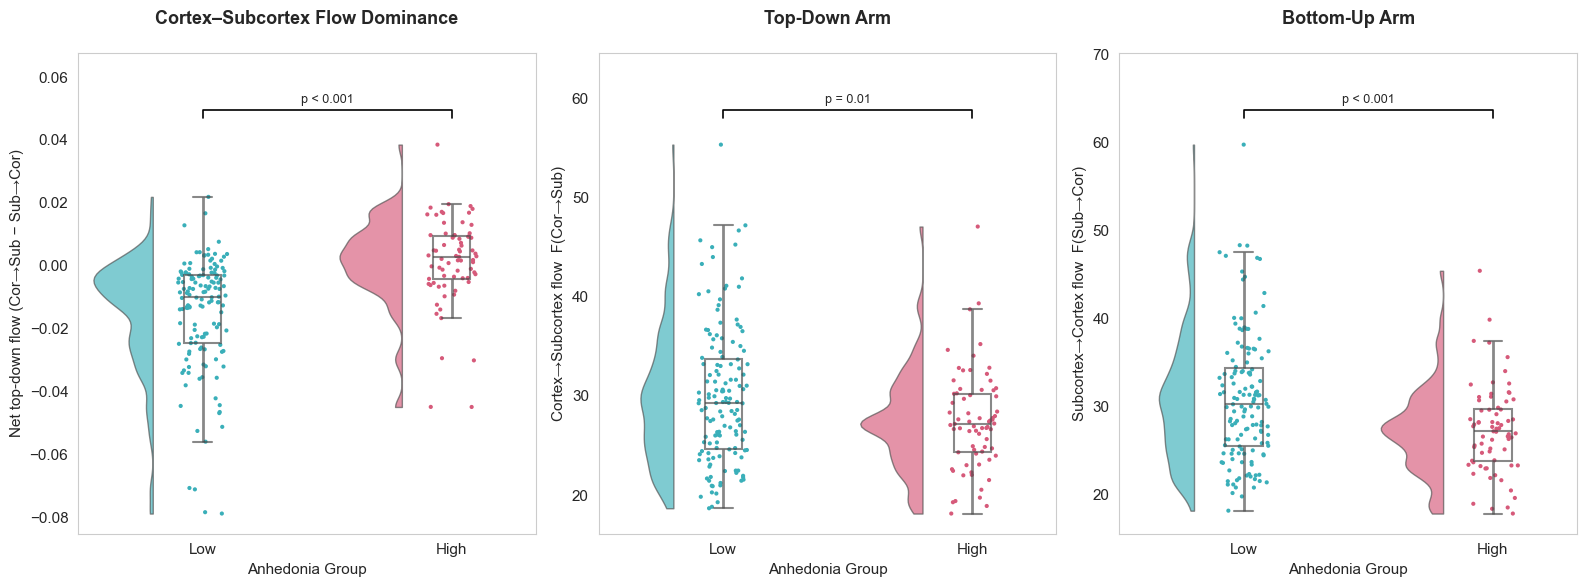

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import ptitprince as pt

# ── Long-form data ────────────────────────────────────────────────────────────
# Panel A: net top-down dominance (normalized difference)
td_df = pd.DataFrame({
    'Value': list(td_dominance_norm_LOW) + list(td_dominance_norm_HIGH),
    'Group': ['Low'] * len(td_dominance_norm_LOW) + ['High'] * len(td_dominance_norm_HIGH),
})

# Panel B: cortex -> subcortex arm
cor2sub_df = pd.DataFrame({
    'Value': list(flow_cor2sub_LOW) + list(flow_cor2sub_HIGH),
    'Group': ['Low'] * len(flow_cor2sub_LOW) + ['High'] * len(flow_cor2sub_HIGH),
})

# Panel C: subcortex -> cortex arm
sub2cor_df = pd.DataFrame({
    'Value': list(flow_sub2cor_LOW) + list(flow_sub2cor_HIGH),
    'Group': ['Low'] * len(flow_sub2cor_LOW) + ['High'] * len(flow_sub2cor_HIGH),
})

group_pal = [GROUP_COLORS[g] for g in ['Low', 'High']]

def raincloud_panel(ax, df, ylabel, title, pval):
    pt.RainCloud(
        data=df, x='Group', y='Value', order=['Low', 'High'],
        palette=group_pal, ax=ax, orient='v',
        width_viol=0.5, width_box=0.15, point_size=3, alpha=0.65,
        box_showfliers=False, box_linewidth=1.5,
    )
    ax.grid(False)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Anhedonia Group', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    add_pvalue_annotation(ax, pval)

# ── Figure: three panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

raincloud_panel(axes[0], td_df,
                'Net top-down flow (Cor→Sub − Sub→Cor)',
                'Cortex–Subcortex Flow Dominance\n', pval_td)

raincloud_panel(axes[1], cor2sub_df,
                'Cortex→Subcortex flow  F(Cor→Sub)',
                'Top-Down Arm\n', p_td)

raincloud_panel(axes[2], sub2cor_df,
                'Subcortex→Cortex flow  F(Sub→Cor)',
                'Bottom-Up Arm\n', p_bu)

plt.tight_layout()
plt.savefig('violin_topdown_flow_3panel.png', dpi=600, bbox_inches='tight')
plt.show()


### OLS + FDR: Yeo 7 Networks + Subcortex

Per-network OLS models (one per network). The p-value for `anhedonia_group[T.HIGH]` is extracted from each model, then Benjamini-Hochberg FDR is applied across all 8 comparisons. Two bar charts are produced: one with FDR-corrected p-values, one with uncorrected p-values.

In [73]:
# --- 1. Parse network membership from region_labels ---
network_indices = {}
for i, label in enumerate(region_labels):
    if i < 32:
        net = 'Subcortex'
    else:
        net = label.split('_')[2]
    network_indices.setdefault(net, []).append(i)

display_order = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Subcortex']

# Verify counts
for net in display_order:
    print(f'{net}: {len(network_indices[net])} regions')

# --- 2. Per-subject, per-network mean trophic level ---
net_means_LOW = {}
net_means_HIGH = {}
for net in display_order:
    idx = network_indices[net]
    net_means_LOW[net] = np.mean(hierarchicallevels_LOW[:, idx], axis=1)
    net_means_HIGH[net] = np.mean(hierarchicallevels_HIGH[:, idx], axis=1)

# --- 4. Yeo 7-Network + Subcortical Mapping ---
yeo_colors = {
    'Vis':          '#781286',  # Visual: Primary and secondary visual processing
    'SomMot':       '#4682B4',  # Somatomotor: Motor control and somatosensory (touch/pain)
    'DorsAttn':     '#00760E',  # Dorsal Attention: Goal-directed, "top-down" attention
    'SalVentAttn':  '#C43AFA',  # Salience/Ventral Attention: Stimulus-driven, "bottom-up" attention
    'Limbic':       '#B8CF5E',  # Limbic: Emotion, reward, and memory processing
    'Cont':         '#E69422',  # Executive Control: Decision making, planning, and task switching
    'Default':      '#CD3E4E',  # Default Mode (DMN): Internal thought, daydreaming, and self-reflection
    'Subcortex':    '#808080',  # Subcortical structures: Thalamus, Striatum, Hippocampus, etc.
}

Vis: 29 regions
SomMot: 35 regions
DorsAttn: 26 regions
SalVentAttn: 22 regions
Limbic: 12 regions
Cont: 30 regions
Default: 46 regions
Subcortex: 32 regions


YEO 7 NETWORKS + SUBCORTEX — OLS Results (FDR-corrected)
Network                β     p_raw     p_FDR  sig
--------------------------------------------------
Vis             -0.02262    0.0301    0.0713  ns
SomMot          -0.03173    0.0175    0.0713  ns
DorsAttn        -0.02395    0.0393    0.0713  ns
SalVentAttn     -0.02191    0.0689    0.0787  ns
Limbic          -0.02276    0.0446    0.0713  ns
Cont            -0.01908    0.0578    0.0770  ns
Default         -0.02673    0.0184    0.0713  ns
Subcortex       -0.00173    0.8365    0.8365  ns


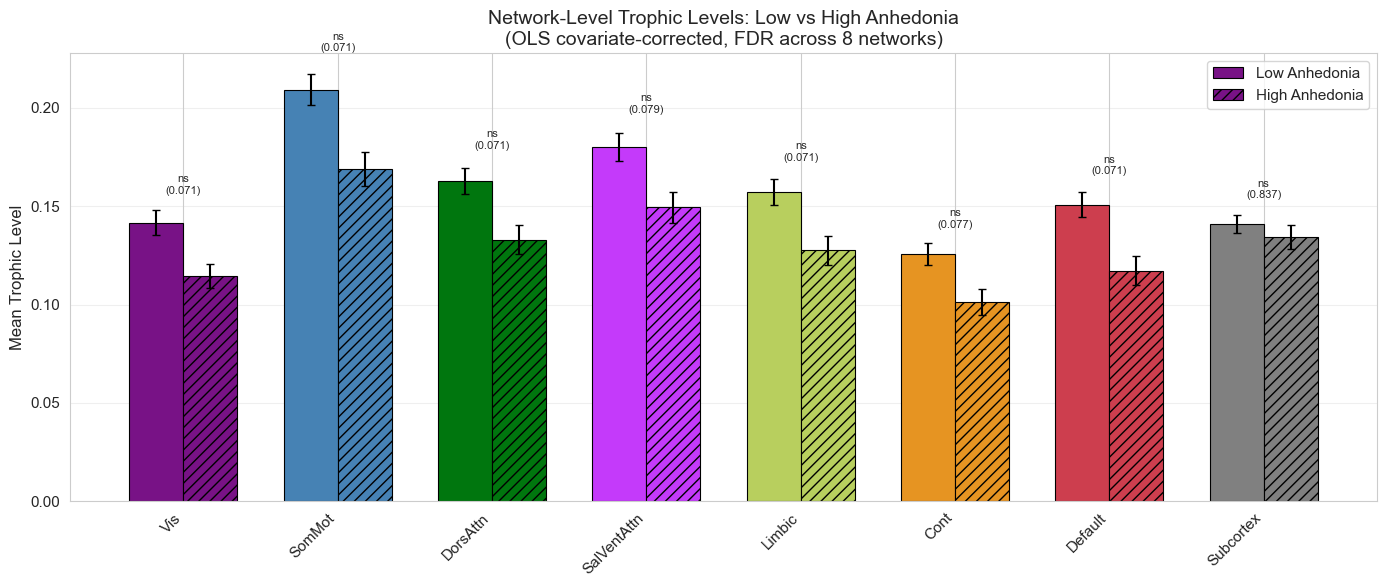

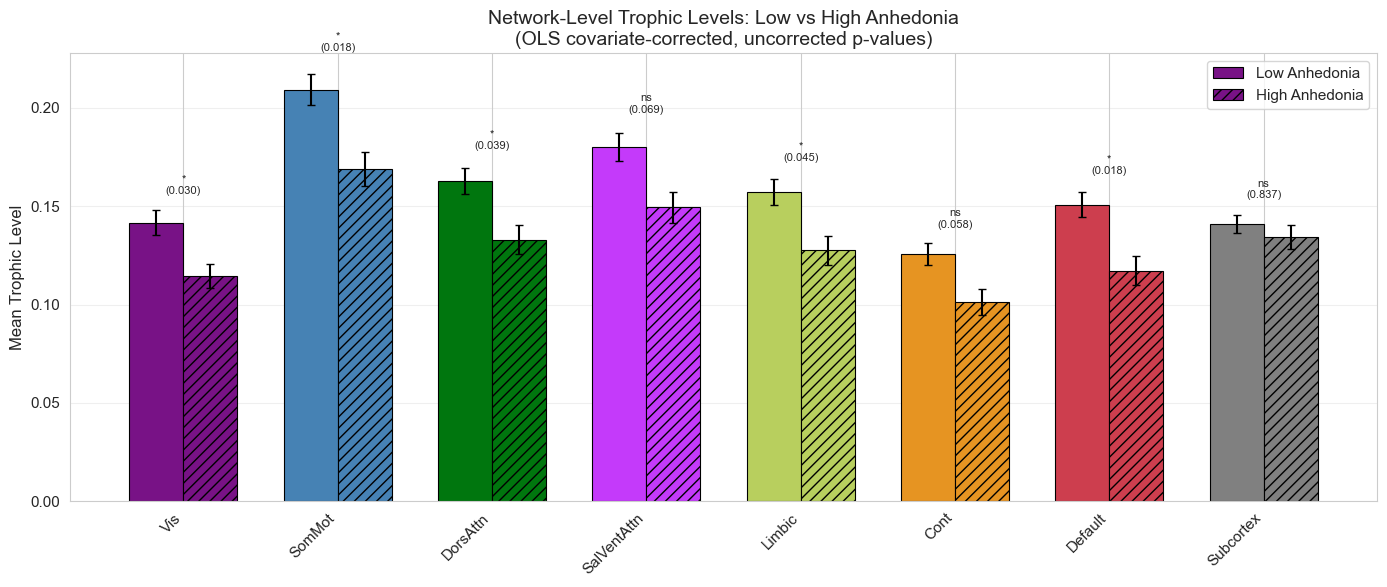

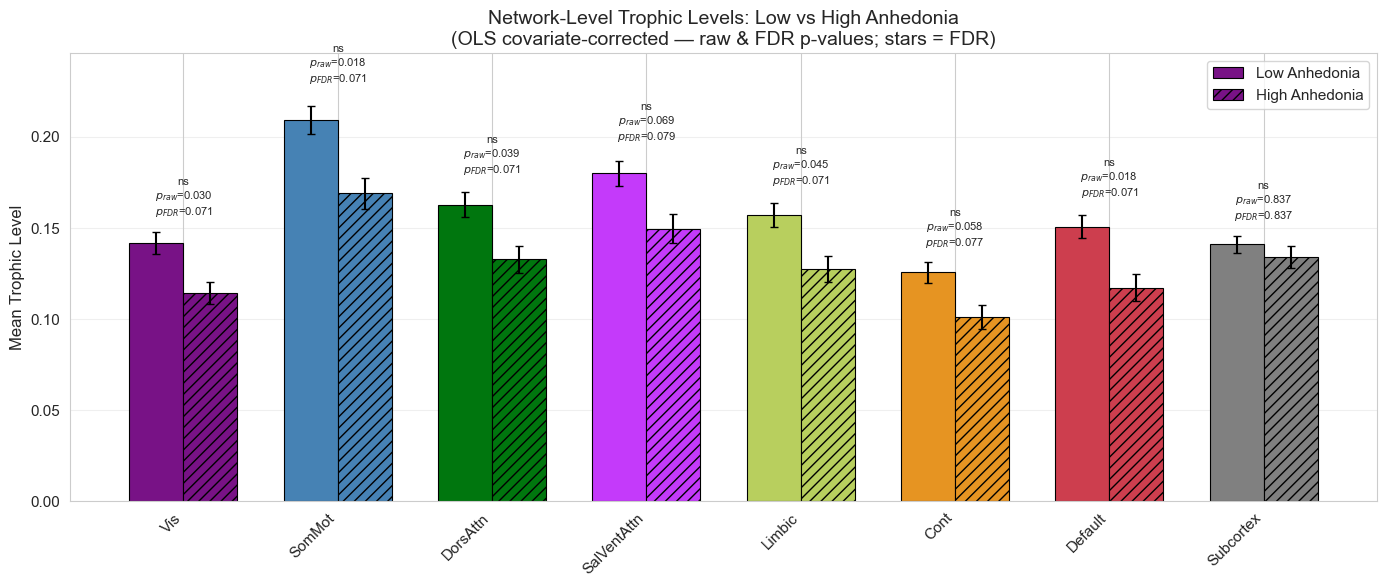

In [74]:
# %% OLS with FDR: Network-Level Trophic Levels ~ Anhedonia Group + Age + Sex + Patient/HC
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Build demographics lookup (reuse from confound check cell)
demos_lookup = demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']].copy()

raw_pvals_ols  = []
coefs_ols      = []
results_by_net = {}

for net in display_order:
    idx = network_indices[net]

    df_net = pd.concat([
        pd.DataFrame({'subjectkey': ids_low,  'net_hl': np.mean(hierarchicallevels_LOW[:, idx],  axis=1), 'anhedonia_group': 'LOW'}),
        pd.DataFrame({'subjectkey': ids_high, 'net_hl': np.mean(hierarchicallevels_HIGH[:, idx], axis=1), 'anhedonia_group': 'HIGH'}),
    ], ignore_index=True).merge(demos_lookup, on='subjectkey', how='left')

    df_net['sex'] = df_net['sex'].replace('O', np.nan)
    df_net['anhedonia_group'] = pd.Categorical(df_net['anhedonia_group'], categories=['LOW', 'HIGH'])
    df_net['sex']             = pd.Categorical(df_net['sex'],             categories=['F', 'M'])

    res = smf.ols('net_hl ~ anhedonia_group + Age_clean + sex + is_patient', data=df_net).fit()
    results_by_net[net] = res
    raw_pvals_ols.append(res.pvalues['anhedonia_group[T.HIGH]'])
    coefs_ols.append(res.params['anhedonia_group[T.HIGH]'])

# FDR correction across 8 networks
reject, pvals_fdr_ols, _, _ = multipletests(raw_pvals_ols, alpha=0.05, method='fdr_bh')

# --- Print summary table ---
print('==============================')
print('YEO 7 NETWORKS + SUBCORTEX — OLS Results (FDR-corrected)')
print('==============================')
print(f'{"Network":<14} {"β":>9} {"p_raw":>9} {"p_FDR":>9}  sig')
print('-' * 50)
for i, net in enumerate(display_order):
    stars = '***' if pvals_fdr_ols[i] < 0.001 else '**' if pvals_fdr_ols[i] < 0.01 else '*' if pvals_fdr_ols[i] < 0.05 else 'ns'
    print(f'{net:<14} {coefs_ols[i]:>9.5f} {raw_pvals_ols[i]:>9.4f} {pvals_fdr_ols[i]:>9.4f}  {stars}')

# --- Update bar chart with OLS-derived FDR p-values ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(display_order))
width = 0.35

for i, net in enumerate(display_order):
    color = yeo_colors[net]
    mean_low  = np.mean(net_means_LOW[net])
    mean_high = np.mean(net_means_HIGH[net])
    sem_low   = np.std(net_means_LOW[net])  / np.sqrt(len(net_means_LOW[net]))
    sem_high  = np.std(net_means_HIGH[net]) / np.sqrt(len(net_means_HIGH[net]))

    ax.bar(x[i] - width/2, mean_low,  width, color=color, edgecolor='black', linewidth=0.8, label='Low Anhedonia'  if i == 0 else '')
    ax.bar(x[i] + width/2, mean_high, width, color=color, edgecolor='black', linewidth=0.8, hatch='///', label='High Anhedonia' if i == 0 else '')
    ax.errorbar(x[i] - width/2, mean_low,  yerr=sem_low,  fmt='none', ecolor='black', capsize=3)
    ax.errorbar(x[i] + width/2, mean_high, yerr=sem_high, fmt='none', ecolor='black', capsize=3)

    stars = '***' if pvals_fdr_ols[i] < 0.001 else '**' if pvals_fdr_ols[i] < 0.01 else '*' if pvals_fdr_ols[i] < 0.05 else 'ns'
    y_top = max(mean_low + sem_low, mean_high + sem_high) * 1.05
    ax.text(x[i], y_top, f'{stars}\n({pvals_fdr_ols[i]:.3f})', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(display_order, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Mean Trophic Level', fontsize=12)
ax.set_title('Network-Level Trophic Levels: Low vs High Anhedonia\n(OLS covariate-corrected, FDR across 8 networks)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

# --- Bar chart with raw (uncorrected) p-values ---
fig2, ax2 = plt.subplots(figsize=(14, 6))

for i, net in enumerate(display_order):
    color = yeo_colors[net]
    mean_low  = np.mean(net_means_LOW[net])
    mean_high = np.mean(net_means_HIGH[net])
    sem_low   = np.std(net_means_LOW[net])  / np.sqrt(len(net_means_LOW[net]))
    sem_high  = np.std(net_means_HIGH[net]) / np.sqrt(len(net_means_HIGH[net]))

    ax2.bar(x[i] - width/2, mean_low,  width, color=color, edgecolor='black', linewidth=0.8, label='Low Anhedonia'  if i == 0 else '')
    ax2.bar(x[i] + width/2, mean_high, width, color=color, edgecolor='black', linewidth=0.8, hatch='///', label='High Anhedonia' if i == 0 else '')
    ax2.errorbar(x[i] - width/2, mean_low,  yerr=sem_low,  fmt='none', ecolor='black', capsize=3)
    ax2.errorbar(x[i] + width/2, mean_high, yerr=sem_high, fmt='none', ecolor='black', capsize=3)

    stars = '***' if raw_pvals_ols[i] < 0.001 else '**' if raw_pvals_ols[i] < 0.01 else '*' if raw_pvals_ols[i] < 0.05 else 'ns'
    y_top = max(mean_low + sem_low, mean_high + sem_high) * 1.05
    ax2.text(x[i], y_top, f'{stars}\n({raw_pvals_ols[i]:.3f})', ha='center', va='bottom', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(display_order, rotation=45, ha='right', fontsize=11)
ax2.set_ylabel('Mean Trophic Level', fontsize=12)
ax2.set_title('Network-Level Trophic Levels: Low vs High Anhedonia\n(OLS covariate-corrected, uncorrected p-values)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
plt.show()

# --- Combined bar chart: both uncorrected AND FDR-corrected p-values ---
fig3, ax3 = plt.subplots(figsize=(14, 6))

for i, net in enumerate(display_order):
    color = yeo_colors[net]
    mean_low  = np.mean(net_means_LOW[net])
    mean_high = np.mean(net_means_HIGH[net])
    sem_low   = np.std(net_means_LOW[net])  / np.sqrt(len(net_means_LOW[net]))
    sem_high  = np.std(net_means_HIGH[net]) / np.sqrt(len(net_means_HIGH[net]))

    ax3.bar(x[i] - width/2, mean_low,  width, color=color, edgecolor='black', linewidth=0.8, label='Low Anhedonia'  if i == 0 else '')
    ax3.bar(x[i] + width/2, mean_high, width, color=color, edgecolor='black', linewidth=0.8, hatch='///', label='High Anhedonia' if i == 0 else '')
    ax3.errorbar(x[i] - width/2, mean_low,  yerr=sem_low,  fmt='none', ecolor='black', capsize=3)
    ax3.errorbar(x[i] + width/2, mean_high, yerr=sem_high, fmt='none', ecolor='black', capsize=3)

    # stars based on FDR-corrected p (the conservative call)
    stars = '***' if pvals_fdr_ols[i] < 0.001 else '**' if pvals_fdr_ols[i] < 0.01 else '*' if pvals_fdr_ols[i] < 0.05 else 'ns'
    y_top = max(mean_low + sem_low, mean_high + sem_high) * 1.05
    ax3.text(
        x[i], y_top,
        f'{stars}\n$p_{{raw}}$={raw_pvals_ols[i]:.3f}\n$p_{{FDR}}$={pvals_fdr_ols[i]:.3f}',
        ha='center', va='bottom', fontsize=8,
    )

ax3.set_xticks(x)
ax3.set_xticklabels(display_order, rotation=45, ha='right', fontsize=11)
ax3.set_ylabel('Mean Trophic Level', fontsize=12)
ax3.set_title('Network-Level Trophic Levels: Low vs High Anhedonia\n(OLS covariate-corrected — raw & FDR p-values; stars = FDR)', fontsize=14)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)
# give the taller annotation block a bit more headroom
ax3.set_ylim(top=ax3.get_ylim()[1] * 1.08)
fig3.tight_layout()
plt.savefig('fig_s1-1.png', dpi=600, bbox_inches='tight')
plt.show()


YEO 7 NETWORKS — Sensitivity Analysis Summary
Network                   Full sample                       Patients only                     Patients+DxCtrl          
                       β     p_raw     p_FDR         β     p_raw     p_FDR         β     p_raw     p_FDR
--------------------------------------------------------------------------------------------------------------------------------------------
Vis              -0.0226    0.0301    0.0713   -0.0234    0.0566    0.0647   -0.0252    0.0395    0.0501
SomMot           -0.0317    0.0175    0.0713   -0.0344    0.0296    0.0647   -0.0363    0.0218    0.0501
DorsAttn         -0.0239    0.0393    0.0713   -0.0300    0.0299    0.0647   -0.0321    0.0195    0.0501
SalVentAttn      -0.0219    0.0689    0.0787   -0.0275    0.0541    0.0647   -0.0289    0.0438    0.0501
Limbic           -0.0228    0.0446    0.0713   -0.0268    0.0436    0.0647   -0.0284    0.0330    0.0501
Cont             -0.0191    0.0578    0.0770   -0.0245    0.035

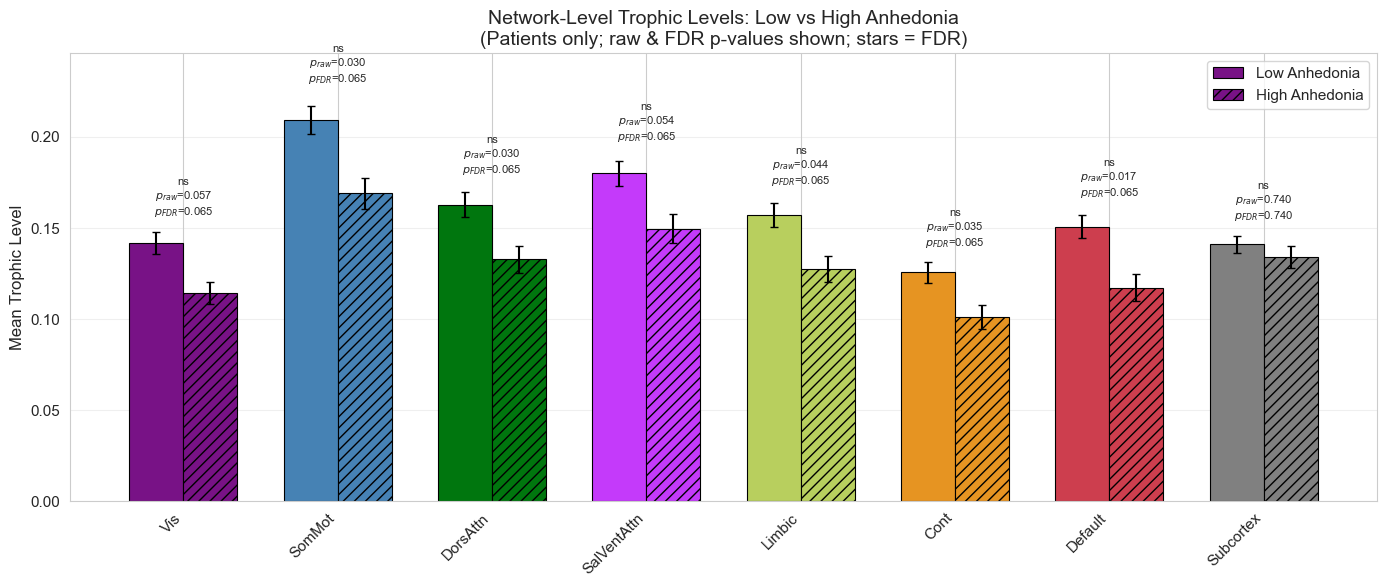

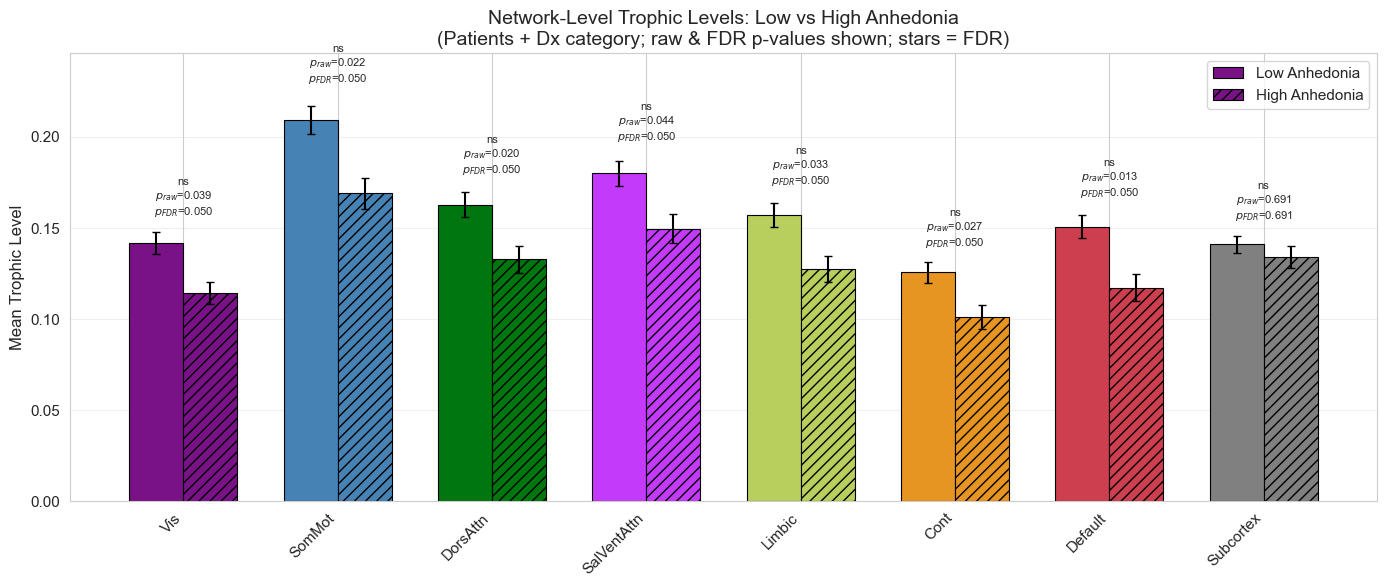

In [75]:
# %% Sensitivity: Network-Level Trophic Levels — Patients Only + Broad Dx Category

# --- Merge Dx_label into demos_lookup for patient-only analyses ---
demos_lookup_dx = demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Primary_Dx_Payman']].copy()
demos_lookup_dx['Dx_label'] = demos_lookup_dx['Primary_Dx_Payman'].replace(999, 'HC').astype(str).str.strip()
demos_lookup_dx = demos_lookup_dx.drop(columns='Primary_Dx_Payman')

dx_map = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other', 'ADHD': 'Other', 'ED': 'Other'
}
demos_lookup_dx['Dx_broad'] = demos_lookup_dx['Dx_label'].map(dx_map)

# Storage for all three models per network
raw_pvals_pat    = []   # patients only
raw_pvals_dxctrl = []   # patients + Dx_broad
coefs_pat        = []
coefs_dxctrl     = []

for net in display_order:
    idx = network_indices[net]

    df_net_full = pd.concat([
        pd.DataFrame({
            'subjectkey': ids_low,
            'net_hl': np.mean(hierarchicallevels_LOW[:, idx], axis=1),
            'anhedonia_group': 'LOW'
        }),
        pd.DataFrame({
            'subjectkey': ids_high,
            'net_hl': np.mean(hierarchicallevels_HIGH[:, idx], axis=1),
            'anhedonia_group': 'HIGH'
        }),
    ], ignore_index=True).merge(demos_lookup_dx, on='subjectkey', how='left')

    df_net_full['sex'] = df_net_full['sex'].replace('O', np.nan)
    df_net_full['anhedonia_group'] = pd.Categorical(df_net_full['anhedonia_group'], categories=['LOW', 'HIGH'])
    df_net_full['sex'] = pd.Categorical(df_net_full['sex'], categories=['F', 'M'])

    # --- Model 2: Patients only ---
    df_pat = df_net_full[df_net_full['is_patient'] == 1].copy()
    res_pat = smf.ols('net_hl ~ anhedonia_group + Age_clean + sex', data=df_pat).fit()
    raw_pvals_pat.append(res_pat.pvalues['anhedonia_group[T.HIGH]'])
    coefs_pat.append(res_pat.params['anhedonia_group[T.HIGH]'])

    # --- Model 3: Patients + broad Dx category ---
    df_pat['Dx_broad'] = pd.Categorical(df_pat['Dx_broad'], categories=['Mood', 'Anxiety_Trauma', 'Other'])
    res_dx = smf.ols(
        'net_hl ~ anhedonia_group + Age_clean + sex + Dx_broad',
        data=df_pat.dropna(subset=['Dx_broad'])
    ).fit()
    raw_pvals_dxctrl.append(res_dx.pvalues['anhedonia_group[T.HIGH]'])
    coefs_dxctrl.append(res_dx.params['anhedonia_group[T.HIGH]'])

# FDR correction for each model separately
_, pvals_fdr_pat,    _, _ = multipletests(raw_pvals_pat,    alpha=0.05, method='fdr_bh')
_, pvals_fdr_dxctrl, _, _ = multipletests(raw_pvals_dxctrl, alpha=0.05, method='fdr_bh')

def sig_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

# --- Summary table: p_raw and p_FDR side by side ---
print('=' * 140)
print('YEO 7 NETWORKS — Sensitivity Analysis Summary')
print('=' * 140)
print(f'{"Network":<14} '
      f'{"Full sample":^34} '
      f'{"Patients only":^34} '
      f'{"Patients+DxCtrl":^34}')
print(f'{"":14} '
      f'{"β":>9} {"p_raw":>9} {"p_FDR":>9} '
      f'{"β":>9} {"p_raw":>9} {"p_FDR":>9} '
      f'{"β":>9} {"p_raw":>9} {"p_FDR":>9}')
print('-' * 140)

for i, net in enumerate(display_order):
    print(f'{net:<14} '
          f'{coefs_ols[i]:>9.4f} {raw_pvals_ols[i]:>9.4f} {pvals_fdr_ols[i]:>9.4f} '
          f'{coefs_pat[i]:>9.4f} {raw_pvals_pat[i]:>9.4f} {pvals_fdr_pat[i]:>9.4f} '
          f'{coefs_dxctrl[i]:>9.4f} {raw_pvals_dxctrl[i]:>9.4f} {pvals_fdr_dxctrl[i]:>9.4f}')

print('\nNote: p_raw = uncorrected OLS p-value; p_FDR = Benjamini-Hochberg FDR-adjusted p-value.')
print('Interpret significance from p_FDR, not p_raw.')

# --- Bar charts: show BOTH p_raw and p_FDR ---
for raw_plot, fdr_plot, title_suffix, fname in [
    (raw_pvals_pat,    pvals_fdr_pat,    'Patients only',          'fig_s1-2.png'),
    (raw_pvals_dxctrl, pvals_fdr_dxctrl, 'Patients + Dx category', 'fig_s1-3.png'),
]:
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(display_order))
    width = 0.35

    for i, net in enumerate(display_order):
        color = yeo_colors[net]
        mean_low  = np.mean(net_means_LOW[net])
        mean_high = np.mean(net_means_HIGH[net])
        sem_low   = np.std(net_means_LOW[net])  / np.sqrt(len(net_means_LOW[net]))
        sem_high  = np.std(net_means_HIGH[net]) / np.sqrt(len(net_means_HIGH[net]))

        ax.bar(x[i] - width/2, mean_low, width, color=color, edgecolor='black',
               linewidth=0.8, label='Low Anhedonia' if i == 0 else '')
        ax.bar(x[i] + width/2, mean_high, width, color=color, edgecolor='black',
               linewidth=0.8, hatch='///', label='High Anhedonia' if i == 0 else '')

        ax.errorbar(x[i] - width/2, mean_low, yerr=sem_low, fmt='none', ecolor='black', capsize=3)
        ax.errorbar(x[i] + width/2, mean_high, yerr=sem_high, fmt='none', ecolor='black', capsize=3)

        # stars based on p_FDR (the conservative call)
        stars = sig_label(fdr_plot[i])
        y_top = max(mean_low + sem_low, mean_high + sem_high) * 1.05
        ax.text(
            x[i], y_top,
            f'{stars}\n$p_{{raw}}$={raw_plot[i]:.3f}\n$p_{{FDR}}$={fdr_plot[i]:.3f}',
            ha='center', va='bottom', fontsize=8
        )

    ax.set_xticks(x)
    ax.set_xticklabels(display_order, rotation=45, ha='right', fontsize=11)
    ax.set_ylabel('Mean Trophic Level', fontsize=12)
    ax.set_title(
        f'Network-Level Trophic Levels: Low vs High Anhedonia\n'
        f'({title_suffix}; raw & FDR p-values shown; stars = FDR)',
        fontsize=14
    )
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.08)
    fig.tight_layout()
    plt.savefig(fname, dpi=600, bbox_inches='tight')   # <-- add this line
    plt.show()


### OLS + FDR: Reward Circuit ROIs (Pizzagalli 2022)

Per-ROI OLS models for the 7 reward circuit regions (NAc, Caudate, Putamen, OFC, mPFC/vmPFC, ACC, dlPFC). FDR correction applied across all 7 ROI comparisons. Two bar charts are produced: one with FDR-corrected p-values, one with uncorrected p-values.

### Reward Circuit Trophic Level Analysis (Informed by Pizzagalli 2022)

**Reference:** Pizzagalli DA (2022). *Toward a Better Understanding of the Mechanisms and Pathophysiology of Anhedonia: Are We Ready for Translation?* Am J Psychiatry, 179:458-469.

### Key insights from the paper
The paper frames anhedonia around the mesocorticolimbic (reward) circuit. The core regions it describes — independent of any specific disorder — are laid out in the Neurobiology of Anhedonia section, where it traces the dopaminergic pathway from origin to cortical targets:  

**Subcortical / midbrain nodes**

- Ventral tegmental area (VTA) — origin of the dopaminergic mesocorticolimbic pathway
- Ventral striatum / nucleus accumbens (NAc) — central hub for reward responsiveness
- Dorsal striatum — caudate and putamen

**Cortical targets**

- Orbitofrontal cortex (OFC) — including central OFC areas 11 and 13
- Prefrontal cortex (PFC), with more dorsal aspects — including medial PFC (mPFC), ventromedial PFC (vmPFC), and dorsolateral PFC (dlPFC)
- Anterior cingulate cortex (ACC) subregions — perigenual ACC (pgACC), dorsal ACC (dACC), and subgenual ACC (sgACC)

**White-matter tract**

- Medial forebrain bundle — connects the VTA and nucleus accumbens; strongly tied to the experience of pleasure and motivated behavior (its supero-lateral branch projects via the anterior limb of the internal capsule from VTA to PFC)  

A couple of additional regions appear in specific findings rather than the core circuit:

- Mid-cingulate / cingulo-opercular cortex — connectivity with the ventral caudate/striatum tracked anhedonia (salience-related)
- Medial frontal pole (BA10) — over-recruited in reward tasks

The paper's "default" anhedonia circuit, summarized in Figure 2, is the VTA → ventral striatum (NAc) / dorsal striatum (caudate, putamen) → OFC, mPFC/vmPFC/dlPFC, and ACC subdivisions (pgACC, dACC, sgACC), wired together by the medial forebrain bundle. Most disorder-specific (MDD) claims in the paper are layered on top of this same underlying anatomy.  

**VTA — genuinely missing, and it's central to the paper. The whole mesocorticolimbic story originates in the VTA, but the Tian-S2 subcortical atlas stops at hippocampus, amygdala, thalamus, NAc, globus pallidus, putamen, caudate — there is no midbrain VTA (or substantia nigra) parcel. This is an unavoidable atlas limitation, but you should state it explicitly as a caveat since it's arguably the single most important node in Pizzagalli's circuit.**

**The Schaefer-200/Tian-S2 atlas does not resolve subgenual (BA25) cingulate; our ACC ROI reflects dorsal/mid-cingulate, and perigenual/ventromedial signal is captured within the mPFC/vmPFC ROI."**

In [76]:
# Reward Circuit Trophic Level Profile
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

# Define reward circuit ROIs based on Pizzagalli 2022 and map to our parcellation
reward_rois = {
    'NAc':        [8, 9, 24, 25],
    'Caudate':    [14, 15, 30, 31],
    'Putamen':    [12, 13, 28, 29],
}

# RH_Default_PFCv_1 (idx 221) included: functionally overlaps with vmPFC
mpfc_idx  = [i for i, l in enumerate(region_labels) if ('Default_PFC' in l and 'pCun' not in l)]
ofc_idx   = [i for i, l in enumerate(region_labels) if 'Limbic_OFC' in l or 'Cont_OFC' in l]
acc_idx   = [i for i, l in enumerate(region_labels) if 'SalVentAttn_Med' in l or 'Cont_Cing' in l]
dlpfc_idx = [i for i, l in enumerate(region_labels) if 'Cont_PFCl' in l]



reward_rois['OFC']        = ofc_idx
reward_rois['mPFC/vmPFC'] = mpfc_idx
reward_rois['ACC']        = acc_idx
reward_rois['dlPFC']      = dlpfc_idx

roi_order = ['NAc', 'Caudate', 'Putamen', 'OFC', 'mPFC/vmPFC', 'ACC', 'dlPFC']

for roi in roi_order:
    idx = reward_rois[roi]
    labels = [region_labels[i] for i in idx]
    print(f'{roi} ({len(idx)} regions): {labels[:4]}{"..." if len(labels) > 4 else ""}')

# --- Compute per-subject mean trophic level for each ROI ---
roi_hl_LOW = {}
roi_hl_HIGH = {}
for roi in roi_order:
    idx = reward_rois[roi]
    roi_hl_LOW[roi]  = np.mean(hierarchicallevels_LOW[:, idx], axis=1)
    roi_hl_HIGH[roi] = np.mean(hierarchicallevels_HIGH[:, idx], axis=1)

NAc (4 regions): ['NAc-shell-rh', 'NAc-core-rh', 'NAc-shell-lh', 'NAc-core-lh']
Caudate (4 regions): ['aCAU-rh', 'pCAU-rh', 'aCAU-lh', 'pCAU-lh']
Putamen (4 regions): ['aPUT-rh', 'pPUT-rh', 'aPUT-lh', 'pPUT-lh']
OFC (6 regions): ['7Networks_LH_Limbic_OFC_1', '7Networks_LH_Limbic_OFC_2', '7Networks_LH_Cont_OFC_1', '7Networks_RH_Limbic_OFC_1']...
mPFC/vmPFC (21 regions): ['7Networks_LH_Default_PFC_1', '7Networks_LH_Default_PFC_2', '7Networks_LH_Default_PFC_3', '7Networks_LH_Default_PFC_4']...
ACC (10 regions): ['7Networks_LH_SalVentAttn_Med_1', '7Networks_LH_SalVentAttn_Med_2', '7Networks_LH_SalVentAttn_Med_3', '7Networks_LH_Cont_Cing_1']...
dlPFC (12 regions): ['7Networks_LH_Cont_PFCl_1', '7Networks_LH_Cont_PFCl_2', '7Networks_LH_Cont_PFCl_3', '7Networks_LH_Cont_PFCl_4']...


In [77]:
# Build demographics lookup (reuse from confound check cell)
demos_lookup = demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']].copy()

In [78]:
# %% OLS with FDR: Reward Circuit ROI Trophic Levels ~ Anhedonia Group + Age + Sex + Patient/HC
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

raw_pvals_roi  = []
coefs_roi      = []
results_by_roi = {}

for roi in roi_order:
    idx = reward_rois[roi]

    df_roi = pd.concat([
        pd.DataFrame({'subjectkey': ids_low,  'roi_hl': np.mean(hierarchicallevels_LOW[:, idx],  axis=1), 'anhedonia_group': 'LOW'}),
        pd.DataFrame({'subjectkey': ids_high, 'roi_hl': np.mean(hierarchicallevels_HIGH[:, idx], axis=1), 'anhedonia_group': 'HIGH'}),
    ], ignore_index=True).merge(demos_lookup, on='subjectkey', how='left')

    df_roi['sex'] = df_roi['sex'].replace('O', np.nan)
    df_roi['anhedonia_group'] = pd.Categorical(df_roi['anhedonia_group'], categories=['LOW', 'HIGH'])
    df_roi['sex']             = pd.Categorical(df_roi['sex'],             categories=['F', 'M'])

    res = smf.ols('roi_hl ~ anhedonia_group + Age_clean + sex + is_patient', data=df_roi).fit()
    results_by_roi[roi] = res
    raw_pvals_roi.append(res.pvalues['anhedonia_group[T.HIGH]'])
    coefs_roi.append(res.params['anhedonia_group[T.HIGH]'])

reject_roi, pvals_fdr_roi, _, _ = multipletests(raw_pvals_roi, alpha=0.05, method='fdr_bh')

print('=' * 50)
print('REWARD CIRCUIT ROIs — OLS Results (FDR-corrected)')
print('=' * 50)
print(f'{"ROI":<14} {"beta":>9} {"p_raw":>9} {"p_FDR":>9}  sig')
print('-' * 50)
for i, roi in enumerate(roi_order):
    stars = '***' if pvals_fdr_roi[i] < 0.001 else '**' if pvals_fdr_roi[i] < 0.01 else '*' if pvals_fdr_roi[i] < 0.05 else 'ns'
    print(f'{roi:<14} {coefs_roi[i]:>9.5f} {raw_pvals_roi[i]:>9.4f} {pvals_fdr_roi[i]:>9.4f}  {stars}')


REWARD CIRCUIT ROIs — OLS Results (FDR-corrected)
ROI                 beta     p_raw     p_FDR  sig
--------------------------------------------------
NAc             -0.00892    0.2889    0.4045  ns
Caudate          0.00352    0.6645    0.6645  ns
Putamen          0.00522    0.6051    0.6645  ns
OFC             -0.02496    0.0217    0.0616  ns
mPFC/vmPFC      -0.02705    0.0188    0.0616  ns
ACC             -0.02322    0.0264    0.0616  ns
dlPFC           -0.02133    0.0465    0.0814  ns


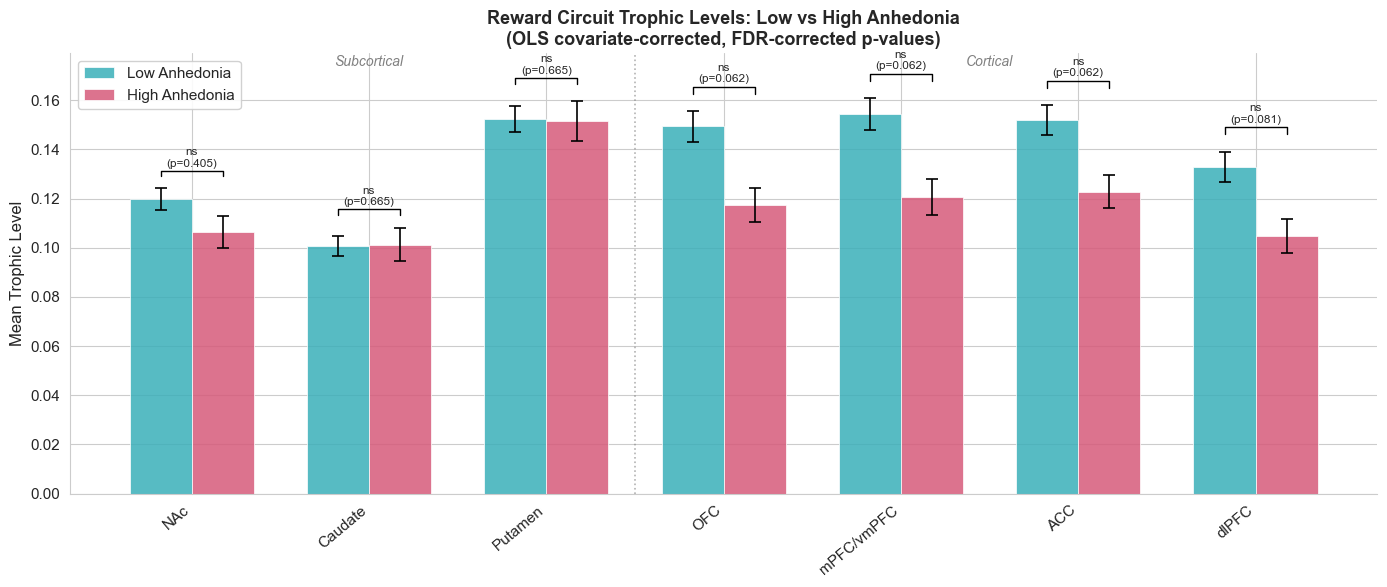

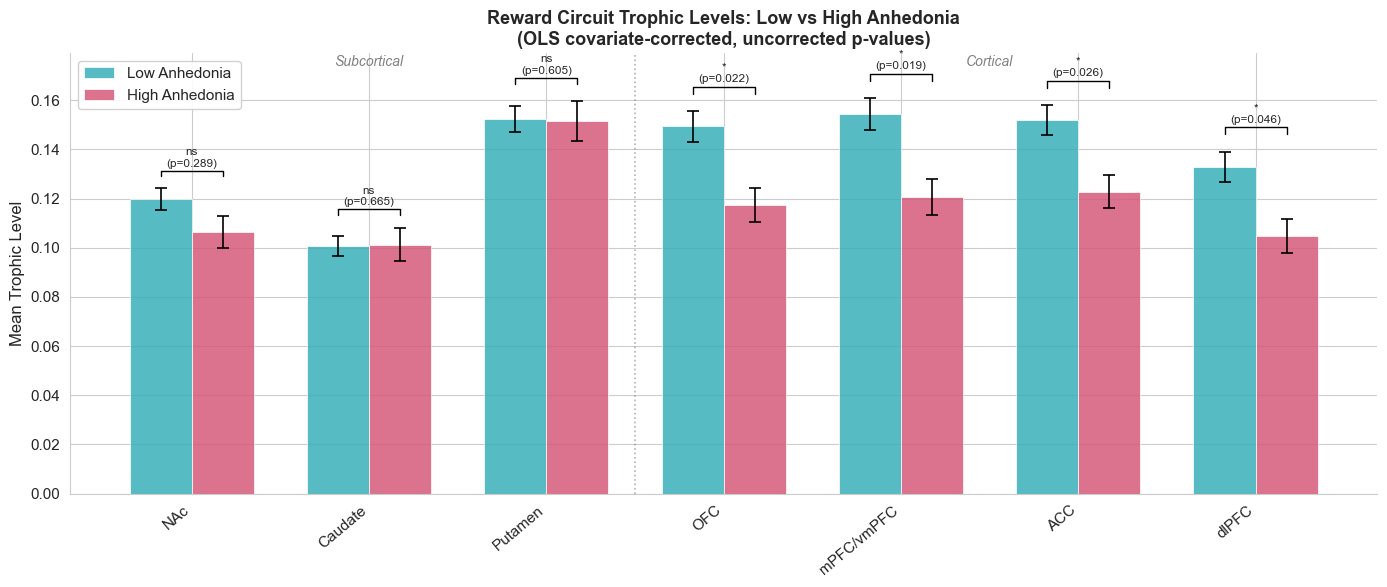

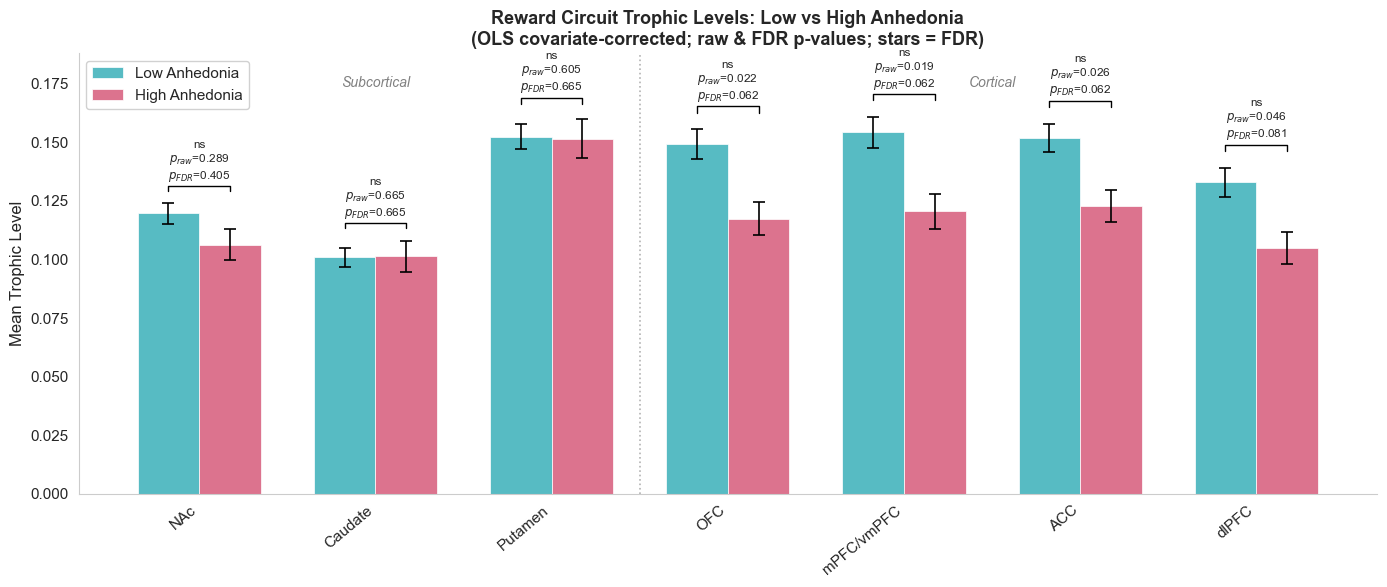

In [79]:
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

def plot_reward_rois(pvals, title_suffix, save_name=None):
    fig, ax = plt.subplots(figsize=(14, 6))
    x     = np.arange(len(roi_order))
    width = 0.35

    for i, roi in enumerate(roi_order):
        mean_low  = np.mean(roi_hl_LOW[roi])
        mean_high = np.mean(roi_hl_HIGH[roi])
        sem_low   = np.std(roi_hl_LOW[roi])  / np.sqrt(len(roi_hl_LOW[roi]))
        sem_high  = np.std(roi_hl_HIGH[roi]) / np.sqrt(len(roi_hl_HIGH[roi]))

        ax.bar(x[i] - width/2, mean_low,  width,
               color=GROUP_COLORS['Low'],  edgecolor='white', linewidth=0.6,
               alpha=0.85, label='Low Anhedonia'  if i == 0 else '')
        ax.bar(x[i] + width/2, mean_high, width,
               color=GROUP_COLORS['High'], edgecolor='white', linewidth=0.6,
               alpha=0.85, label='High Anhedonia' if i == 0 else '')

        ax.errorbar(x[i] - width/2, mean_low,  yerr=sem_low,
                    fmt='none', ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)
        ax.errorbar(x[i] + width/2, mean_high, yerr=sem_high,
                    fmt='none', ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)

        # Significance bracket between the two bars
        y_top     = max(mean_low + sem_low, mean_high + sem_high)
        y_range   = ax.get_ylim()[1] - ax.get_ylim()[0]
        bracket_y = y_top + y_range * 0.04
        tick_h    = y_range * 0.015

        ax.plot([x[i] - width/2, x[i] - width/2, x[i] + width/2, x[i] + width/2],
                [bracket_y, bracket_y + tick_h, bracket_y + tick_h, bracket_y],
                lw=1.0, color='black', clip_on=False)

        sig_label = '***' if pvals[i] < 0.001 else '**' if pvals[i] < 0.01 else '*' if pvals[i] < 0.05 else 'ns'
        ax.text(x[i], bracket_y + tick_h * 1.4,
                f'{sig_label}\n(p={pvals[i]:.3f})',
                ha='center', va='bottom', fontsize=8.5)

    ax.axvline(x=2.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
    ymax = ax.get_ylim()[1]
    ax.text(1,   ymax * 0.97, 'Subcortical', ha='center', fontsize=10, color='gray', style='italic')
    ax.text(4.5, ymax * 0.97, 'Cortical',    ha='center', fontsize=10, color='gray', style='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(roi_order, rotation=40, ha='right', fontsize=11)
    ax.set_ylabel('Mean Trophic Level', fontsize=12)
    ax.set_title(
        f'Reward Circuit Trophic Levels: Low vs High Anhedonia\n'
        f'(OLS covariate-corrected, {title_suffix})',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=11, framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)

    fig.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()


plot_reward_rois(pvals_fdr_roi, 'FDR-corrected p-values')
plot_reward_rois(raw_pvals_roi, 'uncorrected p-values')

def plot_reward_rois_combined(raw_pvals, fdr_pvals, save_name=None):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.grid(False)
    x     = np.arange(len(roi_order))
    width = 0.35

    for i, roi in enumerate(roi_order):
        mean_low  = np.mean(roi_hl_LOW[roi])
        mean_high = np.mean(roi_hl_HIGH[roi])
        sem_low   = np.std(roi_hl_LOW[roi])  / np.sqrt(len(roi_hl_LOW[roi]))
        sem_high  = np.std(roi_hl_HIGH[roi]) / np.sqrt(len(roi_hl_HIGH[roi]))

        ax.bar(x[i] - width/2, mean_low,  width,
               color=GROUP_COLORS['Low'],  edgecolor='white', linewidth=0.6,
               alpha=0.85, label='Low Anhedonia'  if i == 0 else '')
        ax.bar(x[i] + width/2, mean_high, width,
               color=GROUP_COLORS['High'], edgecolor='white', linewidth=0.6,
               alpha=0.85, label='High Anhedonia' if i == 0 else '')

        ax.errorbar(x[i] - width/2, mean_low,  yerr=sem_low,
                    fmt='none', ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)
        ax.errorbar(x[i] + width/2, mean_high, yerr=sem_high,
                    fmt='none', ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)

        # Significance bracket between the two bars
        y_top     = max(mean_low + sem_low, mean_high + sem_high)
        y_range   = ax.get_ylim()[1] - ax.get_ylim()[0]
        bracket_y = y_top + y_range * 0.04
        tick_h    = y_range * 0.015

        ax.plot([x[i] - width/2, x[i] - width/2, x[i] + width/2, x[i] + width/2],
                [bracket_y, bracket_y + tick_h, bracket_y + tick_h, bracket_y],
                lw=1.0, color='black', clip_on=False)

        # stars based on FDR-corrected p (the conservative call)
        sig_label = '***' if fdr_pvals[i] < 0.001 else '**' if fdr_pvals[i] < 0.01 else '*' if fdr_pvals[i] < 0.05 else 'ns'
        ax.text(x[i], bracket_y + tick_h * 1.4,
                f'{sig_label}\n$p_{{raw}}$={raw_pvals[i]:.3f}\n$p_{{FDR}}$={fdr_pvals[i]:.3f}',
                ha='center', va='bottom', fontsize=8.5)

    ax.axvline(x=2.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
    ymax = ax.get_ylim()[1]
    ax.text(1,   ymax * 0.97, 'Subcortical', ha='center', fontsize=10, color='gray', style='italic')
    ax.text(4.5, ymax * 0.97, 'Cortical',    ha='center', fontsize=10, color='gray', style='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(roi_order, rotation=40, ha='right', fontsize=11)
    ax.set_ylabel('Mean Trophic Level', fontsize=12)
    ax.set_title(
        'Reward Circuit Trophic Levels: Low vs High Anhedonia\n'
        '(OLS covariate-corrected; raw & FDR p-values; stars = FDR)',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=11, framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    # extra headroom for the taller 3-line annotation
    ax.set_ylim(top=ax.get_ylim()[1] * 1.05)

    fig.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=600, bbox_inches='tight')
    plt.show()


plot_reward_rois_combined(raw_pvals_roi, pvals_fdr_roi, save_name='reward_rois_trophic_levels.png')



In [80]:
# --- Merge Dx_label into demos_lookup for patient-only analyses ---
demos_lookup_dx = demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Primary_Dx_Payman']].copy()
demos_lookup_dx['Dx_label'] = demos_lookup_dx['Primary_Dx_Payman'].replace(999, 'HC').astype(str).str.strip()
demos_lookup_dx = demos_lookup_dx.drop(columns='Primary_Dx_Payman')

dx_map = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other', 'ADHD': 'Other', 'ED': 'Other'
}
demos_lookup_dx['Dx_broad'] = demos_lookup_dx['Dx_label'].map(dx_map)

In [81]:
# %% Sensitivity: Reward Circuit ROIs — Patients Only + Broad Dx Category
raw_pvals_roi_pat    = []
raw_pvals_roi_dxctrl = []
coefs_roi_pat        = []
coefs_roi_dxctrl     = []

for roi in roi_order:
    idx = reward_rois[roi]

    df_roi_full = pd.concat([
        pd.DataFrame({'subjectkey': ids_low,  'roi_hl': np.mean(hierarchicallevels_LOW[:, idx],  axis=1), 'anhedonia_group': 'LOW'}),
        pd.DataFrame({'subjectkey': ids_high, 'roi_hl': np.mean(hierarchicallevels_HIGH[:, idx], axis=1), 'anhedonia_group': 'HIGH'}),
    ], ignore_index=True).merge(demos_lookup_dx, on='subjectkey', how='left')

    df_roi_full['sex'] = df_roi_full['sex'].replace('O', np.nan)
    df_roi_full['anhedonia_group'] = pd.Categorical(df_roi_full['anhedonia_group'], categories=['LOW', 'HIGH'])
    df_roi_full['sex'] = pd.Categorical(df_roi_full['sex'], categories=['F', 'M'])

    # Patients only
    df_pat = df_roi_full[df_roi_full['is_patient'] == 1].copy()
    res_pat = smf.ols('roi_hl ~ anhedonia_group + Age_clean + sex', data=df_pat).fit()
    raw_pvals_roi_pat.append(res_pat.pvalues['anhedonia_group[T.HIGH]'])
    coefs_roi_pat.append(res_pat.params['anhedonia_group[T.HIGH]'])

    # Patients + Dx_broad
    df_dxctrl = df_pat[df_pat['Dx_broad'].notna()].copy()
    df_dxctrl['Dx_broad'] = pd.Categorical(df_dxctrl['Dx_broad'])
    res_dxctrl = smf.ols('roi_hl ~ anhedonia_group + Age_clean + sex + Dx_broad', data=df_dxctrl).fit()
    raw_pvals_roi_dxctrl.append(res_dxctrl.pvalues['anhedonia_group[T.HIGH]'])
    coefs_roi_dxctrl.append(res_dxctrl.params['anhedonia_group[T.HIGH]'])

_, pvals_fdr_roi_pat,    _, _ = multipletests(raw_pvals_roi_pat,    alpha=0.05, method='fdr_bh')
_, pvals_fdr_roi_dxctrl, _, _ = multipletests(raw_pvals_roi_dxctrl, alpha=0.05, method='fdr_bh')

print('=' * 60)
print('REWARD CIRCUIT ROIs — Patients Only (FDR-corrected)')
print('=' * 60)
print(f'{"ROI":<14} {"beta":>9} {"p_raw":>9} {"p_FDR":>9}  sig')
print('-' * 60)
for i, roi in enumerate(roi_order):
    stars = '***' if pvals_fdr_roi_pat[i] < 0.001 else '**' if pvals_fdr_roi_pat[i] < 0.01 else '*' if pvals_fdr_roi_pat[i] < 0.05 else 'ns'
    print(f'{roi:<14} {coefs_roi_pat[i]:>9.5f} {raw_pvals_roi_pat[i]:>9.4f} {pvals_fdr_roi_pat[i]:>9.4f}  {stars}')

print()
print('=' * 60)
print('REWARD CIRCUIT ROIs — Patients + Dx_broad (FDR-corrected)')
print('=' * 60)
print(f'{"ROI":<14} {"beta":>9} {"p_raw":>9} {"p_FDR":>9}  sig')
print('-' * 60)
for i, roi in enumerate(roi_order):
    stars = '***' if pvals_fdr_roi_dxctrl[i] < 0.001 else '**' if pvals_fdr_roi_dxctrl[i] < 0.01 else '*' if pvals_fdr_roi_dxctrl[i] < 0.05 else 'ns'
    print(f'{roi:<14} {coefs_roi_dxctrl[i]:>9.5f} {raw_pvals_roi_dxctrl[i]:>9.4f} {pvals_fdr_roi_dxctrl[i]:>9.4f}  {stars}')


REWARD CIRCUIT ROIs — Patients Only (FDR-corrected)
ROI                 beta     p_raw     p_FDR  sig
------------------------------------------------------------
NAc             -0.01273    0.2105    0.2947  ns
Caudate          0.00172    0.8559    0.8559  ns
Putamen          0.00317    0.7888    0.8559  ns
OFC             -0.02868    0.0231    0.0570  ns
mPFC/vmPFC      -0.03284    0.0141    0.0570  ns
ACC             -0.02825    0.0244    0.0570  ns
dlPFC           -0.02603    0.0338    0.0592  ns

REWARD CIRCUIT ROIs — Patients + Dx_broad (FDR-corrected)
ROI                 beta     p_raw     p_FDR  sig
------------------------------------------------------------
NAc             -0.01350    0.1874    0.2623  ns
Caudate          0.00125    0.8962    0.8962  ns
Putamen          0.00308    0.7966    0.8962  ns
OFC             -0.03025    0.0166    0.0446  *
mPFC/vmPFC      -0.03440    0.0102    0.0446  *
ACC             -0.02948    0.0192    0.0446  *
dlPFC           -0.02744    0.025

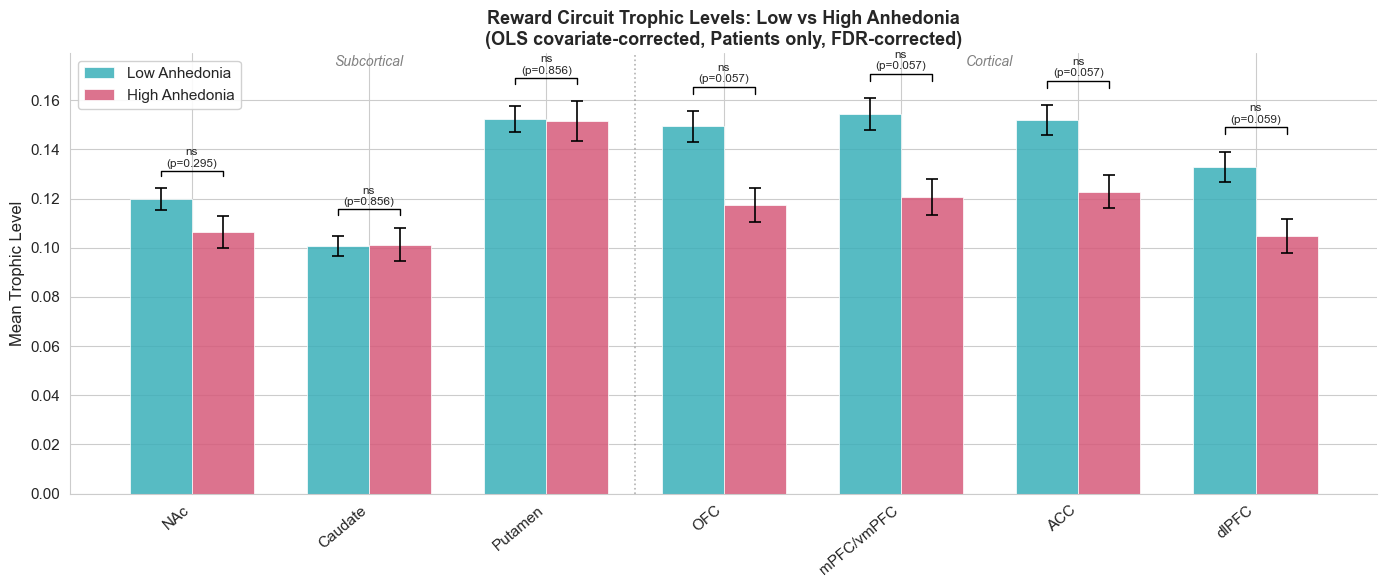

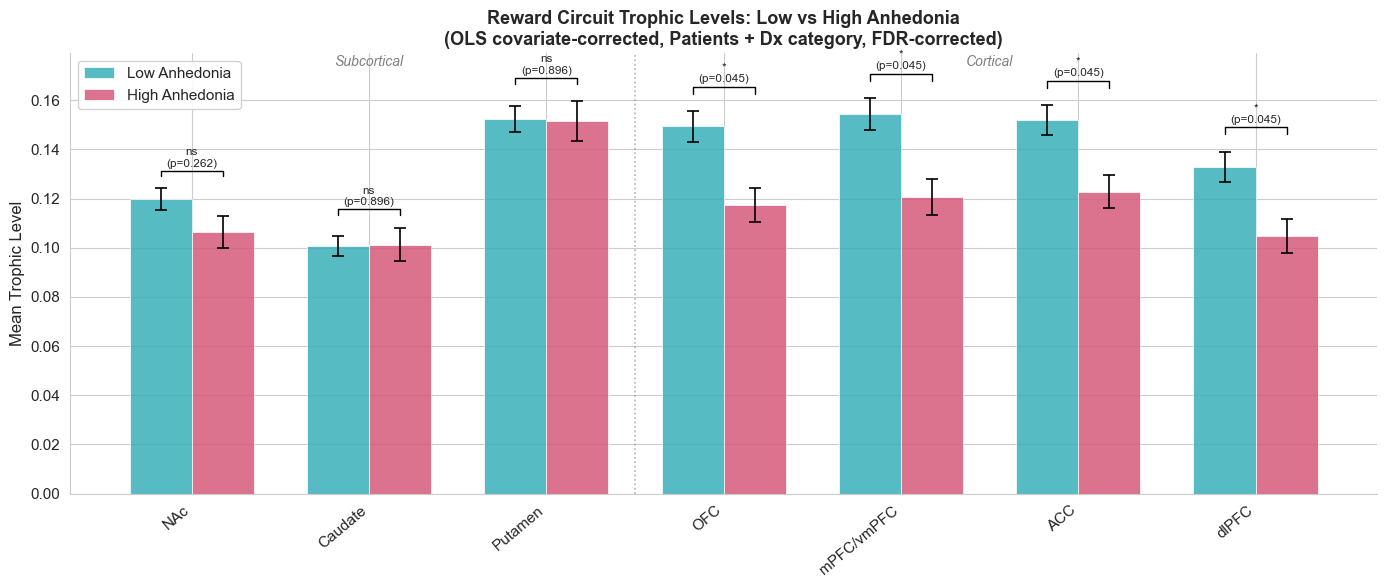

In [82]:
def plot_reward_rois(pvals, title_suffix, save_name=None):
    sns.set_style('whitegrid')
    plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

    fig, ax = plt.subplots(figsize=(14, 6))
    x     = np.arange(len(roi_order))
    width = 0.35

    for i, roi in enumerate(roi_order):
        mean_low  = np.mean(roi_hl_LOW[roi])
        mean_high = np.mean(roi_hl_HIGH[roi])
        sem_low   = np.std(roi_hl_LOW[roi])  / np.sqrt(len(roi_hl_LOW[roi]))
        sem_high  = np.std(roi_hl_HIGH[roi]) / np.sqrt(len(roi_hl_HIGH[roi]))

        ax.bar(x[i] - width/2, mean_low,  width,
               color=GROUP_COLORS['Low'],  edgecolor='white', linewidth=0.6,
               alpha=0.85, label='Low Anhedonia'  if i == 0 else '')
        ax.bar(x[i] + width/2, mean_high, width,
               color=GROUP_COLORS['High'], edgecolor='white', linewidth=0.6,
               alpha=0.85, label='High Anhedonia' if i == 0 else '')

        ax.errorbar(x[i] - width/2, mean_low,  yerr=sem_low,
                    fmt='none', ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)
        ax.errorbar(x[i] + width/2, mean_high, yerr=sem_high,
                    fmt='none', ecolor='black', capsize=4, capthick=1.2, elinewidth=1.2)

        # Significance bracket between the two bars
        y_top    = max(mean_low + sem_low, mean_high + sem_high)
        y_range  = ax.get_ylim()[1] - ax.get_ylim()[0]
        bracket_y = y_top + y_range * 0.04
        tick_h    = y_range * 0.015

        ax.plot([x[i] - width/2, x[i] - width/2, x[i] + width/2, x[i] + width/2],
                [bracket_y, bracket_y + tick_h, bracket_y + tick_h, bracket_y],
                lw=1.0, color='black', clip_on=False)

        if pvals[i] < 0.001:
            sig_label = '***'
        elif pvals[i] < 0.01:
            sig_label = '**'
        elif pvals[i] < 0.05:
            sig_label = '*'
        else:
            sig_label = 'ns'

        ax.text(x[i], bracket_y + tick_h * 1.4,
                f'{sig_label}\n(p={pvals[i]:.3f})',
                ha='center', va='bottom', fontsize=8.5)

    # Subcortical / Cortical divider
    ax.axvline(x=2.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
    ymax = ax.get_ylim()[1]
    ax.text(1,   ymax * 0.97, 'Subcortical', ha='center', fontsize=10,
            color='gray', style='italic')
    ax.text(4.5, ymax * 0.97, 'Cortical',    ha='center', fontsize=10,
            color='gray', style='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(roi_order, rotation=40, ha='right', fontsize=11)
    ax.set_ylabel('Mean Trophic Level', fontsize=12)
    ax.set_title(
        f'Reward Circuit Trophic Levels: Low vs High Anhedonia\n'
        f'(OLS covariate-corrected, {title_suffix})',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=11, framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)

    fig.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()


# --- Call as before ---
plot_reward_rois(pvals_fdr_roi_pat,    'Patients only, FDR-corrected',
                 save_name='reward_rois_patients.png')
plot_reward_rois(pvals_fdr_roi_dxctrl, 'Patients + Dx category, FDR-corrected',
                 save_name='reward_rois_patients_dxctrl.png')


### OLS: Frontostriatal Flow Asymmetry (PFC → Striatum)

Covariate-corrected test of the reward-circuit-specific directed flow asymmetry (PFC→Striatum − Striatum→PFC). Tests whether altered frontostriatal top-down control survives after correcting for age, sex, and diagnosis.

In [83]:
# Frontostriatal Hierarchical Relationship
# PFC = dlPFC + mPFC/vmPFC + OFC + ACC (cortical reward regions)
# Striatum = NAc + Caudate + Putamen (subcortical reward regions)

pfc_idx = reward_rois['dlPFC'] + reward_rois['mPFC/vmPFC'] + reward_rois['OFC'] + reward_rois['ACC']
striatum_idx = reward_rois['NAc'] + reward_rois['Caudate'] + reward_rois['Putamen']

print(f'PFC regions: {len(pfc_idx)} parcels')
print(f'Striatum regions: {len(striatum_idx)} parcels')

# --- Directed Flow Asymmetry (PFC→Striatum vs Striatum→PFC) ---
flow_pfc2str_LOW = np.zeros(NSUB_LOW)
flow_str2pfc_LOW = np.zeros(NSUB_LOW)
flow_pfc2str_HIGH = np.zeros(NSUB_HIGH)
flow_str2pfc_HIGH = np.zeros(NSUB_HIGH)

for s in range(NSUB_LOW):
    C = Ceff_LOW[s]
    flow_pfc2str_LOW[s] = np.sum(C[np.ix_(striatum_idx, pfc_idx)])
    flow_str2pfc_LOW[s] = np.sum(C[np.ix_(pfc_idx, striatum_idx)])

for s in range(NSUB_HIGH):
    C = Ceff_HIGH[s]
    flow_pfc2str_HIGH[s] = np.sum(C[np.ix_(striatum_idx, pfc_idx)])
    flow_str2pfc_HIGH[s] = np.sum(C[np.ix_(pfc_idx, striatum_idx)])

# Positive = PFC drives striatum (top-down)
fs_asym_LOW = flow_pfc2str_LOW - flow_str2pfc_LOW
fs_asym_HIGH = flow_pfc2str_HIGH - flow_str2pfc_HIGH

PFC regions: 49 parcels
Striatum regions: 12 parcels


**We copmute the normalized index and we also perform regression on each direction sepearately below, as we did for cortex to subcortex in some of the cells above in this notebook. There are details on the rationale in those cells.**

In [84]:
# --- Normalized directed-flow asymmetry index:  (A − B) / (A + B) ---
# A = flow_pfc2str (top-down),  B = flow_str2pfc (bottom-up)
# Bounded in [-1, 1]; positive = top-down dominant. Controls for overall coupling magnitude.

denom_LOW  = flow_pfc2str_LOW  + flow_str2pfc_LOW
denom_HIGH = flow_pfc2str_HIGH + flow_str2pfc_HIGH

# Guard: the bounded interpretation only holds if both arms are >= 0 and A+B > 0
if np.any(denom_LOW <= 0) or np.any(denom_HIGH <= 0):
    print('WARNING: non-positive (A+B) for some subjects — normalized index unstable/undefined there.')
if np.any(flow_pfc2str_LOW < 0) or np.any(flow_str2pfc_LOW < 0) or \
   np.any(flow_pfc2str_HIGH < 0) or np.any(flow_str2pfc_HIGH < 0):
    print('WARNING: negative directed flow present — [-1, 1] bound no longer guaranteed.')

fs_asym_norm_LOW  = (flow_pfc2str_LOW  - flow_str2pfc_LOW)  / denom_LOW
fs_asym_norm_HIGH = (flow_pfc2str_HIGH - flow_str2pfc_HIGH) / denom_HIGH

print(f'Normalized FS asymmetry  LOW : mean={fs_asym_norm_LOW.mean():+.4f}  (n={fs_asym_norm_LOW.size})')
print(f'Normalized FS asymmetry  HIGH: mean={fs_asym_norm_HIGH.mean():+.4f}  (n={fs_asym_norm_HIGH.size})')


Normalized FS asymmetry  LOW : mean=-0.0181  (n=139)
Normalized FS asymmetry  HIGH: mean=-0.0005  (n=71)


In [85]:
      # %% OLS: Frontostriatal Flow Asymmetry ~ Anhedonia Group + Age + Sex + Patient/HC
df_ols_fs = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'fs_asym': fs_asym_norm_LOW,  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'fs_asym': fs_asym_norm_HIGH, 'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_ols_fs['sex'] = df_ols_fs['sex'].replace('O', np.nan)
df_ols_fs['anhedonia_group'] = pd.Categorical(df_ols_fs['anhedonia_group'], categories=['LOW', 'HIGH'])
df_ols_fs['sex']             = pd.Categorical(df_ols_fs['sex'],             categories=['F', 'M'])

result_fs = smf.ols('fs_asym ~ anhedonia_group + Age_clean + sex + is_patient', data=df_ols_fs).fit()

coef  = result_fs.params['anhedonia_group[T.HIGH]']
pval  = result_fs.pvalues['anhedonia_group[T.HIGH]']
ci_lo, ci_hi = result_fs.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('FRONTOSTRIATAL FLOW ASYMMETRY (PFC→Str − Str→PFC) — OLS Result')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef:.5f}')
print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
    print(f'    {term:<22}  β={result_fs.params[term]:.5f},  p={result_fs.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_fs.rsquared:.3f},  adj-R²={result_fs.rsquared_adj:.3f},  N={int(result_fs.nobs)}')


FRONTOSTRIATAL FLOW ASYMMETRY (PFC→Str − Str→PFC) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = 0.01609
    95% CI = [0.00911, 0.02306]
    p  = 0.0000  *** significant after covariate correction

  Covariates:
    Age_clean               β=0.00021,  p=0.0910
    sex[T.M]                β=-0.00234,  p=0.4739
    is_patient              β=0.00106,  p=0.7536

  Model fit:  R²=0.133,  adj-R²=0.116,  N=206


/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


NameError: name 'p_td_fs' is not defined

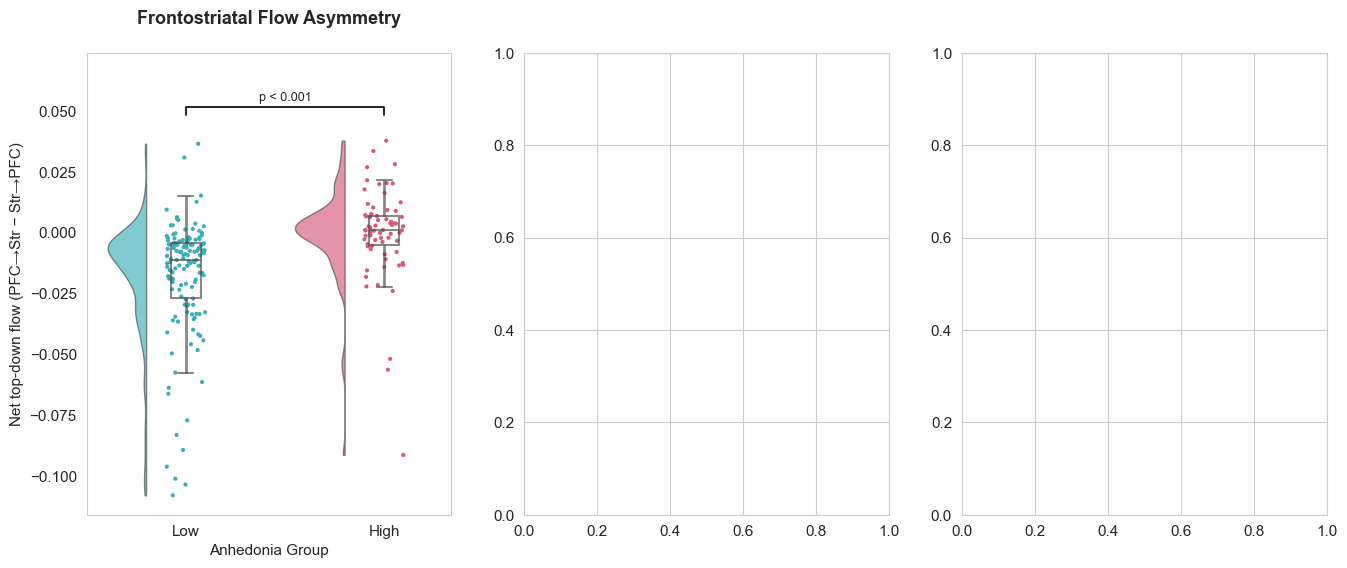

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import ptitprince as pt

# ── Long-form data ────────────────────────────────────────────────────────────
# Panel A: net frontostriatal asymmetry (normalized difference)
fs_df = pd.DataFrame({
    'Value': list(fs_asym_norm_LOW) + list(fs_asym_norm_HIGH),
    'Group': ['Low'] * len(fs_asym_norm_LOW) + ['High'] * len(fs_asym_norm_HIGH),
})

# Panel B: PFC -> striatum arm (top-down)
pfc2str_df = pd.DataFrame({
    'Value': list(flow_pfc2str_LOW) + list(flow_pfc2str_HIGH),
    'Group': ['Low'] * len(flow_pfc2str_LOW) + ['High'] * len(flow_pfc2str_HIGH),
})

# Panel C: striatum -> PFC arm (bottom-up)
str2pfc_df = pd.DataFrame({
    'Value': list(flow_str2pfc_LOW) + list(flow_str2pfc_HIGH),
    'Group': ['Low'] * len(flow_str2pfc_LOW) + ['High'] * len(flow_str2pfc_HIGH),
})

group_pal = [GROUP_COLORS[g] for g in ['Low', 'High']]

def raincloud_panel(ax, df, ylabel, title, pval):
    pt.RainCloud(
        data=df, x='Group', y='Value', order=['Low', 'High'],
        palette=group_pal, ax=ax, orient='v',
        width_viol=0.5, width_box=0.15, point_size=3, alpha=0.65,
        box_showfliers=False, box_linewidth=1.5,
    )
    ax.grid(False)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Anhedonia Group', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    add_pvalue_annotation(ax, pval)

# ── Figure: three panels ──────────────────────────────────────────────────────
pval_fs = result_fs.pvalues['anhedonia_group[T.HIGH]']   # net-asymmetry p (robust, not the shared `pval`)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

raincloud_panel(axes[0], fs_df,
                'Net top-down flow (PFC→Str − Str→PFC)',
                'Frontostriatal Flow Asymmetry\n', pval_fs)

raincloud_panel(axes[1], pfc2str_df,
                'PFC→Striatum flow  F(PFC→Str)',
                'Top-Down Arm\n', p_td_fs)

raincloud_panel(axes[2], str2pfc_df,
                'Striatum→PFC flow  F(Str→PFC)',
                'Bottom-Up Arm\n', p_bu_fs)

plt.tight_layout()
plt.savefig('violin_frontostriatal_asymmetry_3panel.png', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
# %% Sensitivity: Frontostriatal Flow Asymmetry — Patients Only + Broad Dx Category

# Reuse the full-sample model from the earlier frontostriatal OLS cell
coef_fs_full = result_fs.params['anhedonia_group[T.HIGH]']
pval_fs_full = result_fs.pvalues['anhedonia_group[T.HIGH]']

# Broad diagnostic-category mapping
dx_map = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other'
}

# --- Model 2: Patients only ---
df_patients_fs = df_ols_fs[df_ols_fs['is_patient'] == 1].copy()
n_low_pat  = (df_patients_fs['anhedonia_group'] == 'LOW').sum()
n_high_pat = (df_patients_fs['anhedonia_group'] == 'HIGH').sum()

result_fs_pat = smf.ols('fs_asym ~ anhedonia_group + Age_clean + sex', data=df_patients_fs).fit()

coef_fs_pat = result_fs_pat.params['anhedonia_group[T.HIGH]']
pval_fs_pat = result_fs_pat.pvalues['anhedonia_group[T.HIGH]']
ci_lo_fp, ci_hi_fp = result_fs_pat.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Model 3: Patients only + broad diagnostic category ---
df_patients_fs_dx = df_patients_fs.merge(
    demos[['subjectkey', 'Primary_Dx_Payman']],
    on='subjectkey', how='left'
)

df_patients_fs_dx['Dx_label'] = (
    df_patients_fs_dx['Primary_Dx_Payman']
    .replace(999, 'HC')
    .astype(str)
    .str.strip()
)

df_patients_fs_dx['Dx_broad'] = pd.Categorical(
    df_patients_fs_dx['Dx_label'].map(dx_map),
    categories=['Mood', 'Anxiety_Trauma', 'Other']
)

print('Dx_broad counts by group:')
print(pd.crosstab(df_patients_fs_dx['anhedonia_group'], df_patients_fs_dx['Dx_broad']))
print()

result_fs_dx = smf.ols(
    'fs_asym ~ anhedonia_group + Age_clean + sex + Dx_broad',
    data=df_patients_fs_dx.dropna(subset=['Dx_broad'])
).fit()

coef_fs_dx = result_fs_dx.params['anhedonia_group[T.HIGH]']
pval_fs_dx = result_fs_dx.pvalues['anhedonia_group[T.HIGH]']
ci_lo_fd, ci_hi_fd = result_fs_dx.conf_int().loc['anhedonia_group[T.HIGH]']

# --- Print results ---
print('==============================')
print('FRONTOSTRIATAL FLOW ASYMMETRY — Patients Only')
print(f'  N = {int(result_fs_pat.nobs)}  (LOW={n_low_pat}, HIGH={n_high_pat})')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_fs_pat:.5f}')
print(f'    95% CI = [{ci_lo_fp:.5f}, {ci_hi_fp:.5f}]')
print(f'    p  = {pval_fs_pat:.4f}  {"*** significant" if pval_fs_pat < 0.05 else "ns"}')
print('\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]']:
    print(f'    {term:<22}  β={result_fs_pat.params[term]:.5f},  p={result_fs_pat.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_fs_pat.rsquared:.3f},  adj-R²={result_fs_pat.rsquared_adj:.3f}')

print('\n==============================')
print('FRONTOSTRIATAL FLOW ASYMMETRY — Patients Only + Broad Dx Category')
print(f'  N = {int(result_fs_dx.nobs)}')
print('==============================')
print('  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef_fs_dx:.5f}')
print(f'    95% CI = [{ci_lo_fd:.5f}, {ci_hi_fd:.5f}]')
print(f'    p  = {pval_fs_dx:.4f}  {"*** significant" if pval_fs_dx < 0.05 else "ns"}')
print('\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'Dx_broad[T.Anxiety_Trauma]', 'Dx_broad[T.Other]']:
    print(f'    {term:<35}  β={result_fs_dx.params[term]:.5f},  p={result_fs_dx.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_fs_dx.rsquared:.3f},  adj-R²={result_fs_dx.rsquared_adj:.3f}')

print('\n  ── Three-way comparison ──')
print(f'  {"Model":<40} {"β":>9} {"p":>9}')
print(f'  {"Full sample (+ is_patient)":<40} {coef_fs_full:>9.5f} {pval_fs_full:>9.4f}')
print(f'  {"Patients only":<40} {coef_fs_pat:>9.5f} {pval_fs_pat:>9.4f}')
print(f'  {"Patients + broad Dx category":<40} {coef_fs_dx:>9.5f} {pval_fs_dx:>9.4f}')


Dx_broad counts by group:
Dx_broad         Mood  Anxiety_Trauma  Other
anhedonia_group                             
LOW                31              25     15
HIGH               31              18      8

FRONTOSTRIATAL FLOW ASYMMETRY — Patients Only
  N = 125  (LOW=71, HIGH=57)
  Anhedonia group (HIGH vs LOW):
    β  = 0.01557
    95% CI = [0.00863, 0.02252]
    p  = 0.0000  *** significant

  Covariates:
    Age_clean               β=0.00021,  p=0.1110
    sex[T.M]                β=-0.00799,  p=0.0255

  Model fit:  R²=0.229,  adj-R²=0.210

FRONTOSTRIATAL FLOW ASYMMETRY — Patients Only + Broad Dx Category
  N = 125
  Anhedonia group (HIGH vs LOW):
    β  = 0.01610
    95% CI = [0.00929, 0.02292]
    p  = 0.0000  *** significant

  Covariates:
    Age_clean                            β=0.00019,  p=0.1452
    sex[T.M]                             β=-0.00918,  p=0.0095
    Dx_broad[T.Anxiety_Trauma]           β=-0.00296,  p=0.4264
    Dx_broad[T.Other]                    β=0.01000,  p=

In [ ]:
      # %% OLS: Frontostriatal Flow Asymmetry ~ Anhedonia Group + Age + Sex + Patient/HC
df_ols_fs = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'fs_asym': fs_asym_LOW,  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'fs_asym': fs_asym_HIGH, 'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_ols_fs['sex'] = df_ols_fs['sex'].replace('O', np.nan)
df_ols_fs['anhedonia_group'] = pd.Categorical(df_ols_fs['anhedonia_group'], categories=['LOW', 'HIGH'])
df_ols_fs['sex']             = pd.Categorical(df_ols_fs['sex'],             categories=['F', 'M'])

result_fs = smf.ols('fs_asym ~ anhedonia_group + Age_clean + sex + is_patient', data=df_ols_fs).fit()

coef  = result_fs.params['anhedonia_group[T.HIGH]']
pval  = result_fs.pvalues['anhedonia_group[T.HIGH]']
ci_lo, ci_hi = result_fs.conf_int().loc['anhedonia_group[T.HIGH]']

print('==============================')
print('FRONTOSTRIATAL FLOW ASYMMETRY (PFC→Str − Str→PFC) — OLS Result')
print('==============================')
print(f'  Anhedonia group (HIGH vs LOW):')
print(f'    β  = {coef:.5f}')
print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
print(f'\n  Covariates:')
for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
    print(f'    {term:<22}  β={result_fs.params[term]:.5f},  p={result_fs.pvalues[term]:.4f}')
print(f'\n  Model fit:  R²={result_fs.rsquared:.3f},  adj-R²={result_fs.rsquared_adj:.3f},  N={int(result_fs.nobs)}')


FRONTOSTRIATAL FLOW ASYMMETRY (PFC→Str − Str→PFC) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = 0.12223
    95% CI = [0.06552, 0.17895]
    p  = 0.0000  *** significant after covariate correction

  Covariates:
    Age_clean               β=0.00112,  p=0.2588
    sex[T.M]                β=-0.01496,  p=0.5733
    is_patient              β=0.00890,  p=0.7452

  Model fit:  R²=0.111,  adj-R²=0.093,  N=206


In [89]:
# %% OLS: Frontostriatal directed-flow arms (conditional decomposition) ~ Anhedonia Group + Age + Sex + Patient/HC
# Reuses run_arm_ols() defined earlier.
# Arm 1: flow_pfc2str = F(PFC→Striatum)  -> top-down arm
# Arm 2: flow_str2pfc = F(Striatum→PFC)  -> bottom-up arm

# --- Arm 1: top-down  F(PFC→Striatum) ---
result_pfc2str, b_td_fs, p_td_fs = run_arm_ols(
    flow_pfc2str_LOW, flow_pfc2str_HIGH, 'TOP-DOWN ARM  F(PFC→Str)')

# --- Arm 2: bottom-up  F(Striatum→PFC) ---
result_str2pfc, b_bu_fs, p_bu_fs = run_arm_ols(
    flow_str2pfc_LOW, flow_str2pfc_HIGH, 'BOTTOM-UP ARM  F(Str→PFC)')

# --- Direction comparison (the "same vs opposite" read) ---
print('==============================')
print('FRONTOSTRIATAL ARM DIRECTION SUMMARY (HIGH vs LOW)')
print('==============================')
print(f'  Top-down  F(PFC→Str):  β={b_td_fs:+.5f}  p={p_td_fs:.4f}')
print(f'  Bottom-up F(Str→PFC):  β={b_bu_fs:+.5f}  p={p_bu_fs:.4f}')
moved = 'OPPOSITE directions  → congruent, reinforces the asymmetry' if (b_td_fs * b_bu_fs < 0) \
        else 'the SAME direction   → asymmetry is a differential (one arm moved more)'
print(f'  Arms moved in {moved}')


TOP-DOWN ARM  F(PFC→Str) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.29312   (HIGH < LOW (arm DOWN))
    95% CI = [-0.61876, 0.03251]
    p  = 0.0774  ns after covariate correction

  Covariates:
    Age_clean               β=0.00392,  p=0.4925
    sex[T.M]                β=-0.11081,  p=0.4676
    is_patient              β=-0.19255,  p=0.2218

  Model fit:  R²=0.031,  adj-R²=0.012,  N=206

BOTTOM-UP ARM  F(Str→PFC) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.41536   (HIGH < LOW (arm DOWN))
    95% CI = [-0.74547, -0.08524]
    p  = 0.0139  *** significant after covariate correction

  Covariates:
    Age_clean               β=0.00279,  p=0.6291
    sex[T.M]                β=-0.09585,  p=0.5353
    is_patient              β=-0.20145,  p=0.2074

  Model fit:  R²=0.048,  adj-R²=0.029,  N=206

FRONTOSTRIATAL ARM DIRECTION SUMMARY (HIGH vs LOW)
  Top-down  F(PFC→Str):  β=-0.29312  p=0.0774
  Bottom-up F(Str→PFC):  β=-0.41536  p=0.0139
  Arms moved in the SAME dir

### PFC vs Striatum Hierarchical Level Analysis

In [90]:
# %% PFC vs Striatum Hierarchical Level Analysis
# Using full 232-region hierarchical levels (same as Approach 1 for cortex/subcortex)

# --- Mean HL per subject for each compartment ---
hl_pfc_mean_LOW       = np.mean(hierarchicallevels_LOW[:, pfc_idx], axis=1)
hl_pfc_mean_HIGH      = np.mean(hierarchicallevels_HIGH[:, pfc_idx], axis=1)

hl_striatum_mean_LOW  = np.mean(hierarchicallevels_LOW[:, striatum_idx], axis=1)
hl_striatum_mean_HIGH = np.mean(hierarchicallevels_HIGH[:, striatum_idx], axis=1)

# Positive gap = PFC sits higher in hierarchy than Striatum
hl_fs_gap_LOW  = hl_pfc_mean_LOW  - hl_striatum_mean_LOW
hl_fs_gap_HIGH = hl_pfc_mean_HIGH - hl_striatum_mean_HIGH

In [91]:
# %% OLS: PFC & Striatum Hierarchical Levels ~ Anhedonia Group + Age + Sex + Patient/HC

df_base = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,
                  'hl_pfc':      hl_pfc_mean_LOW,
                  'hl_striatum': hl_striatum_mean_LOW,
                  'hl_fs_gap':   hl_fs_gap_LOW,
                  'anhedonia_group': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high,
                  'hl_pfc':      hl_pfc_mean_HIGH,
                  'hl_striatum': hl_striatum_mean_HIGH,
                  'hl_fs_gap':   hl_fs_gap_HIGH,
                  'anhedonia_group': 'HIGH'}),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']],
    on='subjectkey', how='left'
)

df_base['sex']             = df_base['sex'].replace('O', np.nan)
df_base['anhedonia_group'] = pd.Categorical(df_base['anhedonia_group'], categories=['LOW', 'HIGH'])
df_base['sex']             = pd.Categorical(df_base['sex'],             categories=['F', 'M'])

for outcome, label in [
    ('hl_pfc',      'PFC Mean Hierarchical Level'),
    ('hl_striatum', 'Striatum Mean Hierarchical Level'),
    ('hl_fs_gap',   'Hierarchical Gap (PFC − Striatum)'),
]:
    result = smf.ols(f'{outcome} ~ anhedonia_group + Age_clean + sex + is_patient', data=df_base).fit()
    coef           = result.params['anhedonia_group[T.HIGH]']
    pval           = result.pvalues['anhedonia_group[T.HIGH]']
    ci_lo, ci_hi   = result.conf_int().loc['anhedonia_group[T.HIGH]']

    print('==============================')
    print(f'{label} — OLS Result')
    print('==============================')
    print(f'  Anhedonia group (HIGH vs LOW):')
    print(f'    β  = {coef:.5f}')
    print(f'    95% CI = [{ci_lo:.5f}, {ci_hi:.5f}]')
    print(f'    p  = {pval:.4f}  {"*** significant after covariate correction" if pval < 0.05 else "ns after covariate correction"}')
    print(f'\n  Covariates:')
    for term in ['Age_clean', 'sex[T.M]', 'is_patient']:
        print(f'    {term:<22}  β={result.params[term]:.5f},  p={result.pvalues[term]:.4f}')
    print(f'\n  Model fit:  R²={result.rsquared:.3f},  adj-R²={result.rsquared_adj:.3f},  N={int(result.nobs)}\n')


PFC Mean Hierarchical Level — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.02461
    95% CI = [-0.04597, -0.00326]
    p  = 0.0241  *** significant after covariate correction

  Covariates:
    Age_clean               β=-0.00081,  p=0.0310
    sex[T.M]                β=0.00257,  p=0.7972
    is_patient              β=-0.01341,  p=0.1946

  Model fit:  R²=0.076,  adj-R²=0.058,  N=206

Striatum Mean Hierarchical Level — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.00006
    95% CI = [-0.01602, 0.01590]
    p  = 0.9939  ns after covariate correction

  Covariates:
    Age_clean               β=-0.00052,  p=0.0630
    sex[T.M]                β=-0.00393,  p=0.5995
    is_patient              β=-0.01191,  p=0.1235

  Model fit:  R²=0.034,  adj-R²=0.014,  N=206

Hierarchical Gap (PFC − Striatum) — OLS Result
  Anhedonia group (HIGH vs LOW):
    β  = -0.02455
    95% CI = [-0.03711, -0.01200]
    p  = 0.0002  *** significant after covariate correction

  Covariates:
    A

KeyError: 'Low'

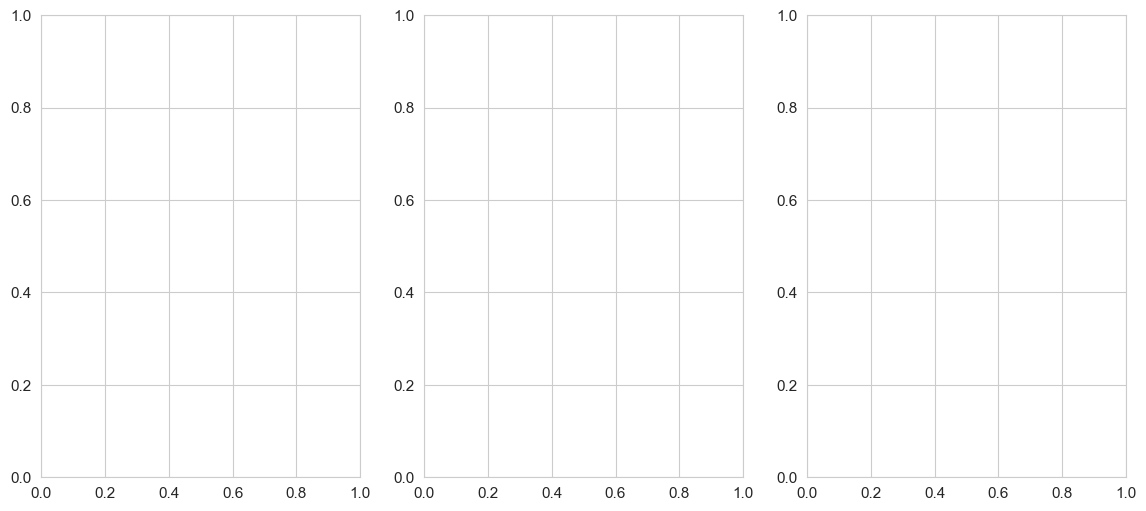

In [92]:
ols_p_fs = {}
for col in ['hl_pfc', 'hl_striatum', 'hl_fs_gap']:
    r = smf.ols(f'{col} ~ anhedonia_group + Age_clean + sex + is_patient', data=df_base).fit()
    ols_p_fs[col] = r.pvalues['anhedonia_group[T.HIGH]']

outcomes_fs = {
    'hl_pfc':      ('PFC Mean HL',                       hl_pfc_mean_LOW,      hl_pfc_mean_HIGH),
    'hl_striatum': ('Striatum Mean HL',                   hl_striatum_mean_LOW, hl_striatum_mean_HIGH),
    'hl_fs_gap':   ('Hierarchical Gap\n(PFC − Striatum)', hl_fs_gap_LOW,        hl_fs_gap_HIGH),
}

plot_rows = []
for col, (label, arr_low, arr_high) in outcomes_fs.items():
    for v in arr_low:
        plot_rows.append({'Measure': label, 'Group': 'Low', 'Value': v})
    for v in arr_high:
        plot_rows.append({'Measure': label, 'Group': 'High', 'Value': v})

plot_df_fs = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, (col, (title, _, __)) in zip(axes, outcomes_fs.items()):
    data = plot_df_fs[plot_df_fs['Measure'] == title]

    pt.RainCloud(
        data=data, x='Group', y='Value',
        order=['Low', 'High'],
        palette=[GROUP_COLORS[g] for g in ['Low', 'High']],
        ax=ax,
        orient='v',
        width_viol=0.5,
        width_box=0.15,
        point_size=3,
        alpha=0.65,
        cut=2,
        box_showfliers=False,
        box_linewidth=1.5,
    )

    ax.grid(False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Anhedonia Group', fontsize=11)
    ax.set_ylabel('Hierarchical Level', fontsize=11)
    add_pvalue_annotation(ax, ols_p_fs[col])

fig.suptitle('Frontostriatal Hierarchical Positioning (Full 232-Region Network)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('violins_frontostriatal_levels.png', dpi=600, bbox_inches='tight')
plt.show()


In [93]:
# %% Sensitivity: PFC & Striatum Hierarchical Levels — Patients Only + Broad Dx Category
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Ensure covariates exist on demos
if 'Age_clean' not in demos.columns:
    demos['Age_clean'] = demos['Age'].replace(999, np.nan)
if 'is_patient' not in demos.columns:
    demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)

# Broad diagnostic-category mapping
dx_map_fs = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other',
    'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other'
}

# Build per-subject dataframe (PFC, striatum, gap) + demographics + broad Dx
df_fs_sens = pd.concat([
    pd.DataFrame({
        'subjectkey': ids_low,
        'hl_pfc':      hl_pfc_mean_LOW,
        'hl_striatum': hl_striatum_mean_LOW,
        'hl_fs_gap':   hl_fs_gap_LOW,
        'anhedonia_group': 'LOW'
    }),
    pd.DataFrame({
        'subjectkey': ids_high,
        'hl_pfc':      hl_pfc_mean_HIGH,
        'hl_striatum': hl_striatum_mean_HIGH,
        'hl_fs_gap':   hl_fs_gap_HIGH,
        'anhedonia_group': 'HIGH'
    }),
], ignore_index=True).merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Primary_Dx_Payman']],
    on='subjectkey', how='left'
)

df_fs_sens['sex'] = df_fs_sens['sex'].replace('O', np.nan)
df_fs_sens['anhedonia_group'] = pd.Categorical(df_fs_sens['anhedonia_group'], categories=['LOW', 'HIGH'])
df_fs_sens['sex'] = pd.Categorical(df_fs_sens['sex'], categories=['F', 'M'])

df_fs_sens['Dx_label'] = (
    df_fs_sens['Primary_Dx_Payman'].replace(999, 'HC').astype(str).str.strip()
)
df_fs_sens['Dx_broad'] = pd.Categorical(
    df_fs_sens['Dx_label'].map(dx_map_fs),
    categories=['Mood', 'Anxiety_Trauma', 'Other']
)

# Patients-only dataframe used by Models 2 and 3
df_fs_patients = df_fs_sens[df_fs_sens['is_patient'] == 1].copy()
n_low_pat  = (df_fs_patients['anhedonia_group'] == 'LOW').sum()
n_high_pat = (df_fs_patients['anhedonia_group'] == 'HIGH').sum()

print('Dx_broad counts by group:')
print(pd.crosstab(df_fs_patients['anhedonia_group'], df_fs_patients['Dx_broad']))
print()

outcomes_fs = [
    ('hl_pfc',      'PFC Mean Hierarchical Level'),
    ('hl_striatum', 'Striatum Mean Hierarchical Level'),
    ('hl_fs_gap',   'Hierarchical Gap (PFC − Striatum)'),
]

for outcome, label in outcomes_fs:
    # --- Model 1: full sample (+ is_patient) ---
    result_fs_full = smf.ols(
        f'{outcome} ~ anhedonia_group + Age_clean + sex + is_patient',
        data=df_fs_sens
    ).fit()
    coef_fs_full = result_fs_full.params['anhedonia_group[T.HIGH]']
    pval_fs_full = result_fs_full.pvalues['anhedonia_group[T.HIGH]']

    # --- Model 2: patients only ---
    result_fs_pat = smf.ols(
        f'{outcome} ~ anhedonia_group + Age_clean + sex',
        data=df_fs_patients
    ).fit()
    coef_fs_pat = result_fs_pat.params['anhedonia_group[T.HIGH]']
    pval_fs_pat = result_fs_pat.pvalues['anhedonia_group[T.HIGH]']
    ci_lo_fp, ci_hi_fp = result_fs_pat.conf_int().loc['anhedonia_group[T.HIGH]']

    # --- Model 3: patients only + broad diagnostic category ---
    result_fs_dx = smf.ols(
        f'{outcome} ~ anhedonia_group + Age_clean + sex + Dx_broad',
        data=df_fs_patients.dropna(subset=['Dx_broad'])
    ).fit()
    coef_fs_dx = result_fs_dx.params['anhedonia_group[T.HIGH]']
    pval_fs_dx = result_fs_dx.pvalues['anhedonia_group[T.HIGH]']
    ci_lo_fd, ci_hi_fd = result_fs_dx.conf_int().loc['anhedonia_group[T.HIGH]']

    print('==============================')
    print(f'{label} — Patients Only')
    print(f'  N = {int(result_fs_pat.nobs)}  (LOW={n_low_pat}, HIGH={n_high_pat})')
    print('==============================')
    print('  Anhedonia group (HIGH vs LOW):')
    print(f'    β  = {coef_fs_pat:.5f}')
    print(f'    95% CI = [{ci_lo_fp:.5f}, {ci_hi_fp:.5f}]')
    print(f'    p  = {pval_fs_pat:.4f}  {"*** significant" if pval_fs_pat < 0.05 else "ns"}')
    print('\n  Covariates:')
    for term in ['Age_clean', 'sex[T.M]']:
        print(f'    {term:<22}  β={result_fs_pat.params[term]:.5f},  p={result_fs_pat.pvalues[term]:.4f}')
    print(f'\n  Model fit:  R²={result_fs_pat.rsquared:.3f},  adj-R²={result_fs_pat.rsquared_adj:.3f}')

    print('\n==============================')
    print(f'{label} — Patients Only + Broad Dx Category')
    print(f'  N = {int(result_fs_dx.nobs)}')
    print('==============================')
    print('  Anhedonia group (HIGH vs LOW):')
    print(f'    β  = {coef_fs_dx:.5f}')
    print(f'    95% CI = [{ci_lo_fd:.5f}, {ci_hi_fd:.5f}]')
    print(f'    p  = {pval_fs_dx:.4f}  {"*** significant" if pval_fs_dx < 0.05 else "ns"}')
    print('\n  Covariates:')
    for term in ['Age_clean', 'sex[T.M]', 'Dx_broad[T.Anxiety_Trauma]', 'Dx_broad[T.Other]']:
        print(f'    {term:<35}  β={result_fs_dx.params[term]:.5f},  p={result_fs_dx.pvalues[term]:.4f}')
    print(f'\n  Model fit:  R²={result_fs_dx.rsquared:.3f},  adj-R²={result_fs_dx.rsquared_adj:.3f}')


Dx_broad counts by group:
Dx_broad         Mood  Anxiety_Trauma  Other
anhedonia_group                             
LOW                31              25     15
HIGH               31              18      8

PFC Mean Hierarchical Level — Patients Only
  N = 125  (LOW=71, HIGH=57)
  Anhedonia group (HIGH vs LOW):
    β  = -0.02973
    95% CI = [-0.05457, -0.00488]
    p  = 0.0194  *** significant

  Covariates:
    Age_clean               β=-0.00073,  p=0.1175
    sex[T.M]                β=0.01730,  p=0.1734

  Model fit:  R²=0.099,  adj-R²=0.076

PFC Mean Hierarchical Level — Patients Only + Broad Dx Category
  N = 125
  Anhedonia group (HIGH vs LOW):
    β  = -0.03119
    95% CI = [-0.05604, -0.00634]
    p  = 0.0143  *** significant

  Covariates:
    Age_clean                            β=-0.00071,  p=0.1286
    sex[T.M]                             β=0.01987,  p=0.1203
    Dx_broad[T.Anxiety_Trauma]           β=-0.00186,  p=0.8908
    Dx_broad[T.Other]                    β=-0.02623, 

In [94]:
# np.savetxt('./outputs/brain_rendering/roi_hl_low_rendering.txt', roi_hl_low_rendering, delimiter='\t')
# np.savetxt('./outputs/brain_rendering/roi_hl_high_rendering.txt', roi_hl_high_rendering, delimiter='\t')
# np.savetxt('./outputs/brain_rendering/roi_hl_diff_rendering.txt', roi_hl_diff_rendering, delimiter='\t')

### Correlations with SHAPS scores

In [95]:
shaps_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_shaps01.csv')
shaps_items['shaps_total']=shaps_items.iloc[:, 1:].sum(axis=1)


#### correlation with cortex to subcortex flow asymmetry

In [96]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# --- 1. Per-subject normalized cortex->subcortex asymmetry (both groups pooled) ---
td_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'td_dominance': td_dominance_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'td_dominance': td_dominance_norm_HIGH}),
], ignore_index=True)

# --- 2. SHAPS total per subject (first column of shaps_items is the subject ID) ---
id_col = shaps_items.columns[0]
shaps  = shaps_items[[id_col, 'shaps_total']].rename(columns={id_col: 'subjectkey'})

# --- 3. Merge on subjectkey, then correlate ---
df_corr = td_df.merge(shaps, on='subjectkey', how='inner').dropna(subset=['td_dominance', 'shaps_total'])
print(f'Merged rows: {len(df_corr)}  (td={len(td_df)}, shaps={len(shaps)})')
if len(df_corr) < min(len(td_df), len(shaps)) * 0.8:
    print('  ⚠️  Few rows matched — check that the SHAPS ID column format matches subjectkey!')

r_p, p_p = pearsonr (df_corr['td_dominance'], df_corr['shaps_total'])
r_s, p_s = spearmanr(df_corr['td_dominance'], df_corr['shaps_total'])

print('\nNormalized top-down dominance (cortex→subcortex) vs SHAPS total:')
print(f'  Pearson :  r = {r_p:+.3f},  p = {p_p:.4f}')
print(f'  Spearman:  ρ = {r_s:+.3f},  p = {p_s:.4f}  (N = {len(df_corr)})')


Merged rows: 210  (td=210, shaps=226)

Normalized top-down dominance (cortex→subcortex) vs SHAPS total:
  Pearson :  r = +0.273,  p = 0.0001
  Spearman:  ρ = +0.362,  p = 0.0000  (N = 210)


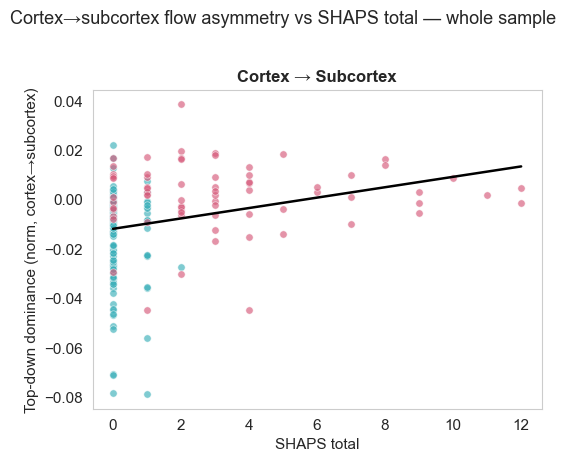

In [123]:
# %% Scatter plot: cortex->subcortex flow asymmetry vs total SHAPS (whole sample)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

GROUP_COLORS = {'LOW': '#3AAFB9', 'HIGH': '#D65A7A'}

# Per-subject normalized cortex->subcortex asymmetry, with group label for coloring
td_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'anhedonia_group': 'LOW',  'td_dominance': td_dominance_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'anhedonia_group': 'HIGH', 'td_dominance': td_dominance_norm_HIGH}),
], ignore_index=True)

# SHAPS total per subject (first column of shaps_items is the subject ID)
id_col = shaps_items.columns[0]
shaps  = shaps_items[[id_col, 'shaps_total']].rename(columns={id_col: 'subjectkey'})

df_plot = td_df.merge(shaps, on='subjectkey', how='inner')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.grid(False)

sub = df_plot[['td_dominance', 'shaps_total', 'anhedonia_group']].dropna()
x, y = sub['shaps_total'].to_numpy(), sub['td_dominance'].to_numpy()

# points colored by group
for g, c in GROUP_COLORS.items():
    m = (sub['anhedonia_group'] == g).to_numpy()
    ax.scatter(x[m], y[m], s=28, alpha=0.65,
               color=c, edgecolor='white', linewidth=0.5, label=g)

# OLS fit line over the WHOLE sample
b, a = np.polyfit(x, y, 1)                       # slope, intercept
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b * xs, color='black', lw=1.8)

r, p = pearsonr(x, y)
ax.set_title('Cortex → Subcortex', fontsize=12, fontweight='bold')
ax.set_xlabel('SHAPS total')
ax.set_ylabel('Top-down dominance (norm, cortex→subcortex)')
# ax.text(0.04, 0.96, f'r = {r:+.3f}\np = {p:.4f}\nn = {len(sub)}',
#         transform=ax.transAxes, va='top', ha='left', fontsize=10,
#         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.85))

# ax.legend(title='Anhedonia', frameon=False, loc='lower right')
fig.suptitle('Cortex→subcortex flow asymmetry vs SHAPS total — whole sample', y=1.02, fontsize=13)
fig.tight_layout()
plt.savefig('scatter_cortex_subcortex_asym_vs_shaps.png', dpi=600, bbox_inches='tight')
plt.show()


#### correlation with PFC to striatum flow asymmetry

In [108]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# --- 1. Per-subject normalized PFC<->striatum asymmetry (both groups pooled) ---
fs_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'fs_asym': fs_asym_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'fs_asym': fs_asym_norm_HIGH}),
], ignore_index=True)

# --- 2. SHAPS total per subject (first column of shaps_items is the subject ID) ---
id_col = shaps_items.columns[0]
shaps  = shaps_items[[id_col, 'shaps_total']].rename(columns={id_col: 'subjectkey'})

# --- 3. Merge on subjectkey, then correlate ---
df_corr = fs_df.merge(shaps, on='subjectkey', how='inner').dropna(subset=['fs_asym', 'shaps_total'])
print(f'Merged rows: {len(df_corr)}  (fs={len(fs_df)}, shaps={len(shaps)})')
if len(df_corr) < min(len(fs_df), len(shaps)) * 0.8:
    print('  ⚠️  Few rows matched — check that the SHAPS ID column format matches subjectkey!')

r_p, p_p = pearsonr (df_corr['fs_asym'], df_corr['shaps_total'])
r_s, p_s = spearmanr(df_corr['fs_asym'], df_corr['shaps_total'])

print('\nNormalized frontostriatal asymmetry (PFC→striatum) vs SHAPS total:')
print(f'  Pearson :  r = {r_p:+.3f},  p = {p_p:.4f}')
print(f'  Spearman:  ρ = {r_s:+.3f},  p = {p_s:.4f}  (N = {len(df_corr)})')


Merged rows: 210  (fs=210, shaps=226)

Normalized frontostriatal asymmetry (PFC→striatum) vs SHAPS total:
  Pearson :  r = +0.241,  p = 0.0004
  Spearman:  ρ = +0.346,  p = 0.0000  (N = 210)


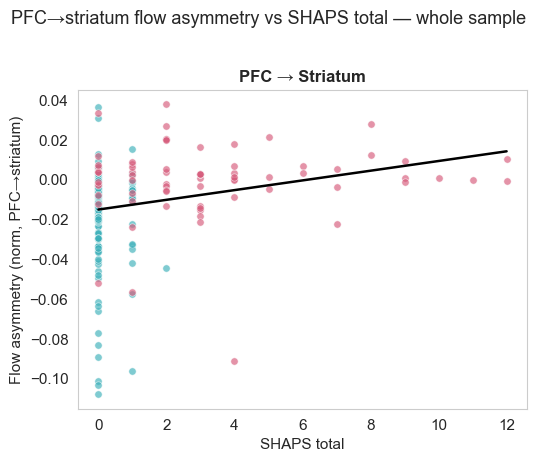

In [120]:
# %% Scatter plot: PFC->striatum flow asymmetry vs total SHAPS (whole sample)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

GROUP_COLORS = {'LOW': '#3AAFB9', 'HIGH': '#D65A7A'}

# Per-subject normalized PFC->striatum asymmetry, with group label for coloring
fs_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'anhedonia_group': 'LOW',  'fs_asym': fs_asym_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'anhedonia_group': 'HIGH', 'fs_asym': fs_asym_norm_HIGH}),
], ignore_index=True)

# SHAPS total per subject (first column of shaps_items is the subject ID)
id_col = shaps_items.columns[0]
shaps  = shaps_items[[id_col, 'shaps_total']].rename(columns={id_col: 'subjectkey'})

df_plot = fs_df.merge(shaps, on='subjectkey', how='inner')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.grid(False)

sub = df_plot[['fs_asym', 'shaps_total', 'anhedonia_group']].dropna()
x, y = sub['shaps_total'].to_numpy(), sub['fs_asym'].to_numpy()

# points colored by group
for g, c in GROUP_COLORS.items():
    m = (sub['anhedonia_group'] == g).to_numpy()
    ax.scatter(x[m], y[m], s=28, alpha=0.65,
               color=c, edgecolor='white', linewidth=0.5, label=g)

# OLS fit line over the WHOLE sample
b, a = np.polyfit(x, y, 1)                       # slope, intercept
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b * xs, color='black', lw=1.8)

r, p = pearsonr(x, y)
ax.set_title('PFC → Striatum', fontsize=12, fontweight='bold')
ax.set_xlabel('SHAPS total')
ax.set_ylabel('Flow asymmetry (norm, PFC→striatum)')
# ax.text(0.04, 0.96, f'r = {r:+.3f}\np = {p:.4f}\nn = {len(sub)}',
#         transform=ax.transAxes, va='top', ha='left', fontsize=10,
#         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.85))

# ax.legend(title='Anhedonia', frameon=False, loc='lower right')
fig.suptitle('PFC→striatum flow asymmetry vs SHAPS total — whole sample', y=1.02, fontsize=13)
fig.tight_layout()
plt.savefig('scatter_pfc_striatum_asym_vs_shaps.png', dpi=600, bbox_inches='tight')
plt.show()


### Correlations with SHAPS scores

In [110]:
teps_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_teps01.csv')
teps_items['teps_total']=teps_items.iloc[:, 1:].sum(axis=1)


In [111]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# --- 1. Per-subject normalized cortex->subcortex asymmetry (both groups pooled) ---
td_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'td_dominance': td_dominance_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'td_dominance': td_dominance_norm_HIGH}),
], ignore_index=True)

# --- 2. SHAPS total per subject (first column of shaps_items is the subject ID) ---
id_col = teps_items.columns[0]
teps  = teps_items[[id_col, 'teps_total']].rename(columns={id_col: 'subjectkey'})

# --- 3. Merge on subjectkey, then correlate ---
df_corr = td_df.merge(teps, on='subjectkey', how='inner').dropna(subset=['td_dominance', 'teps_total'])
print(f'Merged rows: {len(df_corr)}  (td={len(td_df)}, shaps={len(teps)})')
if len(df_corr) < min(len(td_df), len(teps)) * 0.8:
    print('  ⚠️  Few rows matched — check that the SHAPS ID column format matches subjectkey!')

r_p, p_p = pearsonr (df_corr['td_dominance'], df_corr['teps_total'])
r_s, p_s = spearmanr(df_corr['td_dominance'], df_corr['teps_total'])

print('\nNormalized top-down dominance (cortex→subcortex) vs TEPS total:')
print(f'  Pearson :  r = {r_p:+.3f},  p = {p_p:.4f}')
print(f'  Spearman:  ρ = {r_s:+.3f},  p = {p_s:.4f}  (N = {len(df_corr)})')


Merged rows: 210  (td=210, shaps=229)

Normalized top-down dominance (cortex→subcortex) vs TEPS total:
  Pearson :  r = -0.144,  p = 0.0365
  Spearman:  ρ = -0.166,  p = 0.0158  (N = 210)


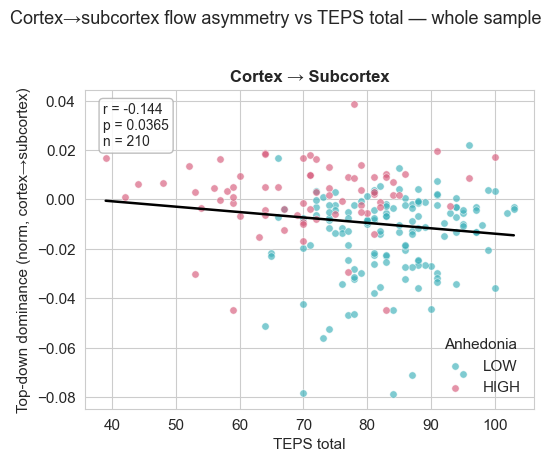

In [112]:
# %% Scatter plot: cortex->subcortex flow asymmetry vs total TEPS (whole sample)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

GROUP_COLORS = {'LOW': '#3AAFB9', 'HIGH': '#D65A7A'}

# Per-subject normalized cortex->subcortex asymmetry, with group label for coloring
td_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'anhedonia_group': 'LOW',  'td_dominance': td_dominance_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'anhedonia_group': 'HIGH', 'td_dominance': td_dominance_norm_HIGH}),
], ignore_index=True)

# TEPS total per subject (first column of teps_items is the subject ID)
id_col = teps_items.columns[0]
teps   = teps_items[[id_col, 'teps_total']].rename(columns={id_col: 'subjectkey'})

df_plot = td_df.merge(teps, on='subjectkey', how='inner')

fig, ax = plt.subplots(figsize=(5.5, 4.5))

sub = df_plot[['td_dominance', 'teps_total', 'anhedonia_group']].dropna()
x, y = sub['teps_total'].to_numpy(), sub['td_dominance'].to_numpy()

# points colored by group
for g, c in GROUP_COLORS.items():
    m = (sub['anhedonia_group'] == g).to_numpy()
    ax.scatter(x[m], y[m], s=28, alpha=0.65,
               color=c, edgecolor='white', linewidth=0.5, label=g)

# OLS fit line over the WHOLE sample
b, a = np.polyfit(x, y, 1)                       # slope, intercept
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b * xs, color='black', lw=1.8)

r, p = pearsonr(x, y)
ax.set_title('Cortex → Subcortex', fontsize=12, fontweight='bold')
ax.set_xlabel('TEPS total')
ax.set_ylabel('Top-down dominance (norm, cortex→subcortex)')
ax.text(0.04, 0.96, f'r = {r:+.3f}\np = {p:.4f}\nn = {len(sub)}',
        transform=ax.transAxes, va='top', ha='left', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.85))

ax.legend(title='Anhedonia', frameon=False, loc='lower right')
fig.suptitle('Cortex→subcortex flow asymmetry vs TEPS total — whole sample', y=1.02, fontsize=13)
fig.tight_layout()
# plt.savefig('scatter_cortex_subcortex_asym_vs_teps.png', dpi=150, bbox_inches='tight')
plt.show()


In [113]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# --- 1. Per-subject normalized PFC<->striatum asymmetry (both groups pooled) ---
fs_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'fs_asym': fs_asym_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'fs_asym': fs_asym_norm_HIGH}),
], ignore_index=True)

# --- 2. TEPS total per subject (first column of teps_items is the subject ID) ---
id_col = teps_items.columns[0]
teps   = teps_items[[id_col, 'teps_total']].rename(columns={id_col: 'subjectkey'})

# --- 3. Merge on subjectkey, then correlate ---
df_corr = fs_df.merge(teps, on='subjectkey', how='inner').dropna(subset=['fs_asym', 'teps_total'])
print(f'Merged rows: {len(df_corr)}  (fs={len(fs_df)}, teps={len(teps)})')
if len(df_corr) < min(len(fs_df), len(teps)) * 0.8:
    print('  ⚠️  Few rows matched — check that the TEPS ID column format matches subjectkey!')

r_p, p_p = pearsonr (df_corr['fs_asym'], df_corr['teps_total'])
r_s, p_s = spearmanr(df_corr['fs_asym'], df_corr['teps_total'])

print('\nNormalized frontostriatal asymmetry (PFC→striatum) vs TEPS total:')
print(f'  Pearson :  r = {r_p:+.3f},  p = {p_p:.4f}')
print(f'  Spearman:  ρ = {r_s:+.3f},  p = {p_s:.4f}  (N = {len(df_corr)})')


Merged rows: 210  (fs=210, teps=229)

Normalized frontostriatal asymmetry (PFC→striatum) vs TEPS total:
  Pearson :  r = -0.159,  p = 0.0209
  Spearman:  ρ = -0.196,  p = 0.0044  (N = 210)


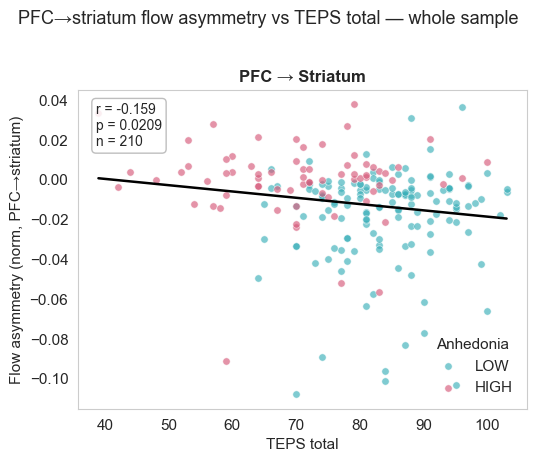

In [119]:
# %% Scatter plot: PFC->striatum flow asymmetry vs total TEPS (whole sample)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

GROUP_COLORS = {'LOW': '#3AAFB9', 'HIGH': '#D65A7A'}

# Per-subject normalized PFC->striatum asymmetry, with group label for coloring
fs_df = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'anhedonia_group': 'LOW',  'fs_asym': fs_asym_norm_LOW}),
    pd.DataFrame({'subjectkey': ids_high, 'anhedonia_group': 'HIGH', 'fs_asym': fs_asym_norm_HIGH}),
], ignore_index=True)

# TEPS total per subject (first column of teps_items is the subject ID)
id_col = teps_items.columns[0]
teps   = teps_items[[id_col, 'teps_total']].rename(columns={id_col: 'subjectkey'})

df_plot = fs_df.merge(teps, on='subjectkey', how='inner')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.grid(False)

sub = df_plot[['fs_asym', 'teps_total', 'anhedonia_group']].dropna()
x, y = sub['teps_total'].to_numpy(), sub['fs_asym'].to_numpy()

# points colored by group
for g, c in GROUP_COLORS.items():
    m = (sub['anhedonia_group'] == g).to_numpy()
    ax.scatter(x[m], y[m], s=28, alpha=0.65,
               color=c, edgecolor='white', linewidth=0.5, label=g)

# OLS fit line over the WHOLE sample
b, a = np.polyfit(x, y, 1)                       # slope, intercept
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b * xs, color='black', lw=1.8)

r, p = pearsonr(x, y)
ax.set_title('PFC → Striatum', fontsize=12, fontweight='bold')
ax.set_xlabel('TEPS total')
ax.set_ylabel('Flow asymmetry (norm, PFC→striatum)')
ax.text(0.04, 0.96, f'r = {r:+.3f}\np = {p:.4f}\nn = {len(sub)}',
        transform=ax.transAxes, va='top', ha='left', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.85))

ax.legend(title='Anhedonia', frameon=False, loc='lower right')
fig.suptitle('PFC→striatum flow asymmetry vs TEPS total — whole sample', y=1.02, fontsize=13)
fig.tight_layout()
# plt.savefig('scatter_pfc_striatum_asym_vs_teps.png', dpi=150, bbox_inches='tight')
plt.show()


Cortex → Subcortex vs TEPS-Anticipatory: Pearson r=-0.113 p=0.1028 | Spearman ρ=-0.116 p=0.0926  (N=210)
Cortex → Subcortex vs TEPS-Consummatory: Pearson r=-0.139 p=0.0442 | Spearman ρ=-0.157 p=0.0233  (N=210)
PFC → Striatum     vs TEPS-Anticipatory: Pearson r=-0.119 p=0.0863 | Spearman ρ=-0.134 p=0.0520  (N=210)
PFC → Striatum     vs TEPS-Consummatory: Pearson r=-0.160 p=0.0201 | Spearman ρ=-0.181 p=0.0086  (N=210)


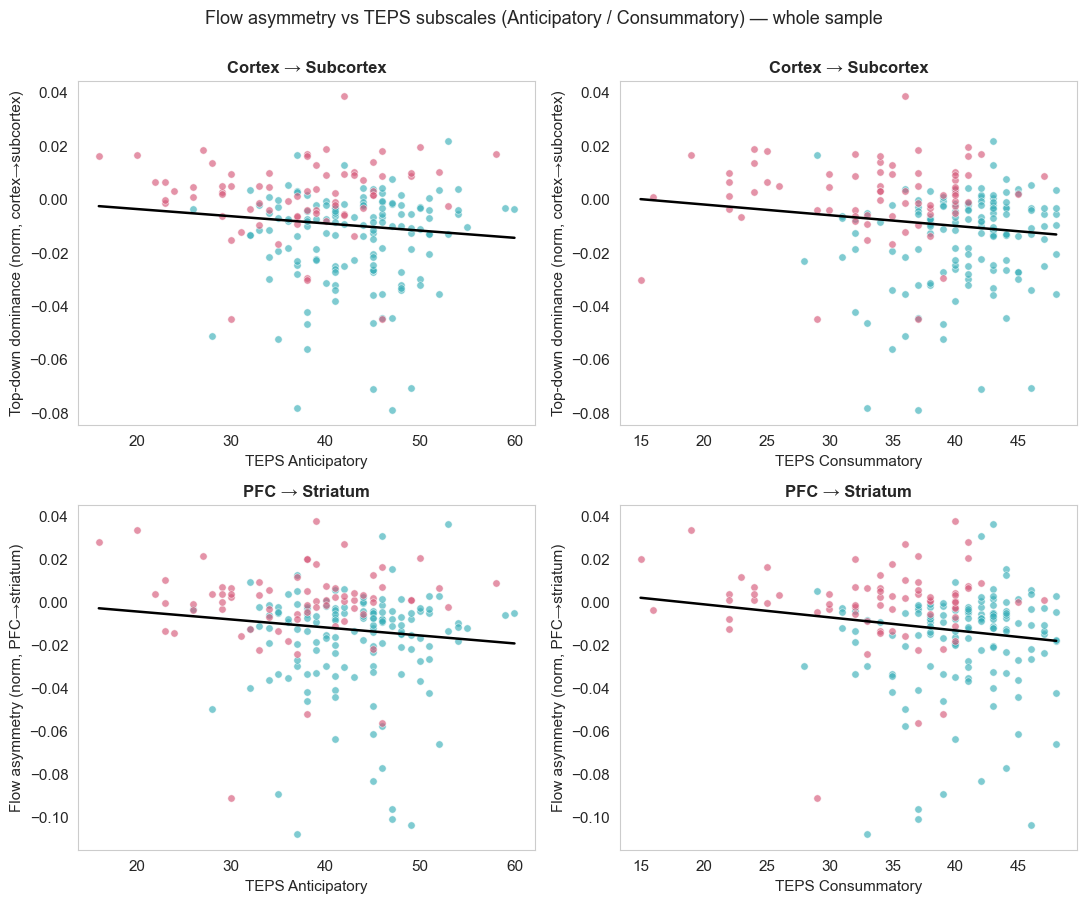

In [118]:
# %% TEPS SUBSCALES: cortex->subcortex & PFC->striatum asymmetry vs Anticipatory/Consummatory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

GROUP_COLORS = {'LOW': '#3AAFB9', 'HIGH': '#D65A7A'}

# --- TEPS subscale definitions (column names = teps1..teps18) ---
ANTICIPATORY = [1, 4, 6, 8, 10, 11, 13, 15, 16, 18]
CONSUMMATORY = [2, 3, 5, 7, 9, 12, 14, 17]
SUBSCALES = {
    'Anticipatory': [f'teps{i}' for i in ANTICIPATORY],
    'Consummatory': [f'teps{i}' for i in CONSUMMATORY],
}

# Per-subject subscale totals (subjectkey is the first column of teps_items)
id_col = teps_items.columns[0]
teps_sub = teps_items[[id_col]].rename(columns={id_col: 'subjectkey'}).copy()
for name, cols in SUBSCALES.items():
    teps_sub[name] = teps_items[cols].sum(axis=1)

# The two brain measures: pooled per-subject value + group label, plus axis label
BRAIN_MEASURES = {
    'Cortex → Subcortex': dict(
        low=td_dominance_norm_LOW, high=td_dominance_norm_HIGH,
        ylabel='Top-down dominance (norm, cortex→subcortex)'),
    'PFC → Striatum': dict(
        low=fs_asym_norm_LOW, high=fs_asym_norm_HIGH,
        ylabel='Flow asymmetry (norm, PFC→striatum)'),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for row, (brain_name, b) in enumerate(BRAIN_MEASURES.items()):
    brain_df = pd.concat([
        pd.DataFrame({'subjectkey': ids_low,  'anhedonia_group': 'LOW',  'brain': b['low']}),
        pd.DataFrame({'subjectkey': ids_high, 'anhedonia_group': 'HIGH', 'brain': b['high']}),
    ], ignore_index=True)

    for col, subscale in enumerate(SUBSCALES):
        ax = axes[row, col]
        ax.grid(False)
        df_plot = brain_df.merge(teps_sub[['subjectkey', subscale]], on='subjectkey', how='inner')
        sub = df_plot[['brain', subscale, 'anhedonia_group']].dropna()
        x, y = sub[subscale].to_numpy(), sub['brain'].to_numpy()

        for g, c in GROUP_COLORS.items():
            m = (sub['anhedonia_group'] == g).to_numpy()
            ax.scatter(x[m], y[m], s=28, alpha=0.65,
                       color=c, edgecolor='white', linewidth=0.5, label=g)

        # OLS fit over whole sample
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, intercept + slope * xs, color='black', lw=1.8)

        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)
        print(f'{brain_name:18s} vs TEPS-{subscale:12s}: '
              f'Pearson r={r_p:+.3f} p={p_p:.4f} | Spearman ρ={r_s:+.3f} p={p_s:.4f}  (N={len(sub)})')

        ax.set_title(f'{brain_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel(f'TEPS {subscale}')
        ax.set_ylabel(b['ylabel'])
        # ax.text(0.04, 0.96, f'r = {r_p:+.3f}\np = {p_p:.4f}\nn = {len(sub)}',
        #         transform=ax.transAxes, va='top', ha='left', fontsize=10,
        #         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.85))
        # if row == 0 and col == 1:
        #     ax.legend(title='Anhedonia', frameon=False, loc='lower right')

fig.suptitle('Flow asymmetry vs TEPS subscales (Anticipatory / Consummatory) — whole sample',
             y=1.0, fontsize=13)
fig.tight_layout()
plt.savefig('scatter_asym_vs_teps_subscales.png', dpi=600, bbox_inches='tight')
plt.show()


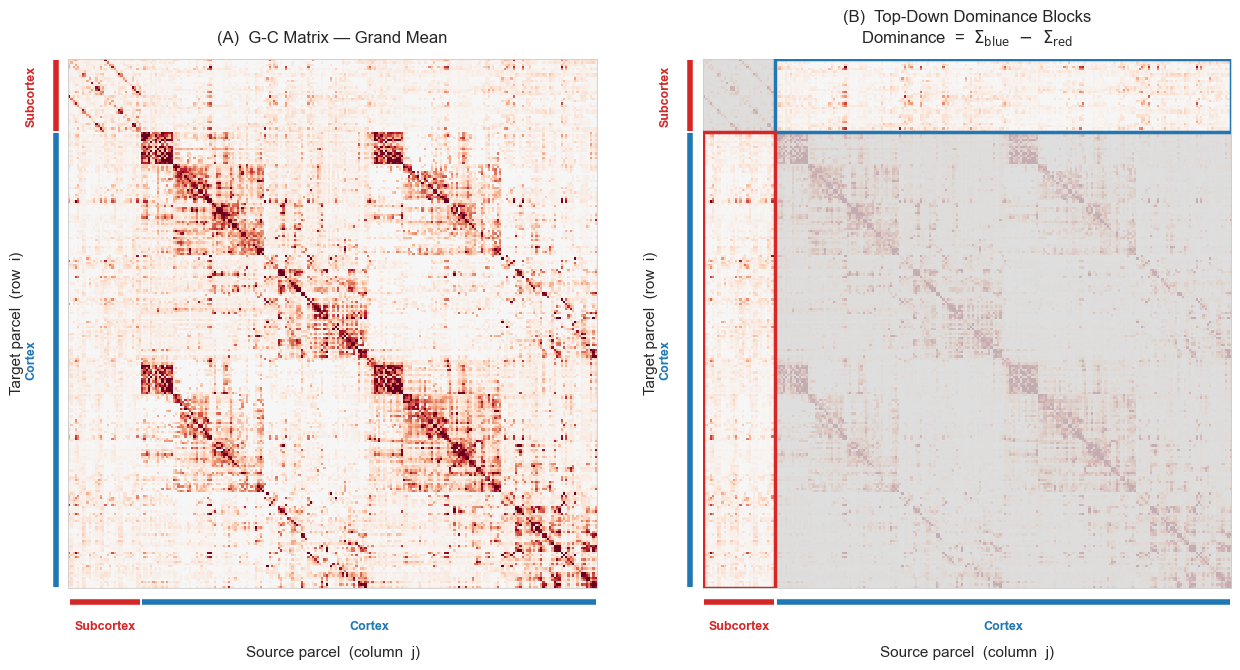

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

# ─────────────────────────────────────────────────────────────────────────────
# Two-panel figure:
#   Panel A — full G-C heatmap, no masking
#   Panel B — same heatmap, non-relevant cells greyed out,
#              blue border = C[subcortical_idx, cortical_idx]  (Cortex→Subcortex, top-down)
#              red  border = C[cortical_idx, subcortical_idx]  (Subcortex→Cortex, bottom-up)
#
#   Top-down dominance = Σ(blue box) − Σ(red box)
# ─────────────────────────────────────────────────────────────────────────────

N = 232

# ── 1.  Grand-mean connectivity matrix (both groups pooled)  ─────────────────
Ceff_all = np.concatenate([np.array(Ceff_LOW), np.array(Ceff_HIGH)], axis=0)
C_mean   = np.mean(Ceff_all, axis=0)   # shape (232, 232)

# ── 2.  Shared colour scaling (same norm on both panels)  ────────────────────
vmax = np.percentile(np.abs(C_mean), 99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# ── 3.  Block corners  ────────────────────────────────────────────────────────
sub_lo, sub_hi = min(subcortical_idx), max(subcortical_idx)
cor_lo, cor_hi = min(cortical_idx),    max(cortical_idx)

BLUE_C = '#1f77b4'
RED_C  = '#d62728'
LW     = 2.5

# ── 4.  Grey overlay image: non-relevant cells masked  ───────────────────────
relevant = np.zeros((N, N), dtype=bool)
relevant[np.ix_(subcortical_idx, cortical_idx)] = True   # blue block (top-down)
relevant[np.ix_(cortical_idx, subcortical_idx)] = True   # red block  (bottom-up)

grey = np.zeros((N, N, 4))                     # fully transparent everywhere
grey[~relevant] = [0.85, 0.85, 0.85, 0.80]    # light grey, 80% opaque on non-relevant cells

# ── 5.  Marginal span lines + labels helper  ──────────────────────────────────
LINE_OFF  = 6    # parcel units outside the plot edge for the span line
LABEL_OFF = 14   # parcel units outside the plot edge for the text label
XLABEL_PAD = 42  # points; pushes x-label below the bottom marginal annotations
YLABEL_PAD = 32  # points; pushes y-label left of the left marginal annotations

def add_marginal_labels(ax):
    for idx_list, color, label in [
        (cortical_idx,    BLUE_C, 'Cortex'),
        (subcortical_idx, RED_C,  'Subcortex'),
    ]:
        lo, hi = min(idx_list), max(idx_list)
        mid    = (lo + hi) / 2

        # Horizontal span line below x-axis (source / column range)
        ax.plot([lo, hi], [N + LINE_OFF, N + LINE_OFF],
                color=color, lw=4, clip_on=False, solid_capstyle='butt')
        ax.text(mid, N + LABEL_OFF, label,
                ha='center', va='top', color=color,
                fontsize=9, fontweight='bold', clip_on=False)

        # Vertical span line left of y-axis (target / row range)
        ax.plot([-LINE_OFF, -LINE_OFF], [lo, hi],
                color=color, lw=4, clip_on=False, solid_capstyle='butt')
        ax.text(-LABEL_OFF, mid, label,
                ha='right', va='center', color=color,
                fontsize=9, fontweight='bold', clip_on=False, rotation=90)

# ── 6.  Figure  ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

IMSHOW_KW = dict(origin='upper', aspect='equal',
                 interpolation='nearest', cmap='RdBu_r', norm=norm)

# Shared axis formatting for both panels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)
    ax.set_xlabel('Source parcel  (column  j)', fontsize=11, labelpad=XLABEL_PAD)
    ax.set_ylabel('Target parcel  (row  i)',    fontsize=11, labelpad=YLABEL_PAD)
    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(N - 0.5, -0.5)   # inverted: row 0 at top

# ── Panel A: full heatmap  ────────────────────────────────────────────────────
ax_A = axes[0]
im = ax_A.imshow(C_mean, **IMSHOW_KW)
ax_A.set_title('(A)  G-C Matrix — Grand Mean', fontsize=12, pad=12)
add_marginal_labels(ax_A)

# ── Panel B: masked heatmap with bordered blocks  ─────────────────────────────
ax_B = axes[1]
ax_B.imshow(C_mean, **IMSHOW_KW)

# Grey wash over non-relevant cells
ax_B.imshow(grey, origin='upper', aspect='equal',
            interpolation='nearest', zorder=2)

# Blue border: rows = subcortical (target), cols = cortical (source)
ax_B.add_patch(mpatches.Rectangle(
    (cor_lo - 0.5, sub_lo - 0.5),
    cor_hi - cor_lo + 1, sub_hi - sub_lo + 1,
    fill=False, edgecolor=BLUE_C, linewidth=LW, zorder=5
))

# Red border: rows = cortical (target), cols = subcortical (source)
ax_B.add_patch(mpatches.Rectangle(
    (sub_lo - 0.5, cor_lo - 0.5),
    sub_hi - sub_lo + 1, cor_hi - cor_lo + 1,
    fill=False, edgecolor=RED_C, linewidth=LW, zorder=5
))

ax_B.set_title(
    '(B)  Top-Down Dominance Blocks\n'
    r'Dominance  =  $\Sigma_{\mathrm{blue}}$  $-$  $\Sigma_{\mathrm{red}}$',
    fontsize=12, pad=12
)
add_marginal_labels(ax_B)

# # ── 7.  Shared colorbar  ──────────────────────────────────────────────────────
# cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.03)
# cbar.set_label('Effective connectivity (G)', fontsize=10)
# cbar.ax.tick_params(labelsize=9)

# fig.suptitle('Effective Connectivity Matrix — Cortex / Subcortex',
#              fontsize=13, fontweight='bold', y=1.01)

# fig.tight_layout()
plt.savefig('topdown_dominance_heatmap_twopanel.png', dpi=600, bbox_inches='tight')
plt.show()
